# Introduction



##### For any questions or inquiry, please email the authors: 

Floor Broekgaarden: fsbroekgaarden@gmail.com


This notebook loads gravitational-wave merger rate predictions from population synthesis models and visualizes them in a three-panel figure. The left panel shows key simulation properties (e.g. code, tracks, labels), the middle panel displays the relative fractions of different formation channels as stacked bars (e.g. \( f_{\mathrm{CE}} \), \( f_{\mathrm{OSMT}} \)), and the right panel plots both the total predicted merger rates \( \mathcal{R}_{\mathrm{tot}} \) and the individual channel contributions \( \mathcal{R}_{i} \). Models are sorted consistently (by the first column or a chosen header), observed GW rate constraints are overlaid for reference, and a unified formation-channel dictionary ensures consistent colors, hatches, and labels across all plots.


### set path to directory 
full path to the directory with all data files   


In [1]:
# change this to your path with the data directory
path_to_file = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/'

### import libraries
the following lines import the `common_code` files that contains some global code / settings that are used throughout this jupyter notebook <br>
if for some reason the python script is not working, or not importing, one can copy paste the code in the script and run it in a cell above/below this block  <br>
Not all codes / libraries loaded are strictly needed. <br>


In [2]:
%matplotlib inline
import sys
# import common_code/PostProcessingScripts which contains default python code used in this jupyter notebook (such as plotting etc.)
sys.path.append('/Users/floorbroekgaarden/Projects/GitHub/common_code/.')
from PostProcessingScripts import * 

# just to make the cells appear wider: comment these lines if needed. 
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


import pandas as pd
import seaborn as sns # only used for nice colors

import matplotlib.pyplot as plt
import matplotlib as mpl

import pandas as pd
# import matplotlib.pyplot as plt
from typing import Optional  # change Optional[str] to str | None when using higher versions of python3
%matplotlib inline

In [3]:


def is_present(x):
    return (x is not None) and (not (isinstance(x, float) and pd.isna(x))) and (str(x).strip() != "")

def color_from_dict(d, key, default="0.7"):
    return d.get(key, default)


def draw_hlines(axe, v_values, list_h_values=[1E-3, 1E5]):
    """ draws lightgray custom vertical grid lines at values in the v_values list 
    these are drawn between the horizontal values given by list_h_values
    """
    for v_ in v_values:
        axe.plot(list_h_values, [v_, v_], lw=0.5, c='gray', ls=':', zorder=0)
        
    return 


def plot_observed_GWrate(axe, DCOlabel='BH-BH', lenmodels=10):
    # plot observed rates (make this a better function )
    dict_rates_from_DCOlabel = {"BH-BH":[10.3, 61.0], "BH-NS":[8,  140.0], "NS-NS":[10.0, 1700.0]}
    # NSNS rates Gpc-3 yr-1 from:GWTC3 min & max rates 
    # BHBH rates for minimum and maximum of possible local merger rates estimates,  and https://ui.adsabs.harvard.edu/abs/2021arXiv210801045T/abstract
    # BHNS rate min and max range from the two estimates based on GW200115 and GW200105!! (OLD) ! 
    
    min_obs_rate, max_obs_rate = dict_rates_from_DCOlabel[DCOlabel][0], dict_rates_from_DCOlabel[DCOlabel][1]
    axe.fill_betweenx(y=[-1, lenmodels], x1=[min_obs_rate,min_obs_rate], x2=[max_obs_rate,max_obs_rate], alpha=0.8, color='lightgray', zorder=1)
        

    return



def _load_and_sort_models(complete_path: str, sort_column: Optional[str]):
    """
    Load model data from CSV and sort by the given column.

    Returns
    -------
    df : pandas.DataFrame
        Sorted dataframe.
    models : pandas.Series
        Sorted list of models.
    """

    # Load model data
    df = pd.read_csv(complete_path)
    df = df.fillna(0.0)

    # Choose default sorting column if not provided
    if sort_column is None: df = df.sort_values(df.columns[0]).reset_index(drop=True)
    # Sort dataframe by chosen column
    else: df = df.sort_values(sort_column).reset_index(drop=True)

    return df, df['model']



def plot_total_rate(
    axe,
    complete_path: str = 'complete/path/to/data.csv',
    sort_column: Optional[str] = "fraction without common envelope",
    DCOlabel: str = 'BH-BH',
    fig_formtype: str = 'default'
    ):
    """
    Plot total gravitational-wave merger rates for different models.
    """
    
    fs_x2 = obtain_plotting_properties_dict(fig_formtype)["fs_x2"]
    
    fc_total_header = obtain_fc_dict()["total"]["name"]
    # Load and sort models
    df, models = _load_and_sort_models(complete_path, sort_column)

    # Plotting normalizer
    plot_size_normalizer = 1  

    # --- Plot total merger rates ---
    for ind_m, model in enumerate(models):
        total_rate = df[fc_total_header][ind_m]
        y_value    = ind_m / plot_size_normalizer  

        axe.scatter(
            total_rate,
            y_value,
            s=60,
            color=obtain_fc_dict()["total"]["color"],
            zorder=10,
            marker='d'
        )
        draw_hlines(axe=axe, v_values=[y_value])

    # --- Configure axes ---
    axe.set_ylim(-1, len(models) + 0.25)
    xlabel = r'$\mathcal{R}_{\rm{m}} \ [\rm{Gpc}^{-3} \rm{yr}^{-1}] $'
    layoutAxesNoYlabel(ax=axe, nameX=xlabel, nameY=False, noYticks=True, fontsize=20)

    axe.set_xscale('log')

    dictDCOlabel_xlim = {
        "BH-BH": [2, 500],
        "BH-NS": [0.2, 400],
        "NS-NS": [0.5, 2e3]
    }
    axe.set_xlim(*dictDCOlabel_xlim[DCOlabel])

    # Add observed GW merger rates
    plot_observed_GWrate(axe, DCOlabel, len(models) + 0.25)

    return axe


def plot_formation_channels_rate(
    axe,
    complete_path: str = 'complete/path/to/data.csv',
    sort_column: Optional[str] = None,
    fc_coloring_option: str = "CE_simple",
    ):
    """
    Plot the contribution of different formation channels to the total merger rate.
    """
    # Get total header info
    fc_total_header = obtain_fc_dict()["total"]["name"]

    # Load and sort models
    df, models = _load_and_sort_models(complete_path, sort_column)

    # Plotting normalizer
    plot_size_normalizer = 1  
    
    
    # Filter channels so we only keep the ones present in df.columns (as the fc_dict is not BHBH, BHNS or BNS specific)
    valid_channels = [
        channel for channel in obtain_fc_dict()[fc_coloring_option]["channels"]
        if channel["name"] in df.columns
    ]
    
    # --- Plot channel contributions ---
    for ind_m, model in enumerate(models):
        total_rate = df[fc_total_header][ind_m]
        y_value    = ind_m / plot_size_normalizer  

        for channel in valid_channels:
            fc_name = channel["name"]
#             fc_hatch = channel["hatch"]
            channel_rate = df[fc_name].values[ind_m] * total_rate
#             color_c      = fc_channel_color_dict[channel]

            axe.scatter(
                channel_rate,
                y_value,
                s=50,
                edgecolor=channel["color"],
                facecolor='none',
                zorder=5,
                marker='s'
            )

    return axe


# def obtain_models_colors(path_to_data='complete/path/to/simulation_specs.csv', color_key="code_abbr", cmap="husl"):
#     """ creates a colormap for set of provided parameters using given cmap
    
#     path_to_data: path to csv file with the data that we want to use as keys
#     color_key: header name of the values we want to use as keys
#     cmap: colormap used 

#     """
    
#     data = pd.read_csv(path_to_data)[color_key].values 
    
#     # if interested in the model labels, combine the two model labels to make them consistent
#     if color_key == "label_1":
#         data2 = pd.read_csv(path_to_data)["label_2"].values 
#         data = np.concatenate((data, data2))
#         del data2
        
#     data = [str(data[i]) for i in range(len(data))] # to deal with nan and np.unique make everything a string. 
#     models = np.unique(data) # get unique items, these will be assigned their own color. 
#     colors =  sns.color_palette(cmap, len(models)) #make a color map 
    
#     return dict(zip(models, colors))


# import numpy as np
# import pandas as pd
# import seaborn as sns

def obtain_models_colors(path_to_data='complete/path/to/simulation_specs.csv',
                         color_key="code_abbr",
                         cmap="husl"):
    """
    Creates a colormap dict for unique values in the provided CSV column.

    - Ignores missing values (NaN/None/empty) so you don't get a 'nan' category.
    - If color_key == 'label_1', also includes (optional) label_2 values, ignoring missing.
    """

    df = pd.read_csv(path_to_data)

    def _present_series(s: pd.Series) -> pd.Series:
        """Return cleaned series of present (non-empty, non-NaN) string values."""
        s = s.dropna()
        s = s.astype(str).str.strip()
        s = s[s != ""]
        return s

    # base column
    s = _present_series(df[color_key]) if color_key in df.columns else pd.Series([], dtype=str)

    # special: include label_2 categories too when building label_1 colormap
    if color_key == "label_1" and "label_2" in df.columns:
        s2 = _present_series(df["label_2"])
        s = pd.concat([s, s2], ignore_index=True)

    # unique category labels
    models = np.unique(s.values)

    # if nothing present, return empty dict
    if len(models) == 0:
        return {}

    colors = sns.color_palette(cmap, len(models))
    return dict(zip(models, colors))




def plot_simulation_properties(
    axe,
    specs_path: str = 'complete/path/to/simulation_specs.csv',
    complete_path: str = 'complete/path/to/data.csv',
    sort_column: Optional[str] = None,
    fig_formtype: str = 'default'
    #     fc_dict_key: str = "CE_simple"
    ):
    """
    Plot model simulation properties (e.g. author, code, stellar tracks) aligned with
    the merger rate plots.

    Parameters
    ----------
    axe : matplotlib.axes.Axes
        The matplotlib axis object on which to draw the plot.
    specs_path : str, optional
        Path to the CSV file containing model specifications (default: 'simulation_specs.csv').
    complete_path : str, optional
        Path to the CSV file containing the model rates (default: 'data.csv').
    sort_column : str or None, optional
        Column name by which to sort the models (default: None).
        If None, models are sorted by the first channel for the given fc_dict_key.
        If 'SMT', models are sorted by the sum of SMT-related channels.
    fc_dict_key : str, optional
        Key specifying which set of channels to use from fc_dict 
        (e.g., 'CE_simple', 'CE_detailed').
    fig_formtype 
        default or specs

    Returns
    -------
    axe : matplotlib.axes.Axes
        The matplotlib axis object with the plot drawn on it.
    """
    
    
    fs_x0 = obtain_plotting_properties_dict(fig_formtype)["fs_x0"]
    
    # --- Load and sort models by rates ---
    df_rates, models = _load_and_sort_models(complete_path, sort_column)


    # Special case: if None use the first header
    if sort_column is None:
        sort_column = fc_column_headers[0]
    df_rates = df_rates.sort_values(sort_column).reset_index(drop=True)

    # --- Load simulation specifications and align with sorted rates ---
    print('path', specs_path)
    df_specs = pd.read_csv(specs_path)
    df_specs = df_specs.set_index('model')
    df_specs = df_specs.reindex(index=df_rates['model']).reset_index()

    # --- Define color dictionaries for each property ---
    author_dict  = obtain_models_colors(specs_path, "label_author", "husl")
    code_dict    = obtain_models_colors(specs_path, "code", "husl")
    tracks_dict  = obtain_models_colors(specs_path, "stellar_tracks", "husl")
    labeli_dict  = obtain_models_colors(specs_path, "label_1", "husl")
    labelii_dict = obtain_models_colors(specs_path, "label_2", "husl")   
    
    # --- Plotting ---
    plot_size_normalizer = 1  
    xpositions = 0.02 + np.asarray([-0.2, 0, 0.3, 0.51, 0.8])  # x-offsets for each property column

    
    if fig_formtype=='emph_specs':
        labeliii_dict  = obtain_models_colors(specs_path, "label_3", "husl")
        labeliv_dict   = obtain_models_colors(specs_path, "label_4", "husl")     
        xpositions = 0.02 + np.asarray([-0.2, -0.05, 0.1, 0.25, 0.4, 0.55, 0.8])  # x-offsets for each property column
    

    
    
    for ind_m, model in enumerate(models):

        # ---- Required columns (fixed layout) ----
        label_author = df_specs["label_author"].iloc[ind_m]
        code         = df_specs["code"].iloc[ind_m]
        tracks       = df_specs["stellar_tracks"].iloc[ind_m]
        label1       = df_specs["label_1"].iloc[ind_m]

        # Optional var2, but keep a fixed slot for alignment
        label2 = df_specs["label_2"].iloc[ind_m]
        if not is_present(label2):
            label2_text  = ""               # blank text (nothing displayed)
            label2_color = (0, 0, 0, 0)      # transparent
        else:
            label2_text  = label2
            label2_color = color_from_dict(labelii_dict, label2_text, default="0.7")

        specs_labels = [label_author, code, tracks, label1, label2_text]

        colors_ = [
            color_from_dict(author_dict, label_author, default="0.7"),
            color_from_dict(code_dict, code, default="0.7"),
            color_from_dict(tracks_dict, tracks, default="0.7"),
            color_from_dict(labeli_dict, label1, default="0.7"),
            label2_color,
        ]

        # ---- Extra columns for emph_specs (also fixed slots) ----
        if fig_formtype == "emph_specs":
            label3 = df_specs["label_3"].iloc[ind_m]
            label4 = df_specs["label_4"].iloc[ind_m]

            if not is_present(label3):
                label3_text  = ""
                label3_color = (0, 0, 0, 0)
            else:
                label3_text  = label3
                label3_color = color_from_dict(labeliii_dict, label3_text, default="0.7")

            if not is_present(label4):
                label4_text  = ""
                label4_color = (0, 0, 0, 0)
            else:
                label4_text  = label4
                label4_color = color_from_dict(labeliv_dict, label4_text, default="0.7")

            specs_labels.extend([label3_text, label4_text])
            colors_.extend([label3_color, label4_color])

        y_value = ind_m / plot_size_normalizer

        # Place colored labels for each property (xpositions length stays constant)
        for ind_xpos, xpos in enumerate(xpositions):
            text = r'\textbf{%s}' % specs_labels[ind_xpos]
            axe.text(
                xpos, y_value,
                s=text,
                ha='left', va='center',
                fontsize=fs_x0,
                fontproperties='bold',
                color=colors_[ind_xpos]
            )

    
    
    #         draw_hlines(axe=axe, v_values=[y_value])

    # --- Add headers above columns ---
    labels = [
        r'$\textbf{name}$',
        r'$\textbf{code}$',
        r'$\textbf{tracks}$',
        r'$\textbf{var1}$',
        r'$\textbf{var2}$'
    ]
    if fig_formtype=='emph_specs':
        labels = np.concatenate((labels, [r'$\textbf{var3}$', r'$\textbf{var4}$']))
    
    
    for ind_xpos, xpos in enumerate(xpositions):
        axe.text(
            xpos, y_value + 2,
            s=labels[ind_xpos],
            ha='left', va='top',
            fontsize=12
        )

    # --- Final formatting ---
    axe.set_ylim((-1, len(models) + 0.25))
    axe.set_xlim(0, 1)
    axe.axis('off')

    return axe



def obtain_plotting_properties_dict(fig_formtype='default'):
    
    fig_dim_dict = {'default':{"widths": [0.3, 1, 0.2],     "fs_x0":9,  "fs_x1":26, "fs_x2":20},
                    'emph_specs':{"widths": [1, 0.3, 0.2],  "fs_x0":9,  "fs_x1":20, "fs_x2":20}    
    }
    
    
    return fig_dim_dict[fig_formtype]
    
    

def plot_formation_channels_fraction(axe, complete_path='complete/path/to/data.csv', sort_column=None,
                                     fc_coloring_option="CE_simple", fig_formtype='default'):
    """
    Plot fractions of formation channels for each model in hbar (stacked).
    """

    # Load channel definitions from dictionary

    fc_total_header = obtain_fc_dict()["total"]["name"]
    fs_x1 = obtain_plotting_properties_dict(fig_formtype)["fs_x1"]
    
    df, models = _load_and_sort_models(complete_path, sort_column)
    
    
    # Plotting normalizer
    plot_size_normalizer = 1  

    # Filter channels so we only keep the ones present in df.columns (as the fc_dict is not BHBH, BHNS or BNS specific)
    valid_channels = [
        channel for channel in obtain_fc_dict()[fc_coloring_option]["channels"]
        if channel["name"] in df.columns
    ]
    
    # --- Plot channel contributions ---
    for ind_m, model in enumerate(models):
        total_rate, fc_fraction_low, fc_fraction_up  = df[fc_total_header][ind_m], 0, 0
        y_value    = ind_m / plot_size_normalizer  
        
        for channel in valid_channels:
            fc_name = channel["name"]
            fc_hatch = channel["hatch"]
            fc_fraction_up += df[fc_name].values[ind_m] 
            y_value = ind_m / plot_size_normalizer

            axe.barh(
                y_value, 
                fc_fraction_up - fc_fraction_low,  # width of this segment
                left=fc_fraction_low, 
                hatch=fc_hatch, 
                height=0.75, 
                color=channel["color"], 
                zorder=5
            )
            fc_fraction_low = fc_fraction_up

    # Formatting
    axe.set_ylim(-1, len(models)+0.25)
    axe.set_xlim(0, 1)
    axe.set_xticks(np.arange(0, 1.1, 0.1))
    layoutAxesNoYlabel(ax=axe, nameX=r'$\textbf{fraction}$', nameY=False, noYticks=True, setMinor=False, fontsize=fs_x1)
    axe.grid(True)

    return axe



In [4]:
def plot_formation_channel_contributions(
    path_to_file='/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/',
    DCOlabel='BH-NS',
    fc_key="CE_simple",
    sort_header="fraction without common envelope",
    show=True,
    save_path=None,
    fig_formtype='default'
    ):
    """
    Generate a three-panel figure summarizing population-synthesis predictions 
    for compact-object formation channel contributions.

    The function loads simulation results and creates:
        1. **Simulation properties panel (left):** displays metadata for each model 
           (e.g., simulation label, code, physics assumptions).
        2. **Formation channel fractions panel (middle):** stacked bar plot showing 
           the relative fractions of different formation channels (e.g., CE vs. non-CE).
        3. **Merger rates panel (right):** plots the total intrinsic merger rate 
           (z=0) along with contributions from individual formation channels.

    Parameters
    ----------
    path_to_file : str, optional
        Directory path containing the simulation results and specs CSV files.
    DCOlabel : str, optional
        Label for the double compact object type (e.g., 'BH-NS', 'BBH', 'NS-NS').
        Determines which `*_rates_review.csv` file is loaded.
    fc_key : str, optional
        Key selecting the formation channel coloring/labeling scheme from the 
        `fc_dict` (e.g., "CE_simple", "CE_detailed").
    sort_header : str, optional
        Column name (header) from the CSV file by which the models are sorted.
    show : bool, optional
        If True (default), displays the figure with `plt.show()`. 
        If False, returns the figure and axes without displaying.
    save_path : str or None, optional
        If provided, saves the figure to this path as a PDF.
    fig_formtype='default'
        type of plotting format, options: 'default', 'emph_specs'

    Returns
    -------
    f : matplotlib.figure.Figure
        The full matplotlib figure object.
    axe : list of matplotlib.axes.Axes
        List of axes objects corresponding to the three subplots.
    """

    # file location settings 
    file_name = DCOlabel + '_rates_review.csv'
    csv_path = path_to_file + file_name
    specs_path = path_to_file + 'simulation_specs.csv'

    # Figure dimensions
    

    w1, w2, w3 =obtain_plotting_properties_dict(fig_formtype)["widths"]
    d1, d2, w_small = 15, 12, 0.2
    
    
    if DCOlabel == 'BH-BH':
        d2=17
    
    ncols, nrows = 3, 1
    
    f, axe = plt.subplots(
        ncols=ncols,
        nrows=nrows,
        figsize=(d1, d2),
        gridspec_kw={"width_ratios":[w1, w2, w3], "height_ratios":[1]}
    )

    # --- Plot 1: Simulation properties ---
    axe[0] = plot_simulation_properties(
        axe=axe[0],
        specs_path=specs_path,
        complete_path=csv_path,
        sort_column=sort_header,
        fig_formtype=fig_formtype
    )

    # --- Plot 2: Formation channels fraction ---
    axe[1] = plot_formation_channels_fraction(
        axe=axe[1],
        complete_path=csv_path,
        sort_column=sort_header,
        fc_coloring_option=fc_key,
        fig_formtype=fig_formtype
    )

    # --- Plot 3a: Total merger rate ---
    axe[2] = plot_total_rate(
        axe=axe[2],
        complete_path=csv_path,
        DCOlabel=DCOlabel,
        sort_column=sort_header,
        fig_formtype=fig_formtype
    )

    # --- Plot 3b: Formation channel contributions on same axis ---
    axe[2] = plot_formation_channels_rate(
        axe=axe[2],
        complete_path=csv_path,
        fc_coloring_option=fc_key,
        sort_column=sort_header
    )

    # --- Layout adjustments ---
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.0)

    # Save figure if path provided
    if save_path is not None:
        f.savefig(save_path, format='pdf', bbox_inches='tight')
    
    # Show the figure if requested
    if show:
        plt.show()

    return f, axe



In [5]:


def obtain_fc_dict():
    """
    Returns a dictionary defining formation channel (fc) specifications.

    Each top-level key corresponds to a grouping of formation channels 
    (e.g., 'CE_simple', 'CE_detailed', or 'total').  
    Each group contains either a list of 'channels' (with properties) 
    or a single entry (for 'total').
    """


    palette = {
        # Neutrals
        "gray_light":  "#e0e0e0",
        "gray_dark":   "#C2C2C2",

        # Non-CE warm family
        "orange_main": "#FFA630",
        "orange_sub":  "#ffc857",
        "orange_soft": "#f4a259",
        "red_soft":    "#e45756",
        "rose":        "#d96c75",
        "terracotta":  "#bc4b51",
        "peach":       "#ffb5a7",

        # CE cool family
        "blue_main":   "#00A7E1",
        "blue_light":  "#5dade2",
        "blue_mid":    "#0474BA",
        "blue_dark":   "#004e89",
        "indigo":      "#3a3d98",   # new deep indigo for AIC
        "teal_light":  "#20b2aa",
        "green_blue":  "#58AD8B",
        "aqua":        "#00bfc4",
        "seafoam":     "#8dd3c7",
        "mint":        "#9de0ad",
    }


    fc_dict = {
        # A simplified common-envelope grouping (just two channels).
        "CE_simple": {
            "channels": [
                {"name": "fraction without common envelope", "color":palette["orange_main"], "hatch": '...', "label":'without common envelope', "axlabel":"fraction without CE"},
                {"name": "fraction with common envelope",    "color":palette["blue_main"],   "hatch": '//' , "label":'with common envelope', "axlabel":"fraction with CE"},
                {"name": "fraction not specified",           "color":palette[ "gray_dark"],  "hatch":None,   "label":'not specified'}
            ],
            "label_ncols":3
        },

        
        "CE_detailed": {
            "channels": [
                
                # --- Non-CE channels (warm hues, all unique) ---
                {"name": "without CE (no detail specified)", "color":palette["orange_main"], "hatch": '...', "label":'without common envelope'},
                {"name": "SMT before and after channel",     "color":palette["red_soft"],    "hatch": '...', "label":'classic only stable'},
                {"name": "SMT+NON",                          "color":palette["rose"],        "hatch": '...', "label":'SMT + NON'},
                {"name": "NON+SMT",                          "color":palette["orange_soft"], "hatch": '...', "label":'NON+SMT'},
                {"name": "NON + NON",                        "color":palette["terracotta"],  "hatch": '...', "label":'NON+NON'},
                {"name": "channel V intrinsic (z=0) other without CE", "color":palette["peach"], "hatch": 'ooo', "label":'other without CE'},
                {"name": "CHE",                              "color":palette["orange_sub"],     "hatch":'...',   "label":'CHE (no MT)'},
                # --- CE channels (cool hues, all unique) ---
                {"name": "with CE (no detail specified)",                 "color":palette["blue_main"],  "hatch": "\\", "label":'with common envelope'},
                
                {"name": "channel I intrinsic (z=0) classic CE (SMT+CE)", "color":palette["blue_light"], "hatch": "//", "label":'classic CE'},
                {"name": "channel III intrinsic (z=0) SCCE",              "color":palette["blue_mid"],   "hatch": "\\", "label":'single-core CE'},
                {"name": "channel IV intrinsic (z=0) DCCE",               "color":palette["teal_light"], "hatch": '//', "label":'double-core CE'},
                
                {"name": "CEE + SMT",                                     "color":palette["green_blue"], "hatch": '//', "label":'CEE + SMT'},
                {"name": "CEE+CEE",                                       "color":palette["aqua"],       "hatch": "\\", "label":'CEE+CEE'},
                {"name": "NON+CEE",                                       "color":palette["seafoam"],    "hatch": '//', "label":'NON+CEE'},
                {"name": "CEE+NON",                                       "color":palette["mint"],       "hatch": '//', "label":'CEE+NON'},

                {"name": "channel radCEE",  "color":palette["blue_dark"], "hatch": '\\', "label":'radiative CE'},
                {"name": "channel convCEE", "color":palette["teal_light"], "hatch": '//', "label":'convective CE'},
                {"name": "channel V intrinsic (z=0) other with CE", "color":palette["seafoam"], "hatch": "\\", "label":'other with CE'},
                {"name": "channel AIC with CE", "color":palette["indigo"], "hatch": '//', "label":'AIC with CE'},


                {"name": "channel V intrinsic (z=0) CE not specified",    "color":palette["gray_dark"],  "hatch": None, "label":'other CE not specified'},
            ],
            "label_ncols":5
        },

        # A total merger rate across all intrinsic channels.
        "total": {
            "name": "All intrinsic (z=0) [Gpc^-3 yr^-1]",
            "color": "black",
            "hatch": None,
            "label":r"All intrinsic ($z=0$) \ $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]",
            "label_ncols":1,
            "axlabel":r"Total local merger rate", # % ($z=0$) \ $[\rm{Gpc}^{-3} \rm{yr}^{-1}$]
        },
    }

    return fc_dict


mpl.rcParams['hatch.linewidth'] = 0.5   # default is 1.0
mpl.rcParams['hatch.color'] = 'darkslategray'   # optional: set hatch color




In [6]:

# # code to check nans 
# import pandas as pd
# specs_path = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/simulation_specs.csv'
# df_specs = pd.read_csv(specs_path)
# mask = df_specs["label_2"].isna()
# print("Rows with missing label_2:", df_specs.index[mask].tolist())
# print(df_specs.loc[mask, ["label_author","code","stellar_tracks","label_1","label_2"]].head(20))


path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/simulation_specs.csv


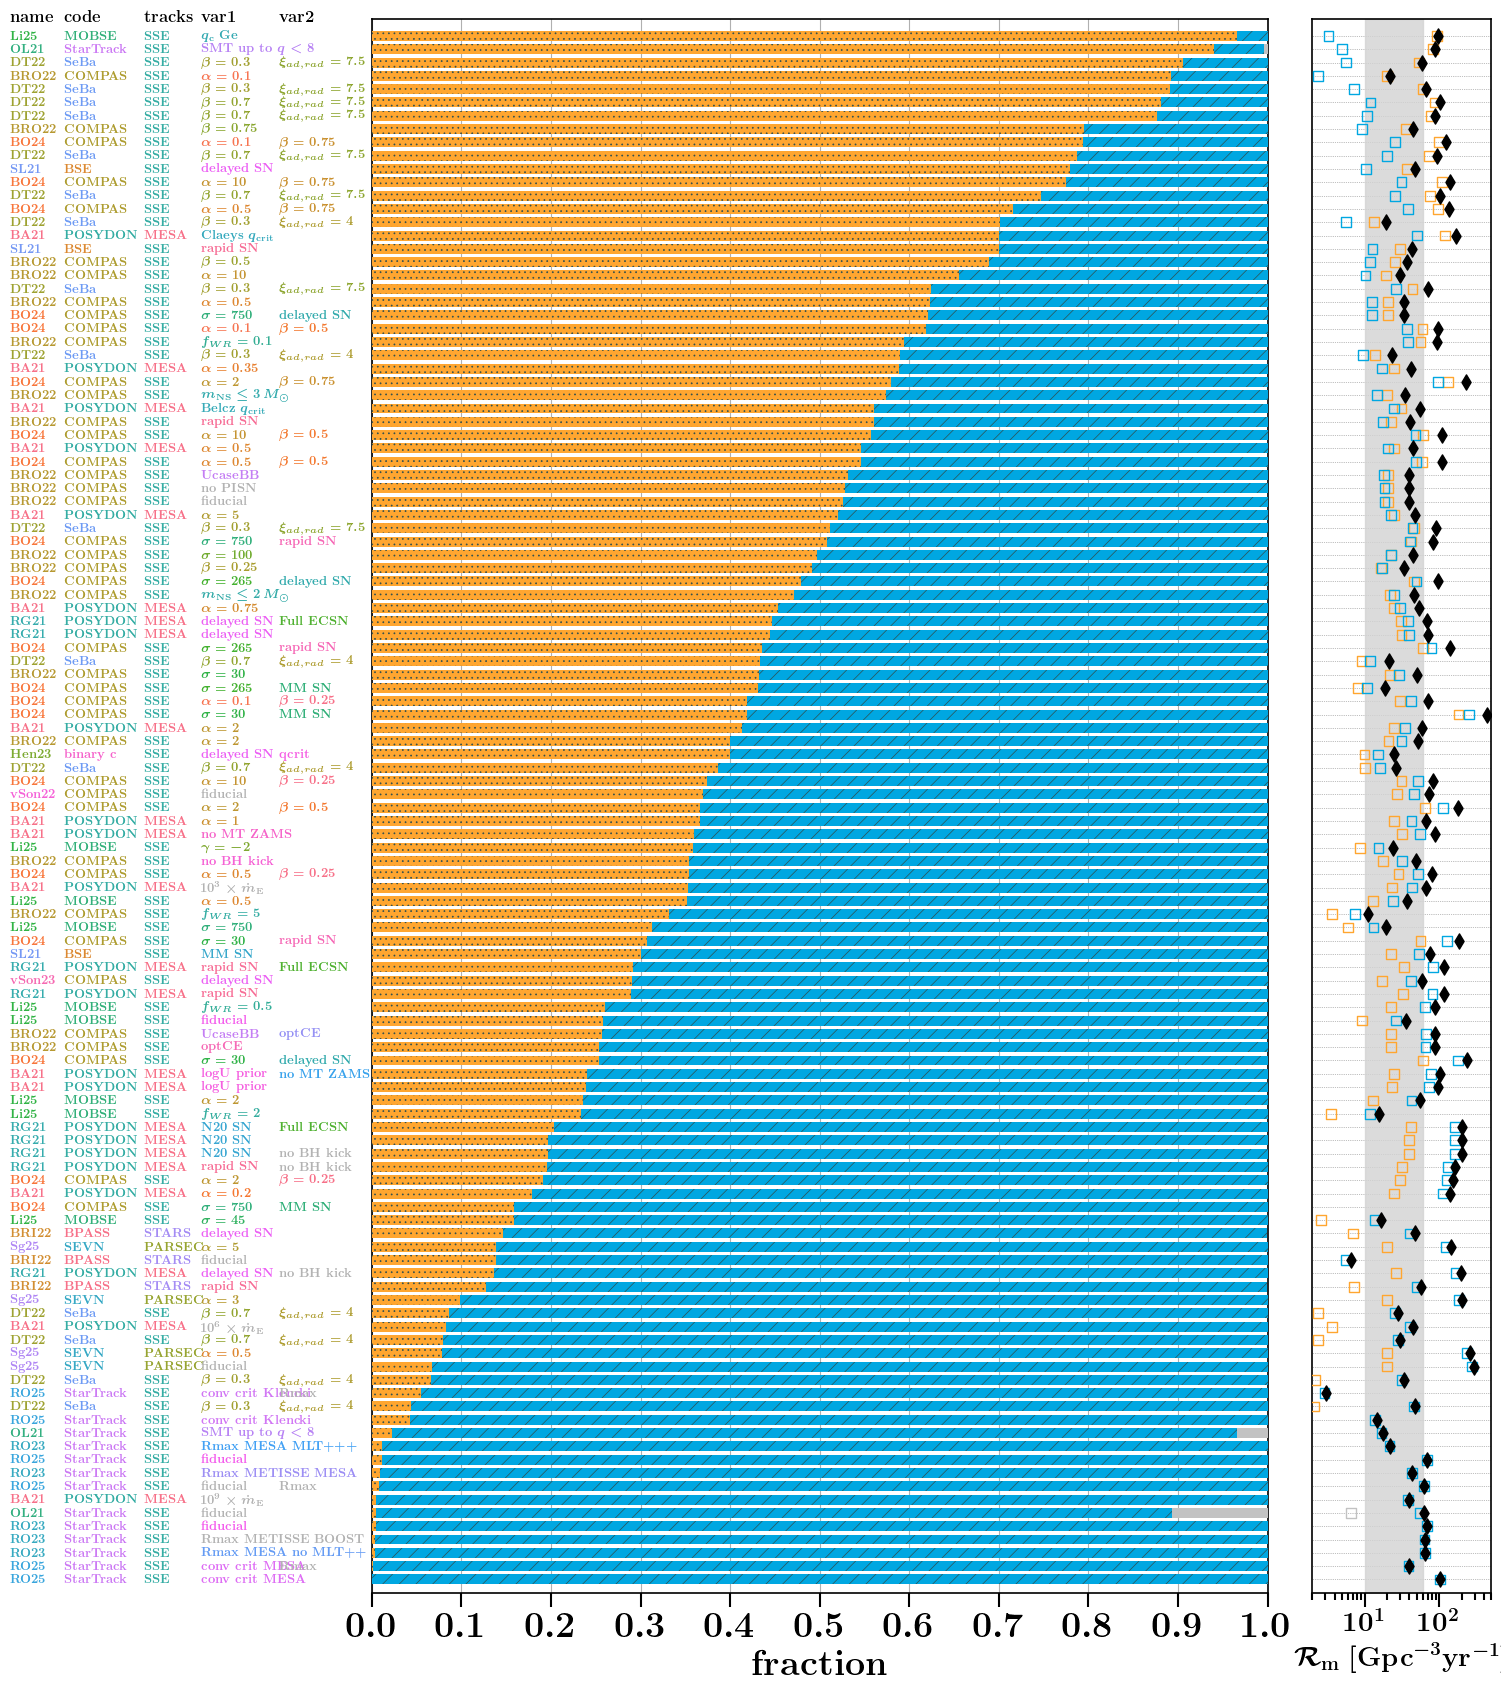

path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/simulation_specs.csv


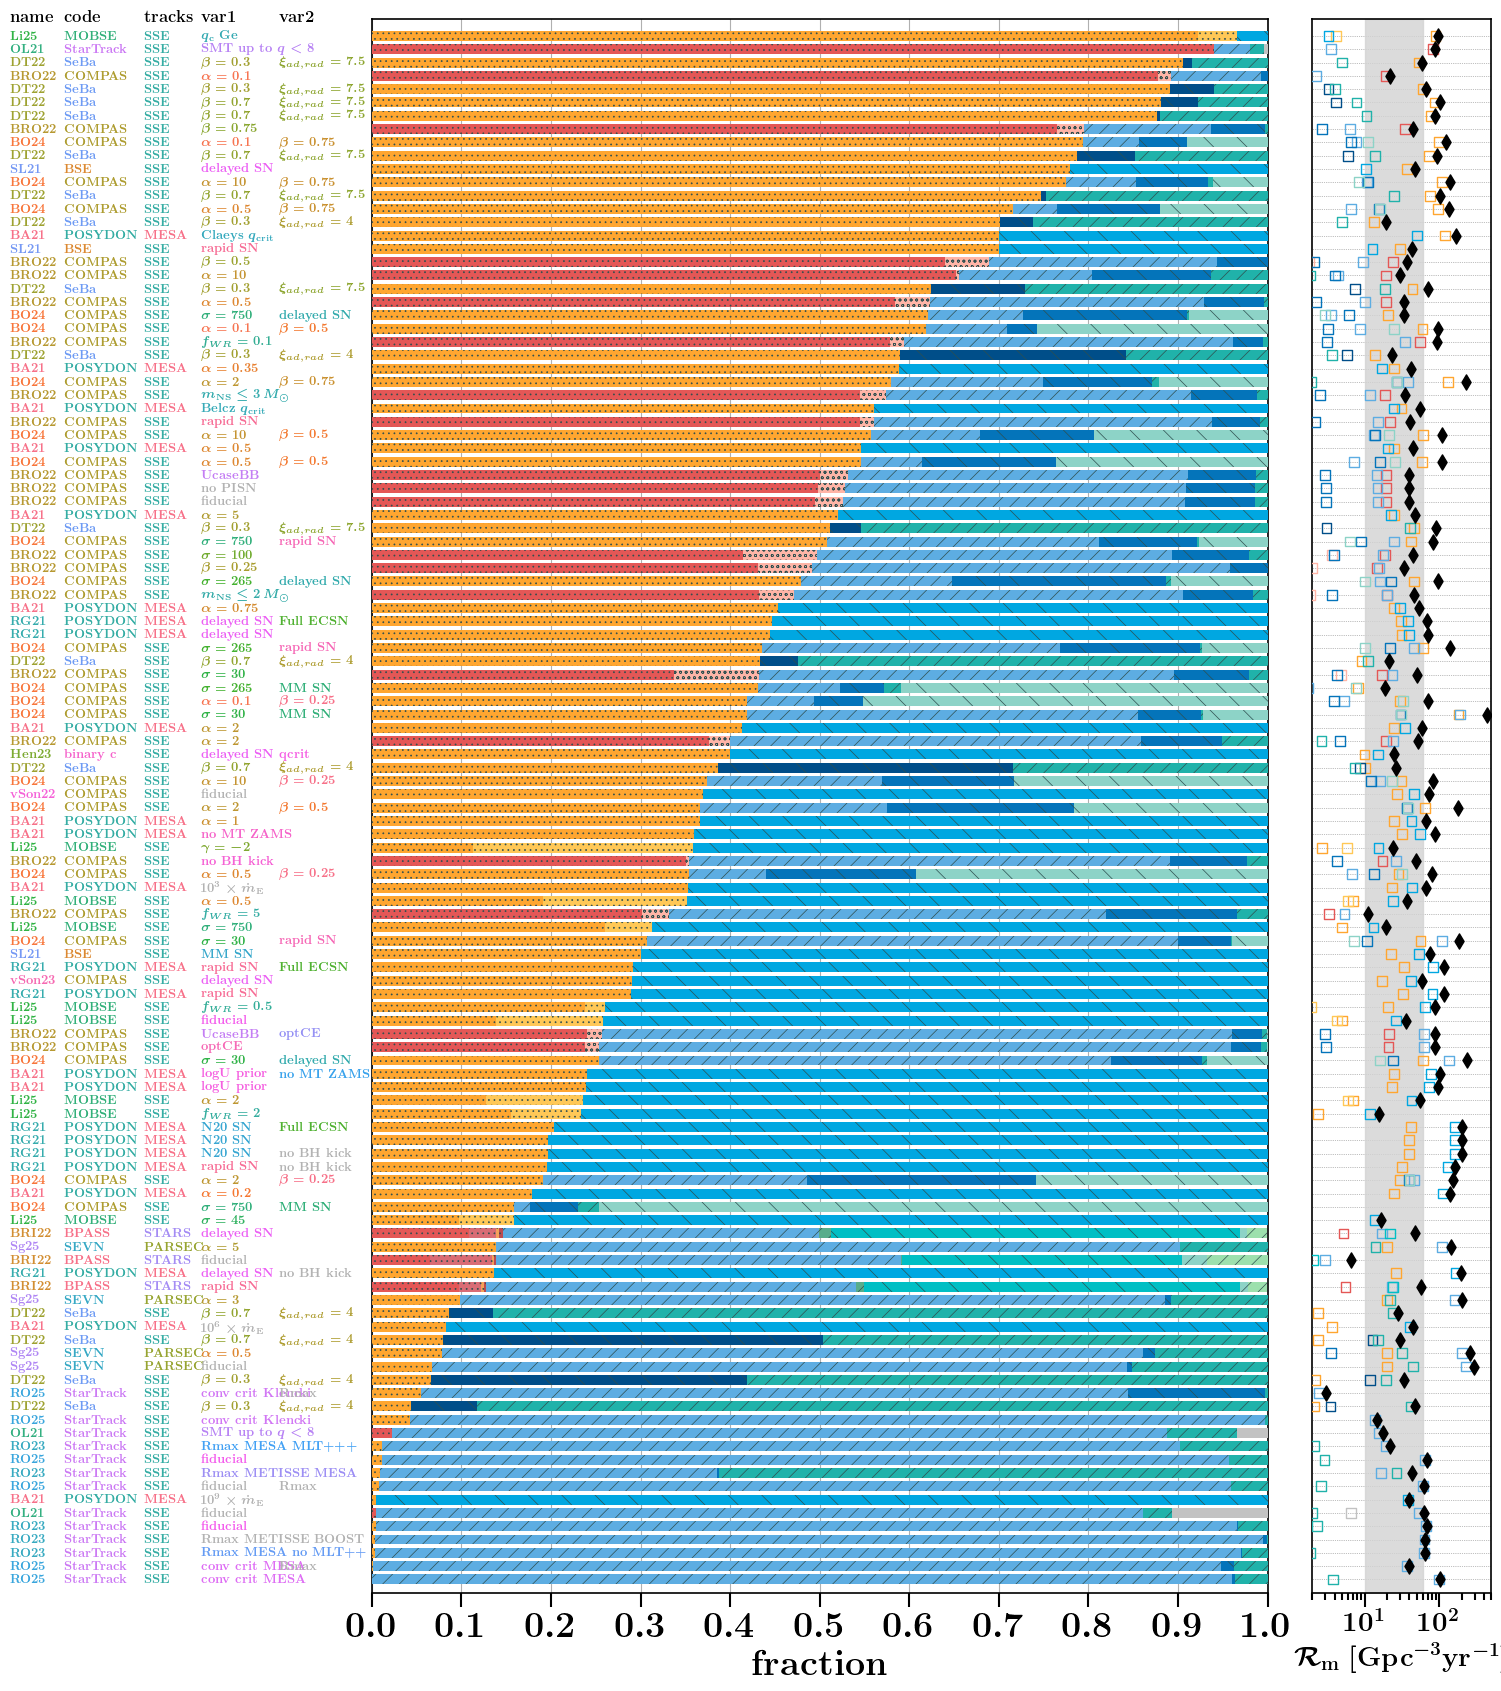

(<Figure size 1500x1700 with 3 Axes>,
 array([<Axes: >, <Axes: xlabel='$\\textbf{fraction}$'>,
        <Axes: xlabel='$\\mathcal{R}_{\\rm{m}} \\ [\\rm{Gpc}^{-3} \\rm{yr}^{-1}] $'>],
       dtype=object))

In [7]:


# --- File and plot setup ---
path_to_file = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/'

# plot only CE or not CE 
fig, axes = plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-BH',
    fc_key = "CE_simple" ,
    sort_header = "fraction without common envelope",
    save_path = "formation_channels_BH-BH_simple.pdf"
    )


# plot detailed formation channels CE 
plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-BH',
    fc_key = "CE_detailed" ,
    sort_header = "fraction without common envelope",
    save_path = "formation_channels_BH-BH_detailed.pdf"
    )


path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/simulation_specs.csv


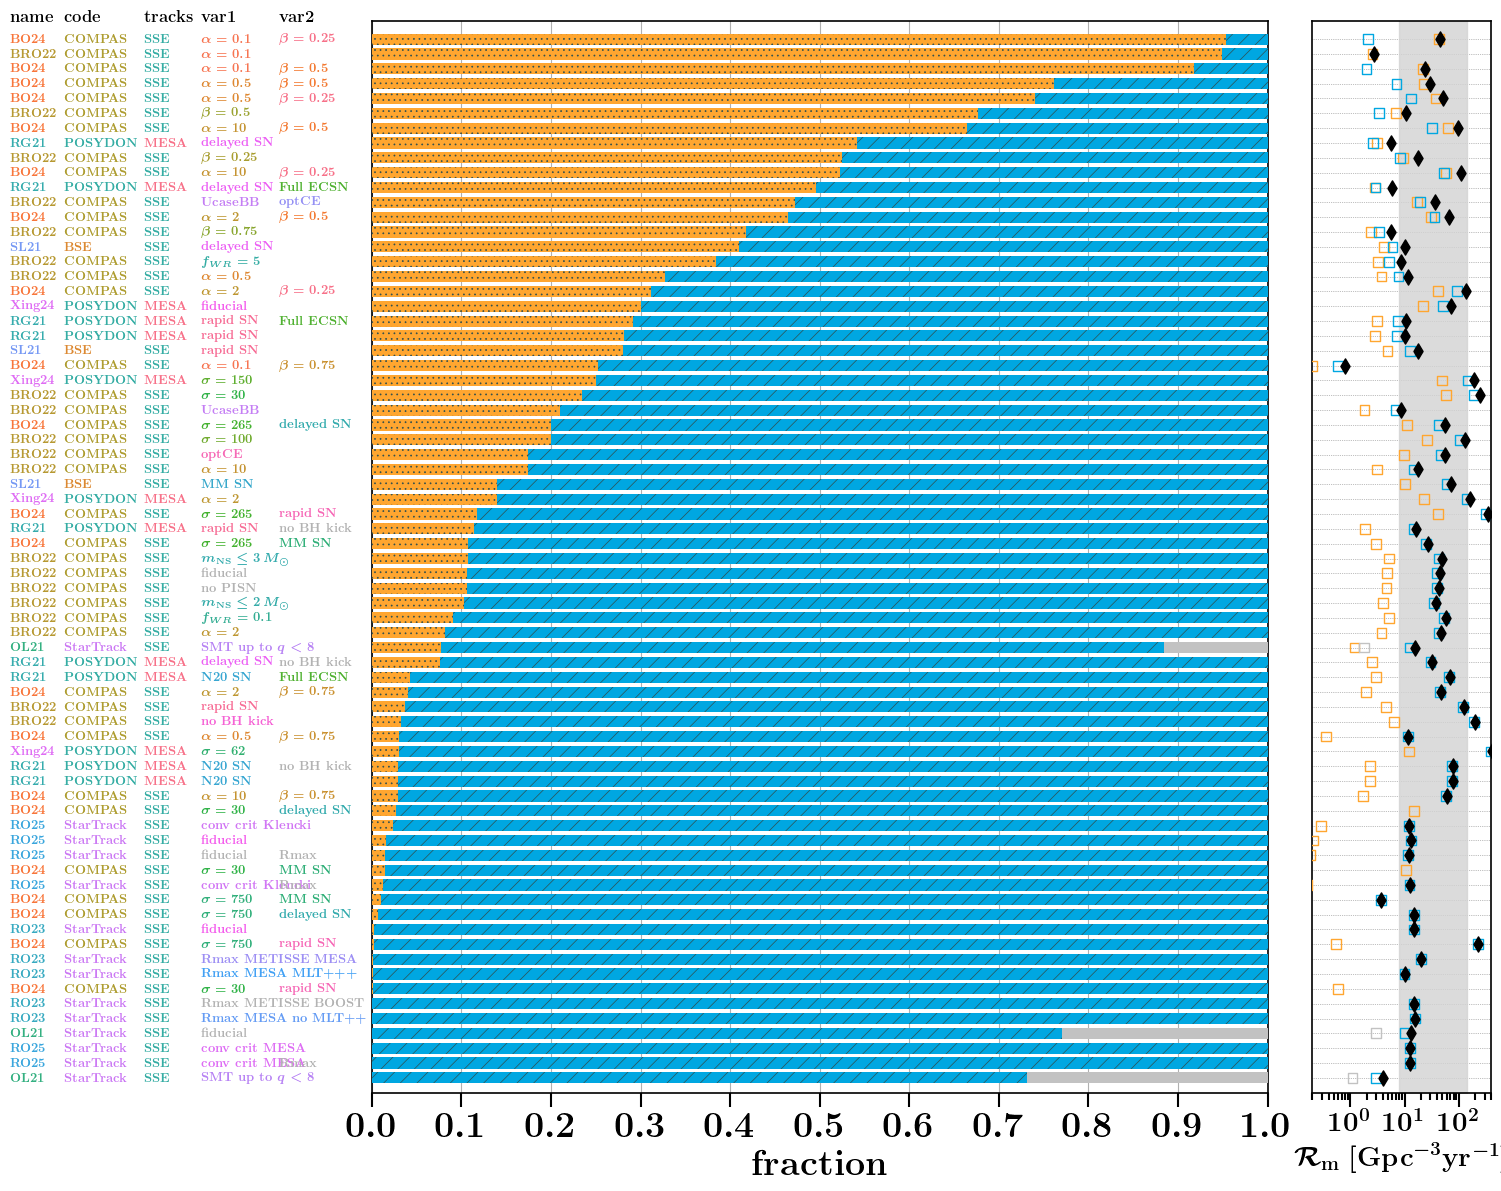

path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/simulation_specs.csv


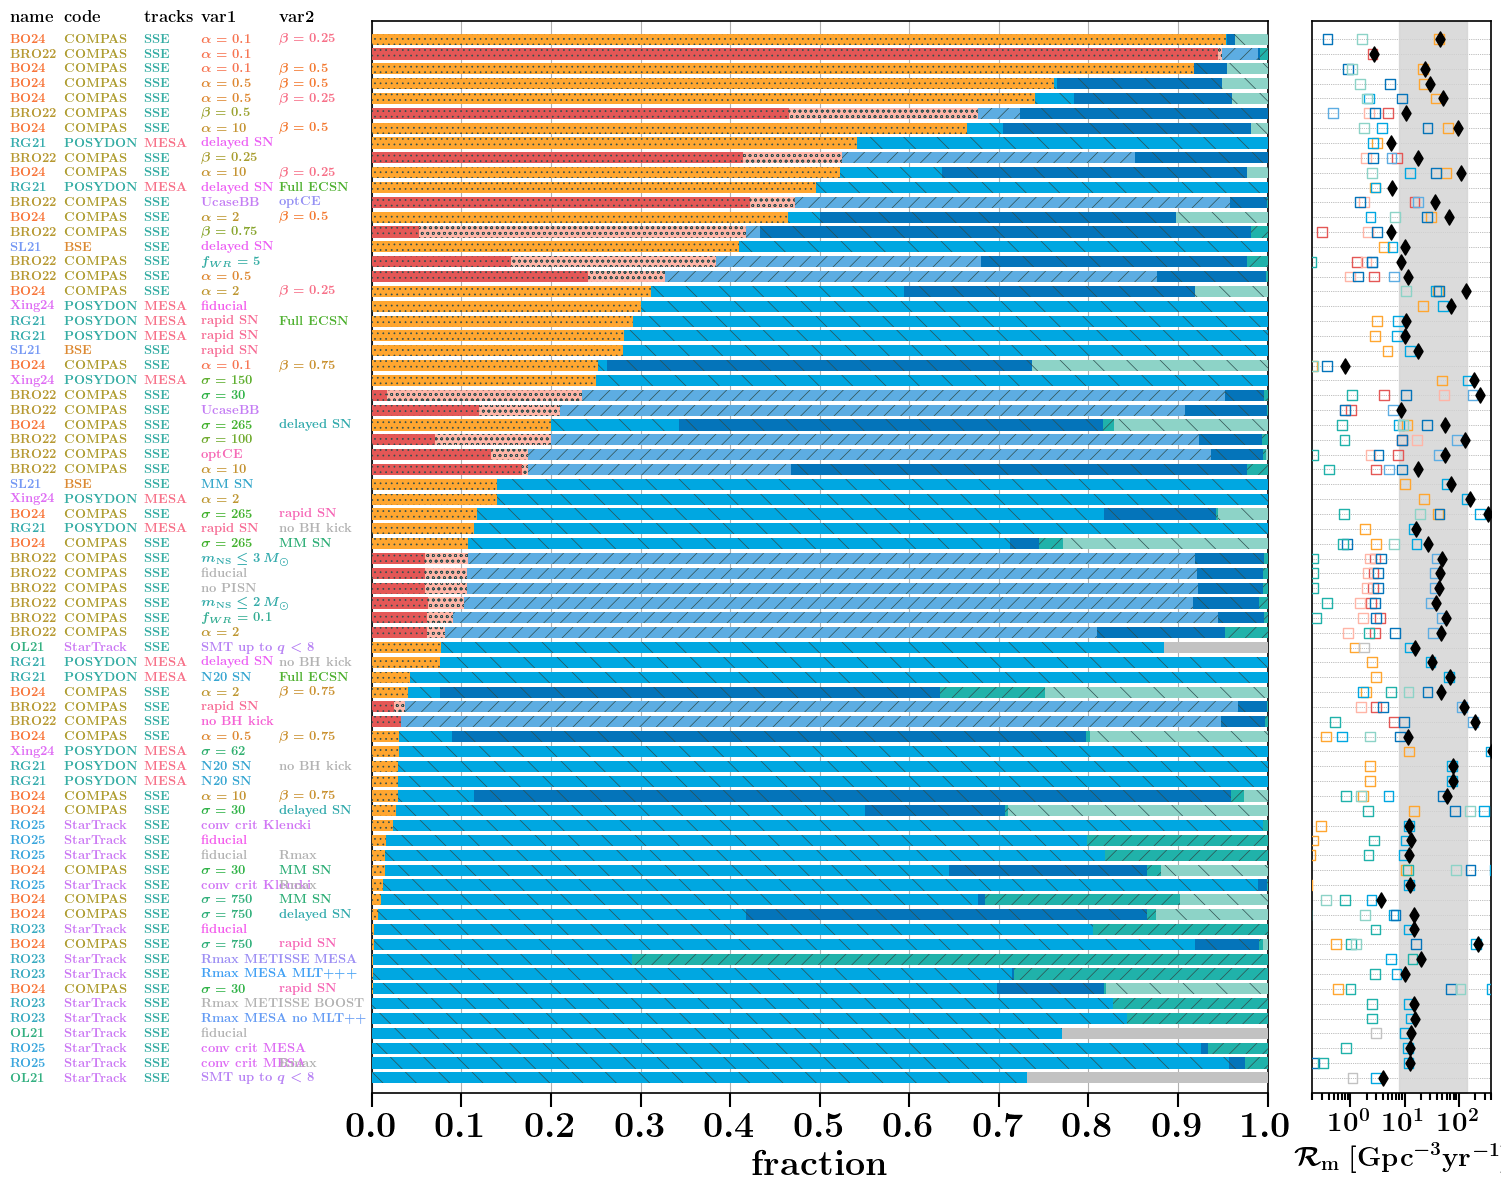

(<Figure size 1500x1200 with 3 Axes>,
 array([<Axes: >, <Axes: xlabel='$\\textbf{fraction}$'>,
        <Axes: xlabel='$\\mathcal{R}_{\\rm{m}} \\ [\\rm{Gpc}^{-3} \\rm{yr}^{-1}] $'>],
       dtype=object))

In [8]:


# --- File and plot setup ---
path_to_file = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/'

# plot only CE or not CE 
fig, axes = plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-NS',
    fc_key = "CE_simple" ,
    sort_header = "fraction without common envelope",
    save_path = "formation_channels_BH-NS_simple.pdf"
    )


# plot detailed formation channels CE 
plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-NS',
    fc_key = "CE_detailed" ,
    sort_header = "fraction without common envelope",
    save_path = "formation_channels_BH-NS_detailed.pdf"
    )


path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/simulation_specs.csv


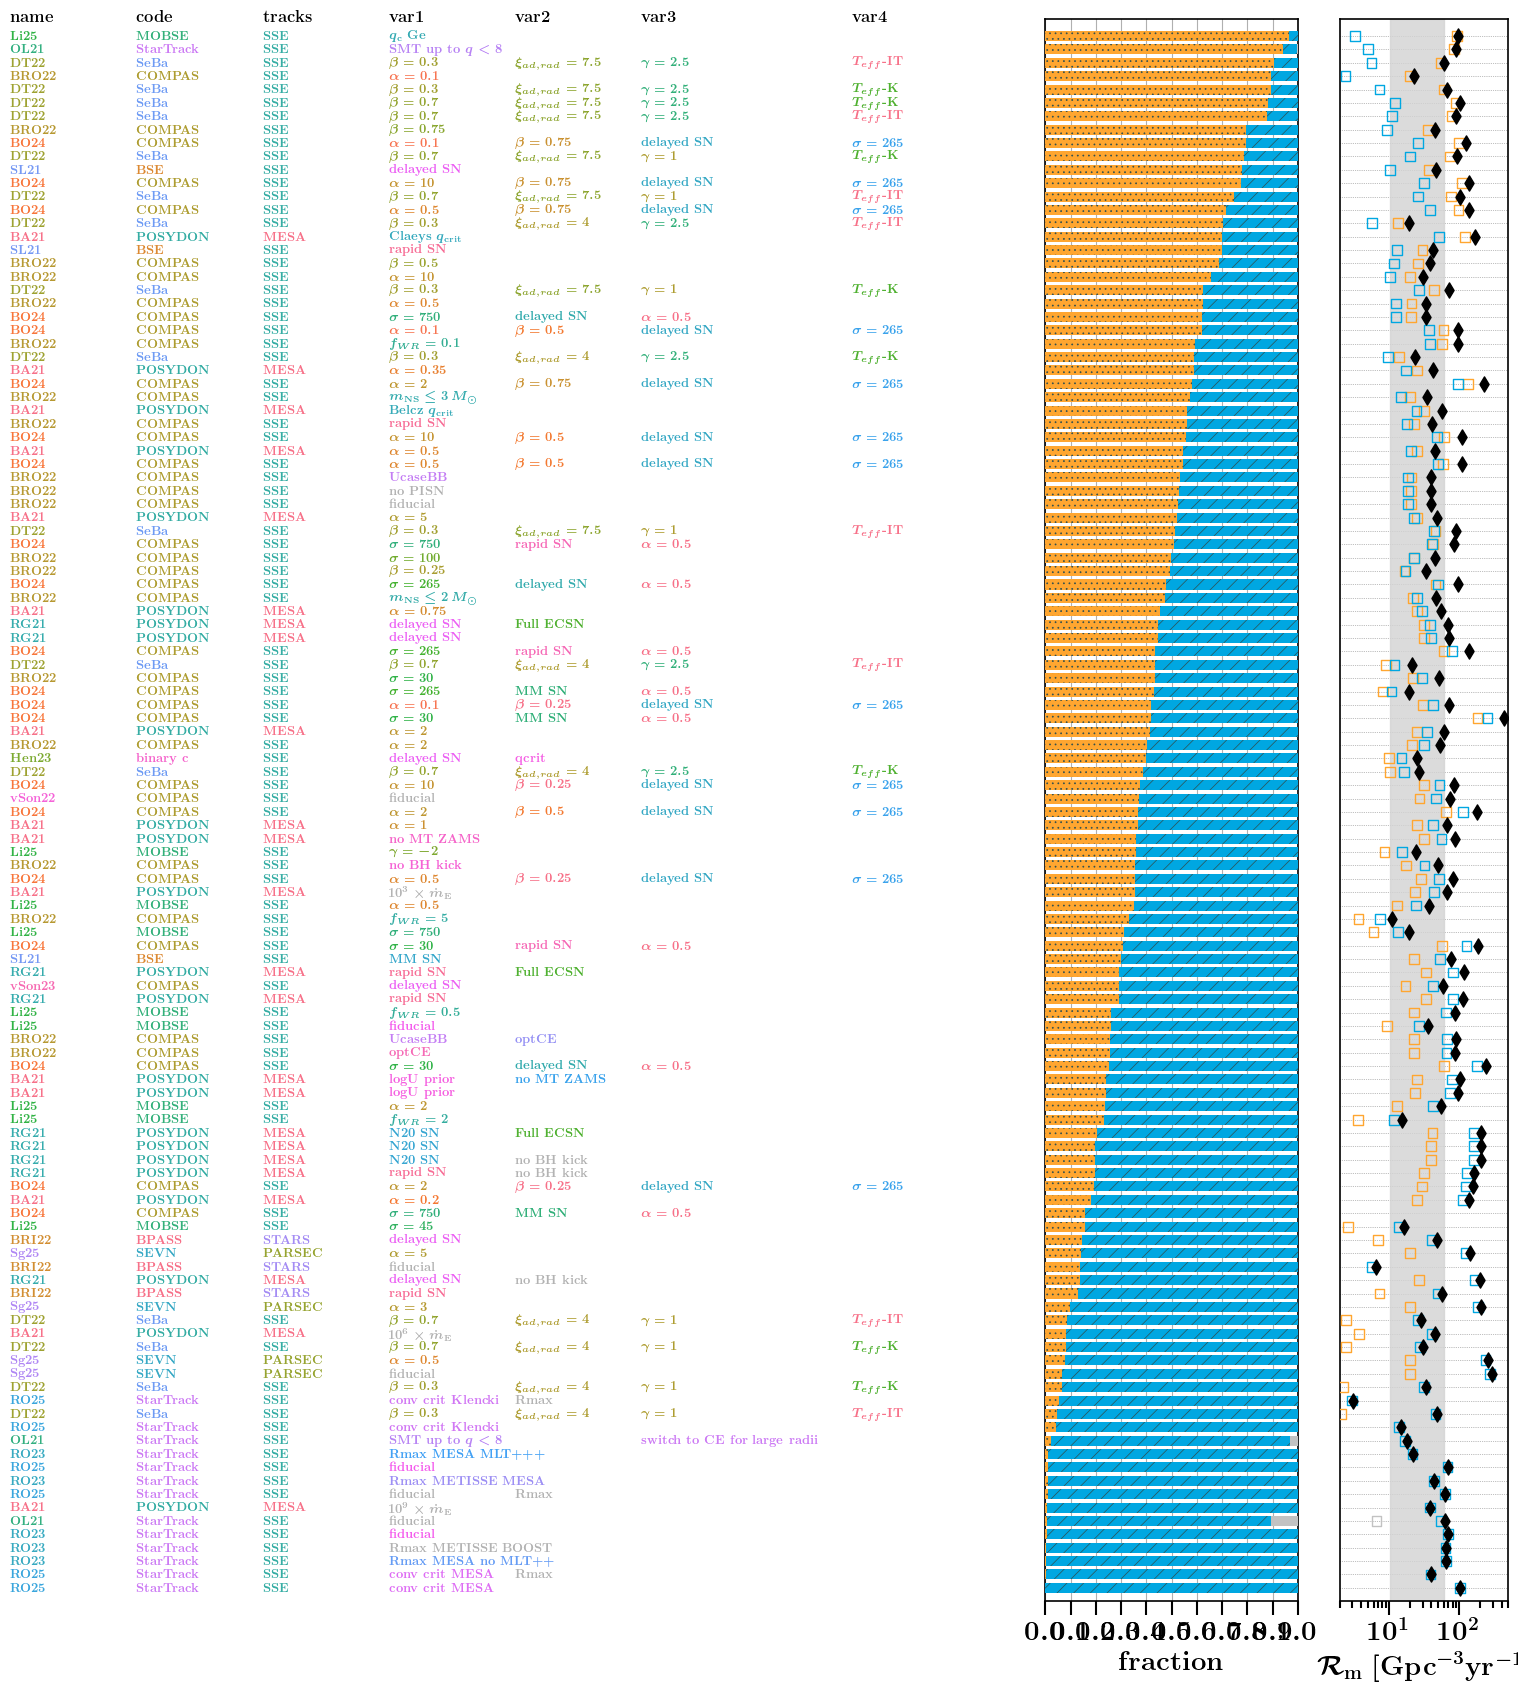

In [9]:


# --- File and plot setup ---
path_to_file = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/'

# plot only CE or not CE 
fig, axes = plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'BH-BH',
    fc_key = "CE_simple" ,
    sort_header = "fraction without common envelope",
    save_path = "formation_channels_BH-BH_simple_specs.pdf",
    fig_formtype='emph_specs'
    )


# # plot detailed formation channels CE 
# plot_formation_channel_contributions(
#     path_to_file=path_to_file,
#     DCOlabel = 'BH-BH',
#     fc_key = "CE_detailed" ,
#     sort_header = "fraction without common envelope",
#     save_path = "formation_channels_BH-NS_detailed_specs.pdf"
#     )




path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/simulation_specs.csv


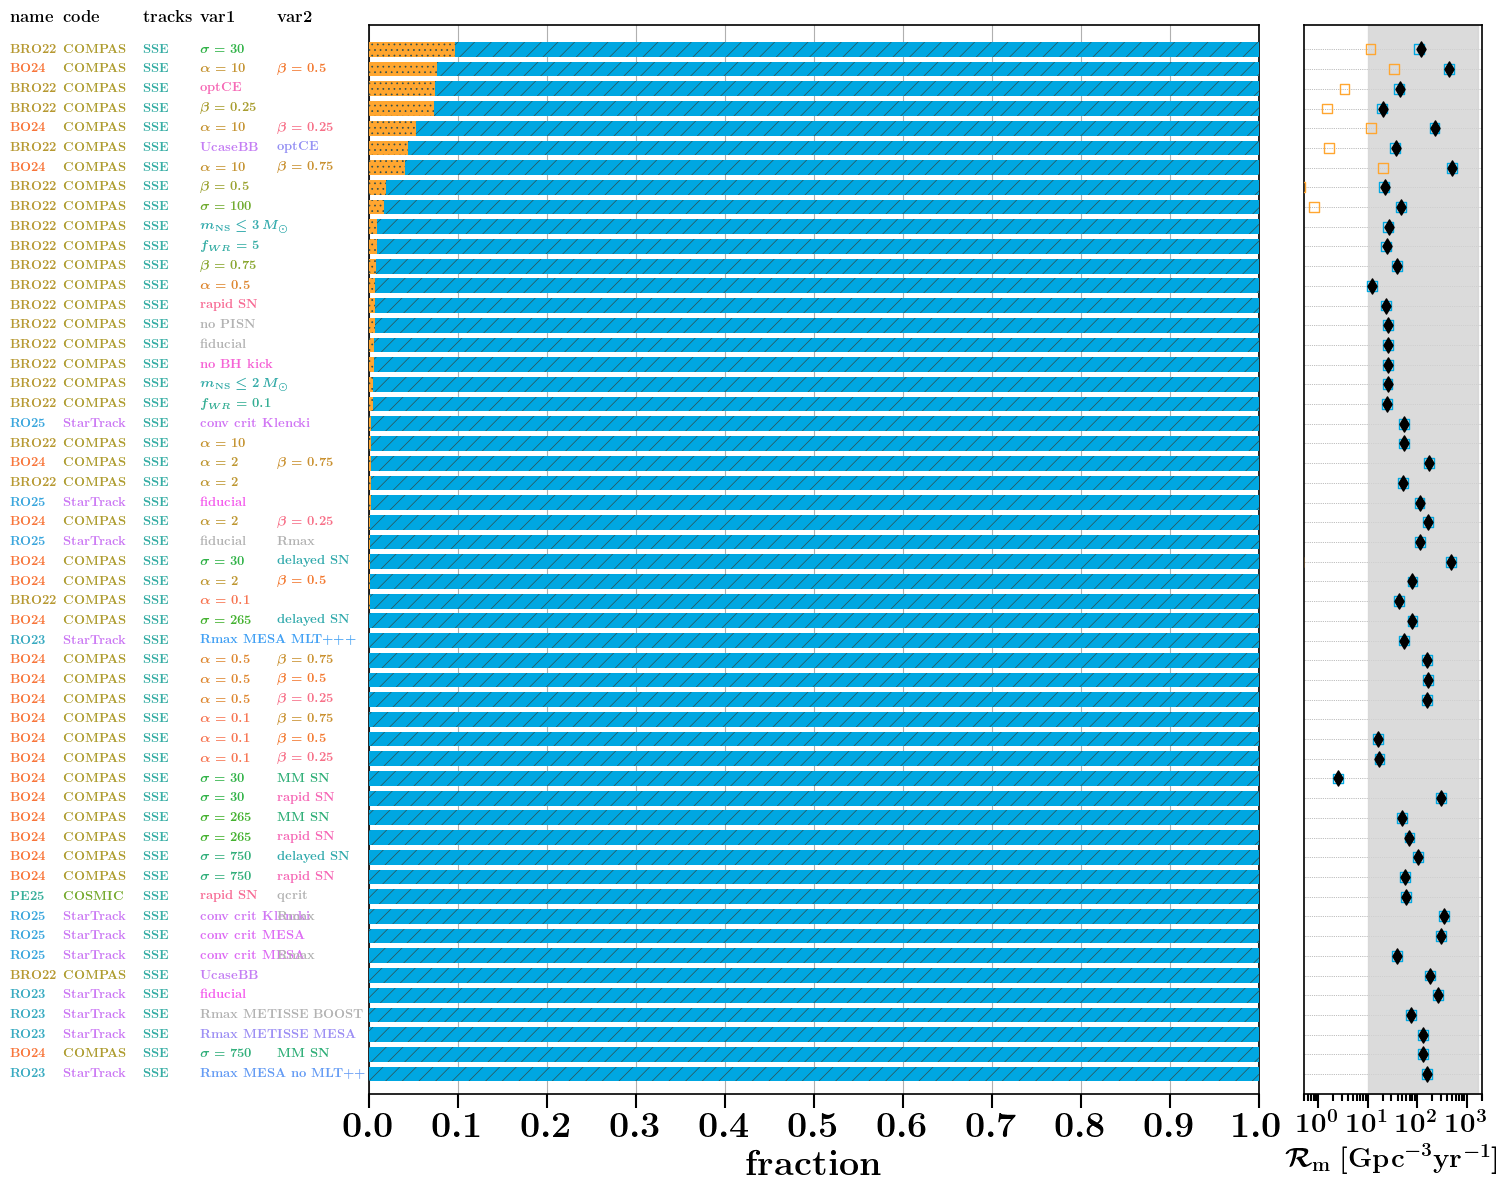

path /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/simulation_specs.csv


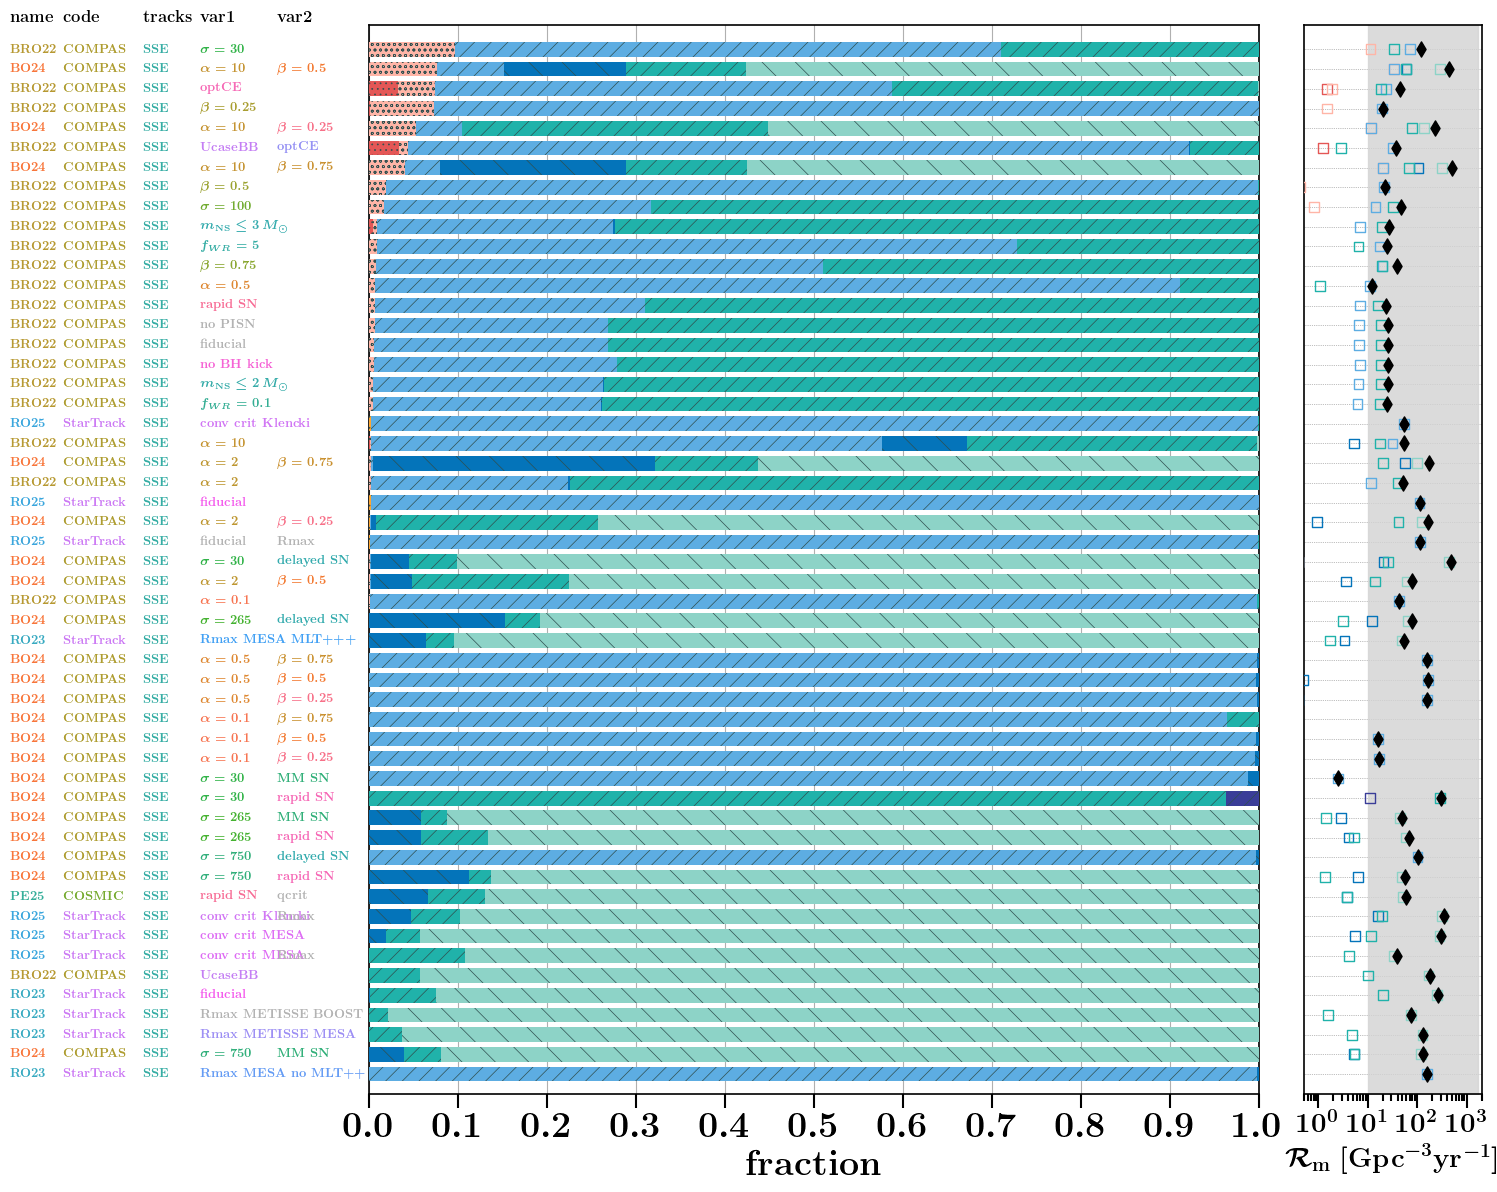

(<Figure size 1500x1200 with 3 Axes>,
 array([<Axes: >, <Axes: xlabel='$\\textbf{fraction}$'>,
        <Axes: xlabel='$\\mathcal{R}_{\\rm{m}} \\ [\\rm{Gpc}^{-3} \\rm{yr}^{-1}] $'>],
       dtype=object))

In [10]:


# --- File and plot setup ---
path_to_file = '/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/'

# plot only CE or not CE 
fig, axes = plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'NS-NS',
    fc_key = "CE_simple" ,
    sort_header = "fraction without common envelope",
    save_path = "formation_channels_NS-NS_simple.pdf"
    )


# plot detailed formation channels CE 
plot_formation_channel_contributions(
    path_to_file=path_to_file,
    DCOlabel = 'NS-NS',
    fc_key = "CE_detailed" ,
    sort_header = "fraction without common envelope",
    save_path = "formation_channels_NS-NS_detailed.pdf"
    )


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib as mpl

def plot_fc_legend(fc_key="CE_simple", include_total=True):
    """
    Create a plot legend for the specified formation channel group.
    
    Parameters
    ----------
    fc_key : str
        Key in fc_dict (e.g., "CE_simple" or "CE_detailed").
    include_total : bool
        If True, add the 'total' diamond marker to the legend.
    """
    mpl.rcParams["text.usetex"] = True
    
    fc_dict = obtain_fc_dict()
    
    if fc_key not in fc_dict:
        raise ValueError(f"fc_key '{fc_key}' not found in fc_dict. "
                         f"Available keys: {list(fc_dict.keys())}")
    
    group = fc_dict[fc_key]
    handles, labels = [], []
    
    # Add bar patches for channels
    if "channels" in group:  
        for ch in group["channels"]:
            patch = mpatches.Patch(
                facecolor=ch["color"], 
                hatch=ch["hatch"] if ch["hatch"] else "",
                edgecolor="black",
                linewidth=0.8
            )
            handles.append(patch)
            labels.append(ch.get("label", ch["name"]))
    else:  
        # single entry (unlikely for CE_simple/detailed but valid for total-only plots)
        ch = group
        patch = mpatches.Patch(
            facecolor=ch["color"], 
            hatch=ch["hatch"] if ch["hatch"] else "",
            edgecolor="black",
            linewidth=0.8
        )
        handles.append(patch)
        labels.append(ch.get("label", ch["name"]))
    
    # Add the total marker if requested
    if include_total:
        total_ch = fc_dict["total"]
        total_marker = Line2D(
            [0], [0],
            marker="d", color=total_ch["color"], markersize=14,
            linestyle="None", markeredgecolor="black"
        )
        handles.append(total_marker)
        labels.append(total_ch.get("label", total_ch["name"]))
    
    # Dummy plot for legend only
    fig, ax = plt.subplots(figsize=(7, 2))
    ax.axis("off")
    legend = ax.legend(handles, labels, loc="center", frameon=True, ncol=5, fontsize=20)
    save_path=fc_key + '_lgd.pdf'
    fig.savefig(save_path, format='pdf', bbox_inches='tight')
    plt.show()


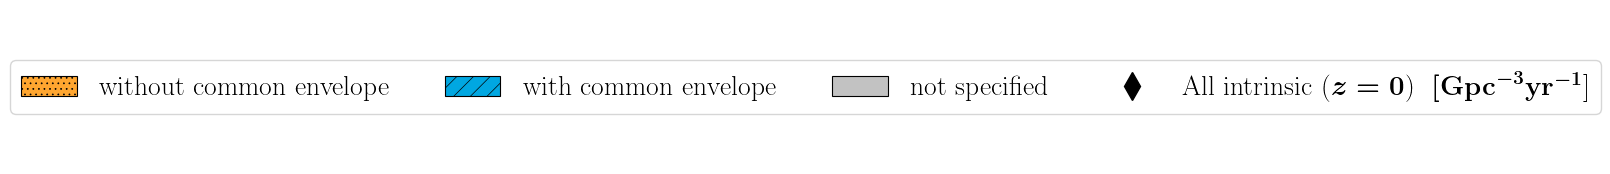

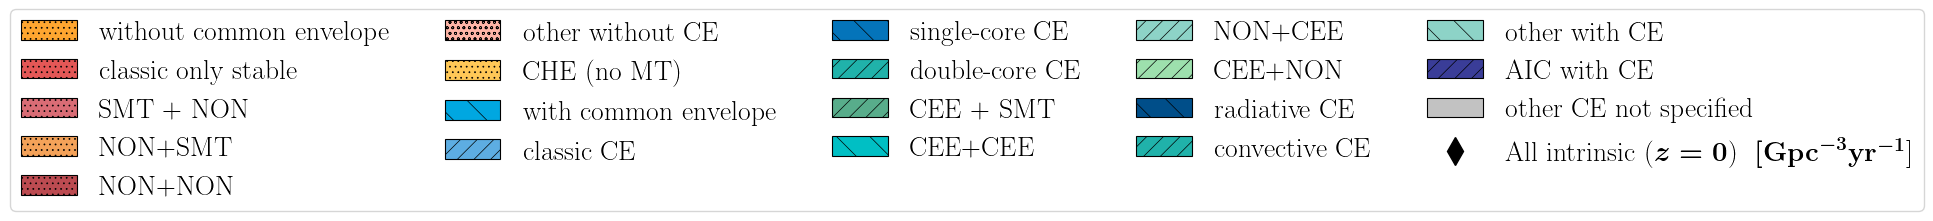

In [12]:
plot_fc_legend("CE_simple")
plot_fc_legend("CE_detailed")
# plot_fc_legend("total")

## Parameter Variation Investigation

Saved big plot to: BH-BH_fraction_withoutCE_all.pdf
Saved grid plot to: BH-BH_fraction_withoutCE_grid.pdf


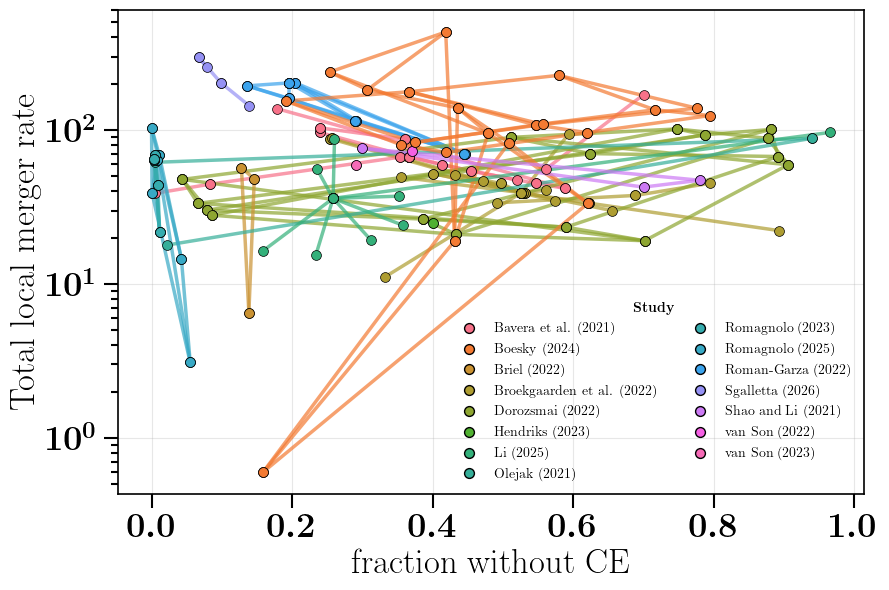

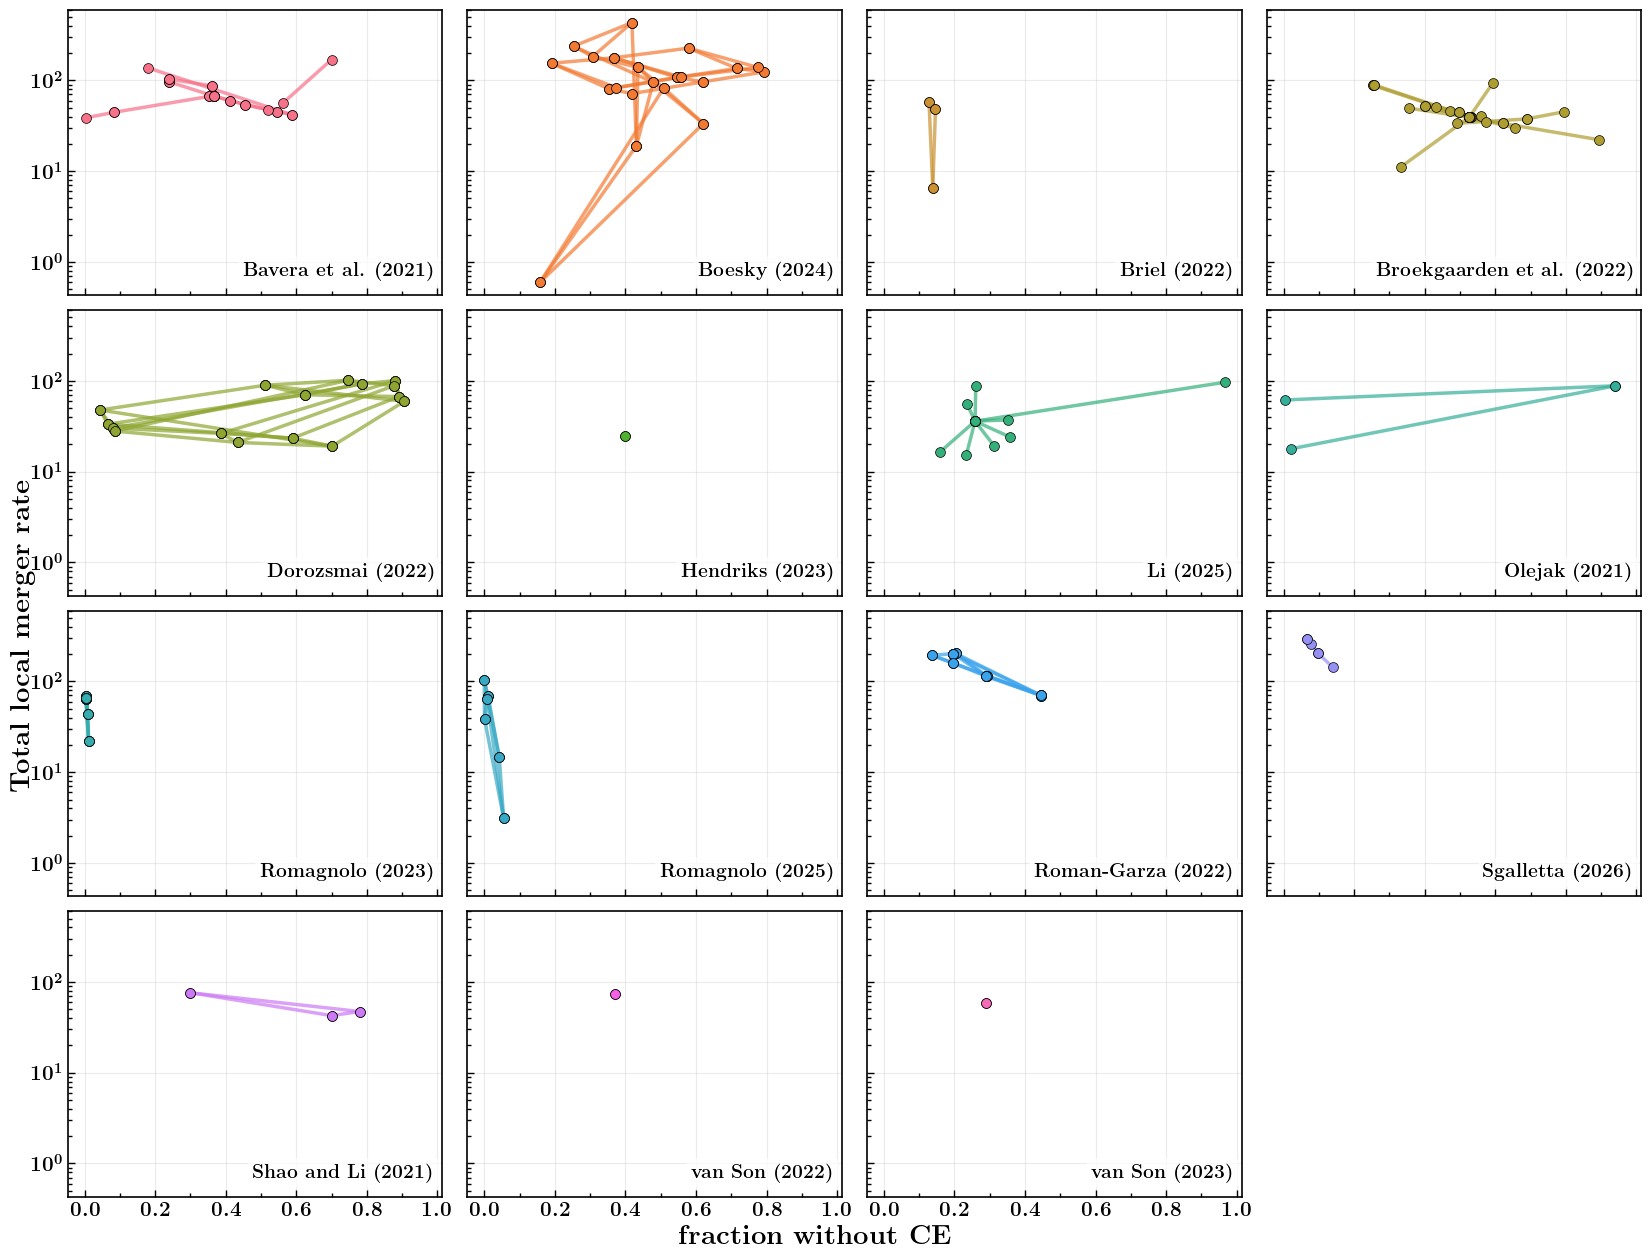

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import math
from matplotlib.ticker import AutoMinorLocator
%matplotlib inline

def plot_withoutCE_all_and_by_study(
    path_to_file,
    DCOlabel="BH-BH",
    relation_file=None,
    marker="o",
    size=50,
    line_alpha=0.7,
    line_style="-",
    line_width=2.5,
    figsize_all=(8, 6),
    ncols_grid=4,
    figsize_grid_per_panel=(4.0, 3.2),  # (width, height) per subplot
    cmap_name="tab20",
    sharex=True,
    sharey=True,
    save_big_pdf=None,
    save_grid_pdf=None,
    dpi=300,
):
    """
    Make:
      (1) one big plot: fraction without CE vs total intrinsic rate for all studies
      (2) a subplot grid: same relation, one panel per study (legend)

    Returns
    -------
    fig_all, ax_all, fig_grid, axes_grid
    """

    # --- Load relation file (pairs of models) ---
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # --- Load rates file (fractions + total rate per model) ---
    rates_file = f"{DCOlabel}_rates_review.csv"
    df_rates = pd.read_csv(os.path.join(path_to_file, rates_file))
    df_rates = df_rates.fillna(0.0).set_index("model")

    # --- Formation-channel metadata ---
    fc_dict = obtain_fc_dict()
    fc_total_header = fc_dict["total"]["name"]      # column name for total intrinsic rate
    yname = fc_dict["total"]["axlabel"]             # y-axis label (rate)

    # x axis label for "fraction without common envelope"
    channels = fc_dict["CE_simple"]["channels"]
    channel_dict = next(ch for ch in channels if ch["name"] == "fraction without common envelope")
    xname = channel_dict["axlabel"]

    # --- Studies (legend groups) ---
    legends = list(df_rel["legend"].dropna().unique())
    legends_sorted = sorted(legends)

    # --- Color map ---
    if cmap_name.lower() == "husl":
        palette = sns.color_palette("husl", len(legends_sorted))
    else:
        cmap = plt.get_cmap(cmap_name)
        palette = [cmap(i / max(1, len(legends_sorted)-1)) for i in range(len(legends_sorted))]

    color_map = {leg: palette[i] for i, leg in enumerate(legends_sorted)}


    # ------------- helper: plot a set of relations onto an axis -------------
    def plot_relations_on_ax(ax, df_rel_subset, legend_for_color=None):
        """
        Plot points for models and connect from->to for each row in df_rel_subset.
        If legend_for_color is None, color per row's legend.
        """
        for _, row in df_rel_subset.iterrows():
            leg = row["legend"]
            color = color_map[legend_for_color] if legend_for_color is not None else color_map.get(leg, "k")

            m_from = row["from_modelname"]
            m_to = row["to_modelname"]

            coords = {}
            for model in [m_from, m_to]:
                if model not in df_rates.index:
                    # quietly skip missing models (or print if you prefer)
                    # print(f"Warning: model '{model}' not found in rates file.")
                    continue

                x = df_rates.loc[model, "fraction without common envelope"]
                y = df_rates.loc[model, fc_total_header]
                coords[model] = (x, y)

                ax.scatter(
                    x, y,
                    s=size,
                    c=[color],
                    marker=marker,
                    edgecolor="k",
                    linewidths=0.5,
                    zorder=10
                )

            if m_from in coords and m_to in coords:
                (x1, y1) = coords[m_from]
                (x2, y2) = coords[m_to]
                ax.plot(
                    [x1, x2], [y1, y2],
                    color=color,
                    linestyle=line_style,
                    linewidth=line_width,
                    alpha=line_alpha,
                    zorder=5
                )

    # ===================== (1) BIG PLOT: all studies =====================
    fig_all, ax_all = plt.subplots(1, 1, figsize=figsize_all)

    plot_relations_on_ax(ax_all, df_rel)

    # axes styling
    layoutAxes(ax_all, nameX=xname, nameY=yname)
    ax_all.set_xscale("linear")
    ax_all.set_yscale("log")
    ax_all.grid(True, alpha=0.3)

    # legend (one handle per study)
    handles = []
    for leg in legends_sorted:
        handles.append(
            plt.Line2D([], [], color=color_map[leg], marker=marker, linestyle="",
                       markersize=2*np.sqrt(size)/2, markeredgecolor="k", label=leg)
        )
    ax_all.legend(handles=handles, loc="best", frameon=False, title=r"$\textbf{Study}$", ncol=2)

    fig_all.tight_layout()

    # ===================== (2) GRID: one panel per study =====================
    n_studies = len(legends_sorted)
    ncols = int(ncols_grid)
    nrows = int(math.ceil(n_studies / ncols))

    fig_grid_w = figsize_grid_per_panel[0] * ncols
    fig_grid_h = figsize_grid_per_panel[1] * nrows
    fig_grid, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_grid_w, fig_grid_h),
        sharex=sharex,
        sharey=sharey
    )

    # Flatten axes robustly
    axes_flat = np.array(axes).reshape(-1)

    # --- style knobs (tweak to taste) ---
    tick_labelsize = 15
    tick_length_major = 5
    tick_length_minor = 3
    tick_width = 1.
    panel_labelsize = 10

    for i, leg in enumerate(legends_sorted):
        ax = axes_flat[i]
        df_sub = df_rel[df_rel["legend"] == leg]

        # plot this study
        plot_relations_on_ax(ax, df_sub, legend_for_color=leg)

        # scales/grid
        ax.set_xscale("linear")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.25)

        # --- put "model/study name" inside bottom-right of panel ---
        ax.text(
            0.98, 0.05, r'$\textbf{%s}$'%str(leg),
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=14,          # ← larger
            fontweight="bold",    # ← bold
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.75,
                edgecolor="none"
            ),
            zorder=20
        )

        # --- ticks: bigger labels, shorter ticks, minor ticks on x ---
        ax.tick_params(
            axis="both", which="major",
            labelsize=tick_labelsize,
            length=tick_length_major,
            width=tick_width,
            direction="in"
        )
        ax.tick_params(
            axis="both", which="minor",
            labelsize=tick_labelsize,
            length=tick_length_minor,
            width=tick_width,
            direction="in"
        )

        # minor ticks on x-axis
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))  # 1 minor tick between majors; use 5 for denser
        ax.tick_params(axis="x", which="minor", bottom=True)
    
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
            
    # Turn off unused axes
    for j in range(n_studies, len(axes_flat)):
        axes_flat[j].axis("off")

    # Common labels if sharex/sharey (optional)
    # If you truly want *no* gaps, these sup labels can collide; comment out if so.
    
    
    label_fontsize = 20   # adjust to taste
    ylabel_pad = 15       # moves label further left

    if sharex:
        fig_grid.supxlabel(
            r'$\textbf{%s}$'%xname,
            fontsize=label_fontsize,
            y=0.02  # vertical position tweak if needed
        )

    if sharey:
        fig_grid.supylabel(
            r'$\textbf{%s}$'%yname,
            fontsize=label_fontsize,
            x=0.02  # moves label left (acts like padding)
    )


    # --- remove spacing between subpanels ---
    # Do NOT use tight_layout if you want zero gaps; use subplots_adjust instead.
    fig_grid.subplots_adjust(left=0.06, right=0.995, bottom=0.06, top=0.995,
                             wspace=0.0, hspace=0.0)

#     # common labels if sharex/sharey
#     if sharex:
#         fig_grid.supxlabel(xname)
#     if sharey:
#         fig_grid.supylabel(yname)

    fig_grid.tight_layout()
    
    # ===================== SAVE FIGURES =====================
    if save_big_pdf is not None:
        fig_all.savefig(
            save_big_pdf,
            format="pdf",
            bbox_inches="tight",
            dpi=dpi,
            transparent=True
        )
        print(f"Saved big plot to: {save_big_pdf}")

    if save_grid_pdf is not None:
        fig_grid.savefig(
            save_grid_pdf,
            format="pdf",
            bbox_inches="tight",
            dpi=dpi,
            transparent=True
        )
        print(f"Saved grid plot to: {save_grid_pdf}")
    
    
    return fig_all, ax_all, fig_grid, axes


# ---- Example call ----

DCOlabel="BH-BH"

fig_all, ax_all, fig_grid, axes_grid = plot_withoutCE_all_and_by_study(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/",
    DCOlabel=DCOlabel,
    cmap_name="husl", # "rainbow", # color map 
    save_big_pdf=f"{DCOlabel}_fraction_withoutCE_all.pdf",
    save_grid_pdf=f"{DCOlabel}_fraction_withoutCE_grid.pdf",
    ncols_grid=4,
    figsize_all=(9, 6),
    figsize_grid_per_panel=(4.2, 3.2),
)
plt.show()



## Same plot with extra SFRD models

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import math
from matplotlib.ticker import AutoMinorLocator
import re
%matplotlib inline

def plot_withoutCE_all_and_by_study(
    path_to_file,
    DCOlabel="BH-BH",
    broek_sfrd_path=None,
    relation_file=None,
    marker="o",
    size=50,
    line_alpha=0.7,
    line_style="-",
    line_width=2.5,
    figsize_all=(8, 6),
    ncols_grid=4,
    figsize_grid_per_panel=(4.0, 3.2),  # (width, height) per subplot
    cmap_name="tab20",
    sharex=True,
    sharey=True,
    save_big_pdf=None,
    save_grid_pdf=None,
    dpi=300,
):
    """
    Make:
      (1) one big plot: fraction without CE vs total intrinsic rate for all studies
      (2) a subplot grid: same relation, one panel per study (legend)

    Returns
    -------
    fig_all, ax_all, fig_grid, axes_grid
    """
    
    def map_dco_label_for_broek_file(dco_label: str) -> str:
        """
        Map plotting labels like 'BH-BH' to file labels like 'BHBH'.
        """
        mapping = {
            "BH-BH": "BHBH",
            "BH-NS": "BHNS",
            "NS-NS": "NSNS",
            "BHBH": "BHBH",
            "BHNS": "BHNS",
            "NSNS": "NSNS",
        }
        if dco_label not in mapping:
            raise ValueError(f"Unsupported DCOlabel: {dco_label}")
        return mapping[dco_label]
    

    # --- Load relation file (pairs of models) ---
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # --- Load rates file (fractions + total rate per model) ---
    rates_file = f"{DCOlabel}_rates_review.csv"
    df_rates = pd.read_csv(os.path.join(path_to_file, rates_file))
    df_rates = df_rates.fillna(0.0).set_index("model")

    # --- OPTIONAL: load van Son 2023 secondary SFRD variations ---
    vanson_sfrd_file = os.path.join(path_to_file, "extra_fc_rates", "vanSon2023_sfrd.csv")
    if os.path.exists(vanson_sfrd_file):
        df_rates_vanson_sfrd = pd.read_csv(vanson_sfrd_file).fillna(0.0).set_index("model")
    else:
        df_rates_vanson_sfrd = None
    
    # --- OPTIONAL: load Broekgaarden secondary SFRD/S(Z,z) variations ---
    broek_file_label = map_dco_label_for_broek_file(DCOlabel)

    if broek_sfrd_path is None:
        broek_sfrd_file = os.path.join(
            path_to_file,
            "extra_fc_rates",
            f"Broekgaarden_{broek_file_label}_all_SFRD_variations_combined.csv"
        )
    else:
        # allow either a direct file path OR a folder path
        if os.path.isdir(broek_sfrd_path):
            broek_sfrd_file = os.path.join(
                broek_sfrd_path,
                f"Broekgaarden_{broek_file_label}_all_SFRD_variations_combined.csv"
            )
        else:
            broek_sfrd_file = broek_sfrd_path

    print("Looking for Broekgaarden SFRD file at:", broek_sfrd_file)
    print("Exists?", os.path.exists(broek_sfrd_file))

    if os.path.exists(broek_sfrd_file):
        df_rates_broek_sfrd = pd.read_csv(broek_sfrd_file).fillna(0.0)
        print("Loaded Broekgaarden SFRD rows:", len(df_rates_broek_sfrd))
        print("Columns:", list(df_rates_broek_sfrd.columns))
    else:
        df_rates_broek_sfrd = None
        print("Broekgaarden SFRD file not loaded.")
        
        
        
        
        
    

    # --- Formation-channel metadata ---
    fc_dict = obtain_fc_dict()
    fc_total_header = fc_dict["total"]["name"]      # column name for total intrinsic rate
    yname = fc_dict["total"]["axlabel"]             # y-axis label (rate)

    # x axis label for "fraction without common envelope"
    channels = fc_dict["CE_simple"]["channels"]
    channel_dict = next(ch for ch in channels if ch["name"] == "fraction without common envelope")
    xname = channel_dict["axlabel"]

    # --- Studies (legend groups) ---
    legends = list(df_rel["legend"].dropna().unique())
    legends_sorted = sorted(legends)

    # --- Color map ---
    if cmap_name.lower() == "husl":
        palette = sns.color_palette("husl", len(legends_sorted))
    else:
        cmap = plt.get_cmap(cmap_name)
        palette = [cmap(i / max(1, len(legends_sorted)-1)) for i in range(len(legends_sorted))]

    color_map = {leg: palette[i] for i, leg in enumerate(legends_sorted)}

    # --- explicitly set van Son 2023 study + fiducial model ---
    vanSon_legend = "van Son (2023) "
    vanSon_fiducial_model = "van Son (2023) "
    # --- explicitly set Broekgaarden study label ---
    broek_legend = None
    for leg in legends_sorted:
        leg_clean = str(leg).strip().lower()
        if "broekgaarden" in leg_clean:
            broek_legend = leg
            break

    print("Using broek_legend =", repr(broek_legend))

    print("Using vanSon_legend =", repr(vanSon_legend))
    print("Using vanSon_fiducial_model =", repr(vanSon_fiducial_model))
    print("Using broek_legend =", repr(broek_legend))
    
    
    

    # ------------- helper: plot a set of relations onto an axis -------------
    def plot_relations_on_ax(ax, df_rel_subset, legend_for_color=None):
        """
        Plot points for models and connect from->to for each row in df_rel_subset.
        If legend_for_color is None, color per row's legend.
        """
        for _, row in df_rel_subset.iterrows():
            leg = row["legend"]
            color = color_map[legend_for_color] if legend_for_color is not None else color_map.get(leg, "k")

            m_from = row["from_modelname"]
            m_to = row["to_modelname"]

            coords = {}
            for model in [m_from, m_to]:
                if model not in df_rates.index:
                    continue

                x = df_rates.loc[model, "fraction without common envelope"]
                y = df_rates.loc[model, fc_total_header]
                coords[model] = (x, y)

                ax.scatter(
                    x, y,
                    s=size,
                    c=[color],
                    marker=marker,
                    edgecolor="k",
                    linewidths=0.5,
                    zorder=10
                )

            if m_from in coords and m_to in coords:
                (x1, y1) = coords[m_from]
                (x2, y2) = coords[m_to]
                ax.plot(
                    [x1, x2], [y1, y2],
                    color=color,
                    linestyle=line_style,
                    linewidth=line_width,
                    alpha=line_alpha,
                    zorder=5
                )

    # ------------- helper: plot van Son 2023 secondary SFRD variations -------------
    def plot_vanSon2023_secondary_sfrd(ax, legend_for_color):
        """
        Add the secondary S(Z,z)/SFRD variations for van Son 2023:
        - same color as van Son 2023
        - behind the main relations
        - each extra point connected to the fiducial main-model point
        """
        if df_rates_vanson_sfrd is None:
            return
        if legend_for_color is None:
            return
        if vanSon_fiducial_model is None:
            return
        if vanSon_fiducial_model not in df_rates.index:
            return
        if legend_for_color != vanSon_legend:
            return

        color = color_map[legend_for_color]

        # fiducial point from the MAIN rates file
        x_fid = df_rates.loc[vanSon_fiducial_model, "fraction without common envelope"]
        y_fid = df_rates.loc[vanSon_fiducial_model, fc_total_header]

        # plot all extra points except any duplicate fiducial row in the extra csv
        for model in df_rates_vanson_sfrd.index:
            if "Fiducial" in str(model):
                continue

            x = df_rates_vanson_sfrd.loc[model, "fraction without common envelope"]
            y = df_rates_vanson_sfrd.loc[model, fc_total_header]

            # faint background line to fiducial
            ax.plot(
                [x_fid, x], [y_fid, y],
                color=color,
                linestyle="-",
                linewidth=line_width * 0.45,
                alpha=0.54,
                zorder=0
            )


            # faint background point
            ax.scatter(
                x, y,
                s=size * 0.28,
                c=[color],
                marker=marker,
                edgecolor="none",
                linewidths=0.0,
                alpha=0.18,
                zorder=1
            )
    
    
    
    # ------------- helper: plot Broekgaarden secondary SFRD variations -------------
    def plot_broekgaarden_secondary_sfrd(ax, legend_for_color):
        """
        Add the secondary S(Z,z)/SFRD variations for the Broekgaarden study:
        - same color as Broekgaarden study
        - behind the main relations
        - each extra point connected to the corresponding main-model point
          by matching model_name A/B/.../T to df_rates models like B22-A-fiducial
        """
        print("\n--- plot_broekgaarden_secondary_sfrd ---")
        print("legend_for_color =", repr(legend_for_color))
        print("broek_legend     =", repr(broek_legend))

        if df_rates_broek_sfrd is None:
            print("EXIT: df_rates_broek_sfrd is None")
            return
        if legend_for_color is None:
            print("EXIT: legend_for_color is None")
            return
        if broek_legend is None:
            print("EXIT: broek_legend is None")
            return
        if str(legend_for_color).strip() != str(broek_legend).strip():
            print("EXIT: legend mismatch")
            return
        if legend_for_color not in color_map:
            print("EXIT: legend_for_color not in color_map")
            return

        color = color_map[legend_for_color]

        # Build mapping letter -> main Broekgaarden fiducial model
        main_model_map = {}

        # First pass: explicitly prefer fiducial rows
        for letter in list("ABCDEFGHIJKLMNOPQRST"):
            fid_candidates = [
                str(model).strip()
                for model in df_rates.index
                if re.match(rf"^[A-Z0-9]+-{letter}-fiducial$", str(model).strip(), flags=re.IGNORECASE)
            ]
            if len(fid_candidates) > 0:
                main_model_map[letter] = fid_candidates[0]

        # Second pass: fallback to first B22-letter-* match if no fiducial exists
        for model in df_rates.index:
            model_str = str(model).strip()
            m = re.match(r"^[A-Z0-9]+-([A-T])-", model_str, flags=re.IGNORECASE)
            if m:
                letter = m.group(1).upper()
                if letter not in main_model_map:
                    main_model_map[letter] = model_str

#         print("Broekgaarden main_model_map:")
#         for k in sorted(main_model_map):
#             print(f"  {k} -> {main_model_map[k]}")

        n_plotted = 0

        for _, row in df_rates_broek_sfrd.iterrows():
            letter = str(row["model_name"]).strip().upper()

            if letter not in main_model_map:
                continue

            main_model = main_model_map[letter]

            # Main point from BH-BH_rates_review.csv
            x_fid = float(df_rates.loc[main_model, "fraction without common envelope"])
            y_fid = float(df_rates.loc[main_model, fc_total_header])

            # Background S(Z,z) variation point
            x = float(row["without_CE_fraction"])
            y = float(row["total_rate"])

            if not np.isfinite(x) or not np.isfinite(y):
                continue
            if y <= 0:
                continue

            # faint background line
            ax.plot(
                [x_fid, x], [y_fid, y],
                color=color,
                linestyle="-",
                linewidth=line_width * 0.45,
                alpha=0.34,
                zorder=0
            )

            # faint background point
            ax.scatter(
                x, y,
                s=size * 0.28,
                c=[color],
                marker=marker,
                edgecolor="none",
                linewidths=0.0,
                alpha=0.18,
                zorder=1
            )

            n_plotted += 1

        print("Broekgaarden extra points plotted:", n_plotted)
    
    
    # ===================== (1) BIG PLOT: all studies =====================
    fig_all, ax_all = plt.subplots(1, 1, figsize=figsize_all)

    plot_relations_on_ax(ax_all, df_rel)

    # add van Son 2023 secondary SFRD variations in the background
#     if vanSon_legend is not None:
#         plot_vanSon2023_secondary_sfrd(ax_all, vanSon_legend)
        
#     # add Broekgaarden secondary SFRD variations in the background
#     if broek_legend is not None:
#         plot_broekgaarden_secondary_sfrd(ax_all, broek_legend)

    # axes styling
    layoutAxes(ax_all, nameX=xname, nameY=yname)
    ax_all.set_xscale("linear")
    ax_all.set_yscale("log")
    ax_all.grid(True, alpha=0.3)
    ax_all.set_xlim(0,1)

    # legend (one handle per study)
    handles = []
    for leg in legends_sorted:
        handles.append(
            plt.Line2D([], [], color=color_map[leg], marker=marker, linestyle="",
                       markersize=2*np.sqrt(size)/2, markeredgecolor="k", label=leg)
        )
    ax_all.legend(handles=handles, loc="best", frameon=False, title=r"$\textbf{Study}$", ncol=2, fontsize=10)

    fig_all.tight_layout()

    # ===================== (2) GRID: one panel per study =====================
    n_studies = len(legends_sorted)
    ncols = int(ncols_grid)
    nrows = int(math.ceil(n_studies / ncols))

    fig_grid_w = figsize_grid_per_panel[0] * ncols
    fig_grid_h = figsize_grid_per_panel[1] * nrows
    fig_grid, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_grid_w, fig_grid_h),
        sharex=sharex,
        sharey=sharey
    )

    # Flatten axes robustly
    axes_flat = np.array(axes).reshape(-1)

    # --- style knobs (tweak to taste) ---
    tick_labelsize = 15
    tick_length_major = 5
    tick_length_minor = 3
    tick_width = 1.
    panel_labelsize = 10

    for i, leg in enumerate(legends_sorted):
        ax = axes_flat[i]
        df_sub = df_rel[df_rel["legend"] == leg]

        # plot this study
        plot_relations_on_ax(ax, df_sub, legend_for_color=leg)

        # add van Son 2023 secondary SFRD variations only in the van Son panel
        if str(leg).strip() == str(vanSon_legend).strip():
            plot_vanSon2023_secondary_sfrd(ax, vanSon_legend)
        
        # add Broekgaarden secondary SFRD variations only in the Broekgaarden panel
        if str(leg).strip() == str(broek_legend).strip():
            plot_broekgaarden_secondary_sfrd(ax, broek_legend)
        
        # scales/grid
        ax.set_xscale("linear")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.25)
        # ax.set_xlim(0,1)

        # --- put "model/study name" inside bottom-right of panel ---
        ax.text(
            0.98, 0.05, r'$\textbf{%s}$'%str(leg),
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=14,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.75,
                edgecolor="none"
            ),
            zorder=20
        )

        # --- ticks: bigger labels, shorter ticks, minor ticks on x ---
        ax.tick_params(
            axis="both", which="major",
            labelsize=tick_labelsize,
            length=tick_length_major,
            width=tick_width,
            direction="in"
        )
        ax.tick_params(
            axis="both", which="minor",
            labelsize=tick_labelsize,
            length=tick_length_minor,
            width=tick_width,
            direction="in"
        )

        # minor ticks on x-axis
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis="x", which="minor", bottom=True)

    # Turn off unused axes
    for j in range(n_studies, len(axes_flat)):
        axes_flat[j].axis("off")

    label_fontsize = 20
    ylabel_pad = 15

    if sharex:
        fig_grid.supxlabel(
            r'$\textbf{%s}$'%xname,
            fontsize=label_fontsize,
            y=0.02
        )

    if sharey:
        fig_grid.supylabel(
            r'$\textbf{%s}$'%yname,
            fontsize=label_fontsize,
            x=0.02
        )

    # --- remove spacing between subpanels ---
    fig_grid.subplots_adjust(left=0.06, right=0.995, bottom=0.06, top=0.995,
                             wspace=0.0, hspace=0.0)

    fig_grid.tight_layout()

    # ===================== SAVE FIGURES =====================
    if save_big_pdf is not None:
        fig_all.savefig(
            save_big_pdf,
            format="pdf",
            bbox_inches="tight",
            dpi=dpi,
            transparent=True
        )
        print(f"Saved big plot to: {save_big_pdf}")

    if save_grid_pdf is not None:
        fig_grid.savefig(
            save_grid_pdf,
            format="pdf",
            bbox_inches="tight",
            dpi=dpi,
            transparent=True
        )
        print(f"Saved grid plot to: {save_grid_pdf}")

    return fig_all, ax_all, fig_grid, axes

import os

import os

def make_withoutCE_plots(
    DCOlabel: str,
    base_plot_path: str = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/",
    output_fig_path: str = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Figures",
    cmap_name: str = "husl",
    show: bool = True,
):
    """
    Wrapper to generate and save without-CE plots with consistent settings.
    """

    # ---------------- map label for filenames ----------------
    label_map = {
        "BH-BH": "BHBH",
        "BH-NS": "BHNS",
        "NS-NS": "NSNS",
        "BHBH": "BHBH",
        "BHNS": "BHNS",
        "NSNS": "NSNS",
    }

    if DCOlabel not in label_map:
        raise ValueError(f"Unsupported DCOlabel: {DCOlabel}")

    file_label = label_map[DCOlabel]

    # ---------------- paths ----------------
    data_path = base_plot_path

    # ensure output directory exists
    os.makedirs(output_fig_path, exist_ok=True)

    # Broekgaarden background file
    broek_dir = os.path.join(data_path, "extra_fc_rates")
    broek_file = os.path.join(
        broek_dir,
        f"Broekgaarden_{file_label}_all_SFRD_variations_combined.csv"
    )

    if not os.path.exists(broek_file):
        print(f"WARNING: Broekgaarden file not found:\n{broek_file}")
        broek_file = None

    # ---------------- output filenames ----------------
    save_big = os.path.join(
        output_fig_path,
        f"{file_label}_fraction_withoutCE_all.pdf"
    )

    save_grid = os.path.join(
        output_fig_path,
        f"{file_label}_fraction_withoutCE_grid.pdf"
    )

    print("\n==============================")
    print(f"Running for {DCOlabel}")
    print("Saving figures to:", output_fig_path)

    # ---------------- call plotting function ----------------
    fig_all, ax_all, fig_grid, axes_grid = plot_withoutCE_all_and_by_study(
        path_to_file=data_path,
        DCOlabel=DCOlabel,
        broek_sfrd_path=broek_file,
        cmap_name=cmap_name,
        save_big_pdf=save_big,
        save_grid_pdf=save_grid,
        ncols_grid=4,
        figsize_all=(9, 6),
        figsize_grid_per_panel=(4.2, 3.2),
    )

    if show:
        import matplotlib.pyplot as plt
        plt.show()

    return fig_all, ax_all, fig_grid, axes_grid



Running for BH-BH
Saving figures to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Figures
Looking for Broekgaarden SFRD file at: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/extra_fc_rates/Broekgaarden_BHBH_all_SFRD_variations_combined.csv
Exists? True
Loaded Broekgaarden SFRD rows: 560
Columns: ['DCOlabel', 'SFRD_variation', 'source_file', 'model_name', 'total_rate', 'without_CE_fraction', 'with_CE_fraction', 'sum_CE_fractions', 'sum_minus_one', 'fractions_sum_to_one']
Using broek_legend = 'Broekgaarden et al. (2022)'
Using vanSon_legend = 'van Son (2023) '
Using vanSon_fiducial_model = 'van Son (2023) '
Using broek_legend = 'Broekgaarden et al. (2022)'

--- plot_broekgaarden_secondary_sfrd ---
legend_for_color = 'Broekgaarden et al. (2022)'
broek_legend     = 'Broekgaarden et al. (2022)'
Broekgaarden extra points plotted: 557
Saved big plot to: /Users/floorbroek

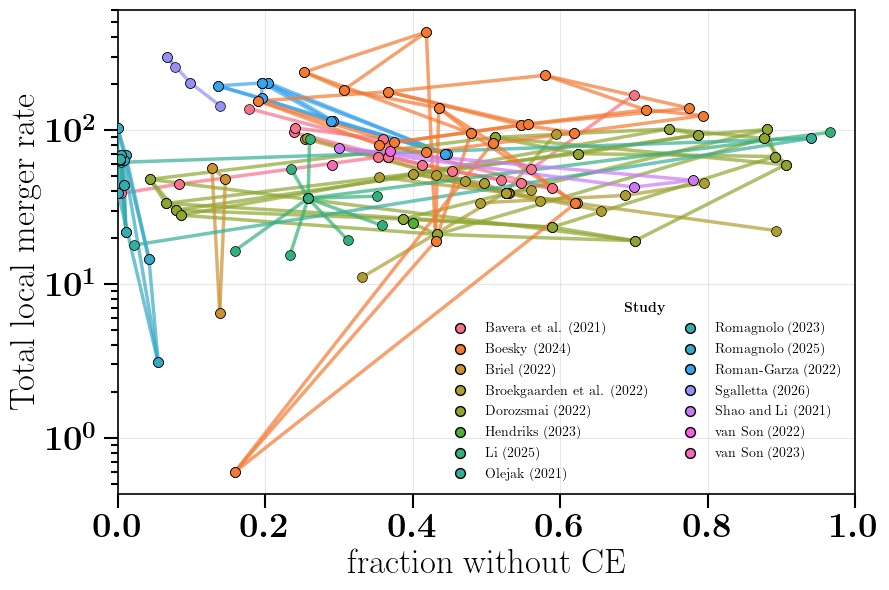

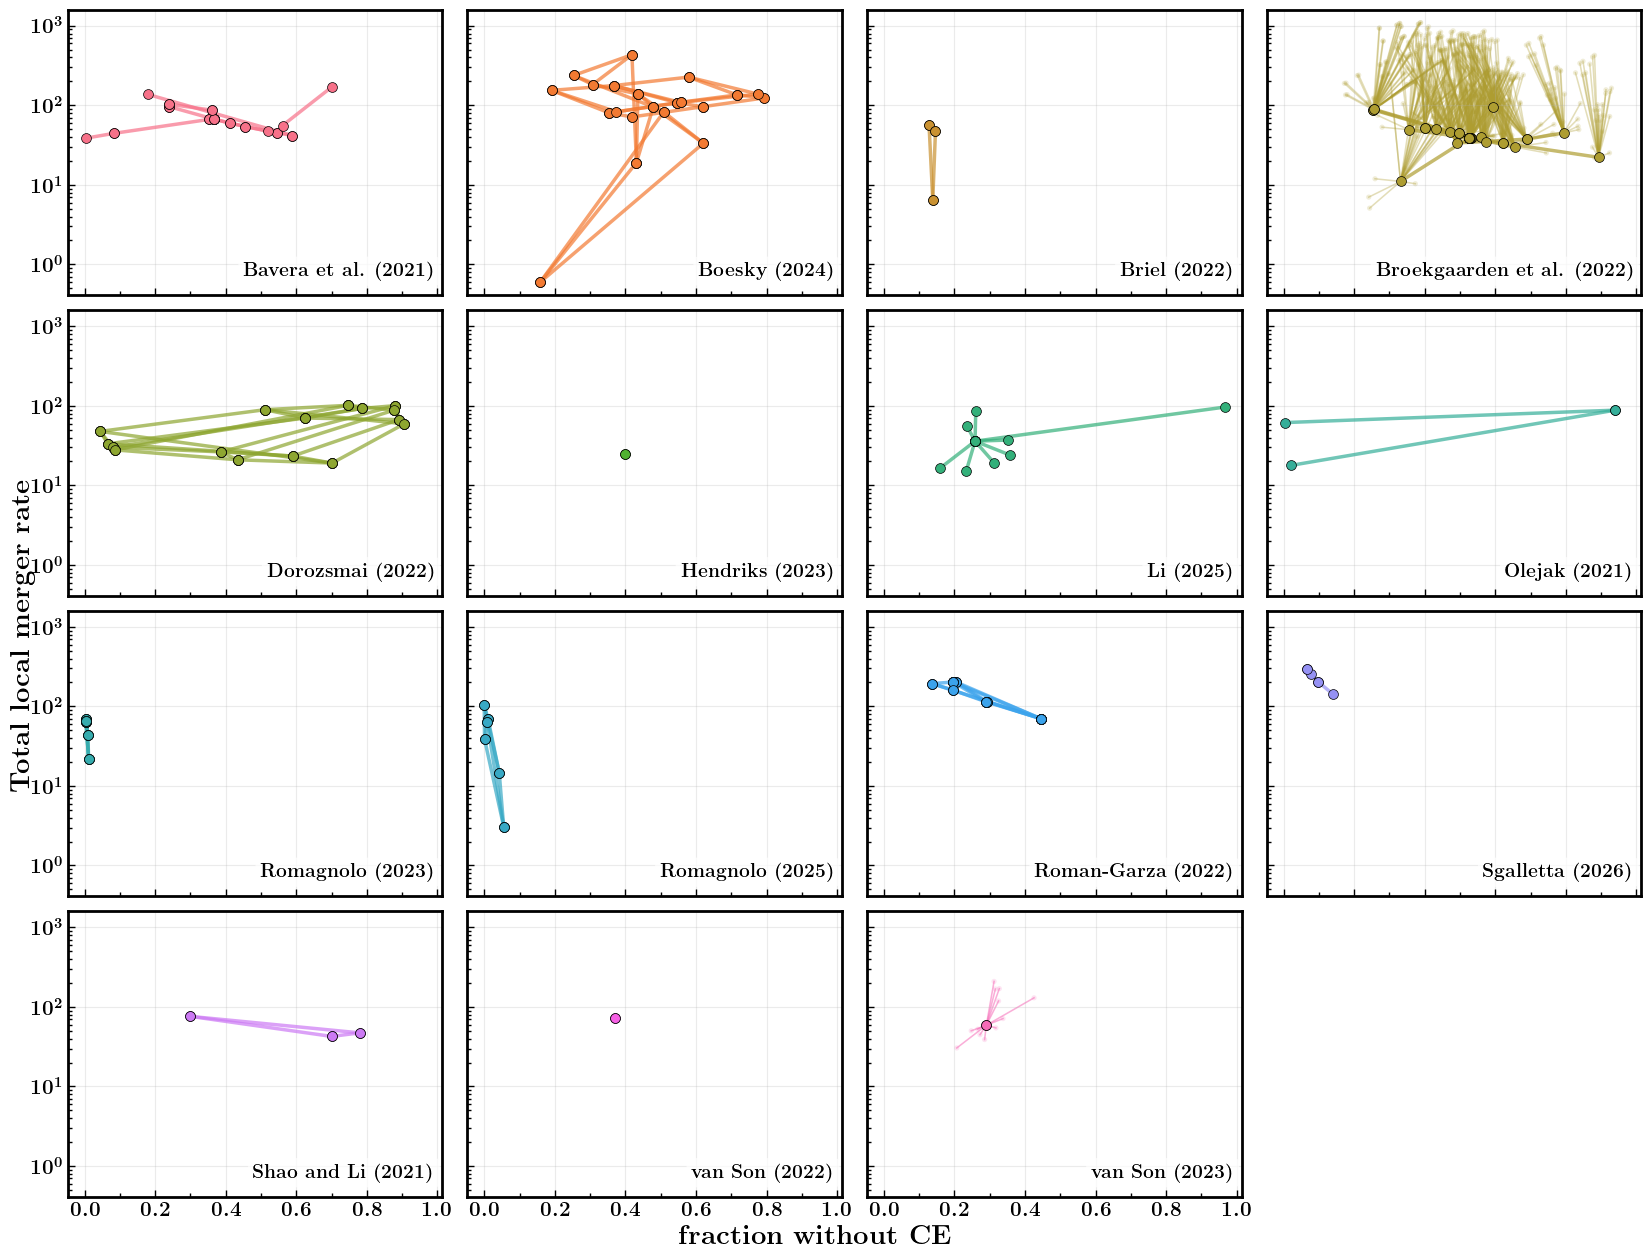


Running for BH-NS
Saving figures to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Figures
Looking for Broekgaarden SFRD file at: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/extra_fc_rates/Broekgaarden_BHNS_all_SFRD_variations_combined.csv
Exists? True
Loaded Broekgaarden SFRD rows: 560
Columns: ['DCOlabel', 'SFRD_variation', 'source_file', 'model_name', 'total_rate', 'without_CE_fraction', 'with_CE_fraction', 'sum_CE_fractions', 'sum_minus_one', 'fractions_sum_to_one']
Using broek_legend = 'Broekgaarden et al. (2022)'
Using vanSon_legend = 'van Son (2023) '
Using vanSon_fiducial_model = 'van Son (2023) '
Using broek_legend = 'Broekgaarden et al. (2022)'

--- plot_broekgaarden_secondary_sfrd ---
legend_for_color = 'Broekgaarden et al. (2022)'
broek_legend     = 'Broekgaarden et al. (2022)'
Broekgaarden extra points plotted: 560
Saved big plot to: /Users/floorbroek

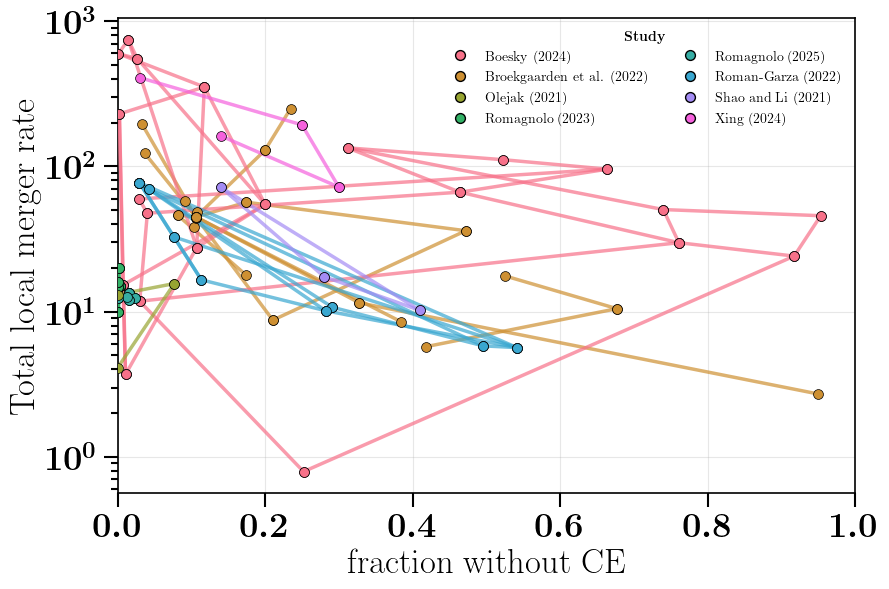

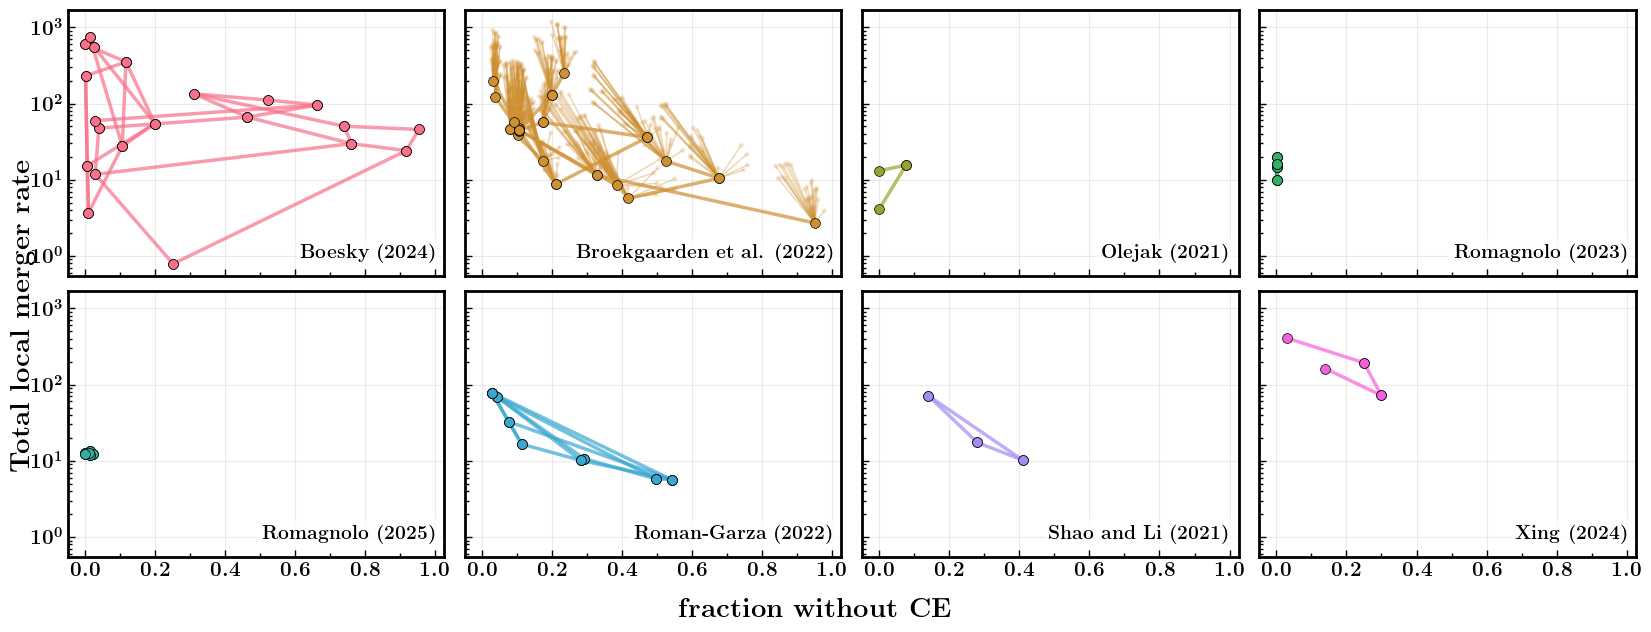


Running for NS-NS
Saving figures to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Figures
Looking for Broekgaarden SFRD file at: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/extra_fc_rates/Broekgaarden_NSNS_all_SFRD_variations_combined.csv
Exists? True
Loaded Broekgaarden SFRD rows: 560
Columns: ['DCOlabel', 'SFRD_variation', 'source_file', 'model_name', 'total_rate', 'without_CE_fraction', 'with_CE_fraction', 'sum_CE_fractions', 'sum_minus_one', 'fractions_sum_to_one']
Using broek_legend = 'Broekgaarden et al. (2022)'
Using vanSon_legend = 'van Son (2023) '
Using vanSon_fiducial_model = 'van Son (2023) '
Using broek_legend = 'Broekgaarden et al. (2022)'

--- plot_broekgaarden_secondary_sfrd ---
legend_for_color = 'Broekgaarden et al. (2022)'
broek_legend     = 'Broekgaarden et al. (2022)'
Broekgaarden extra points plotted: 560
Saved big plot to: /Users/floorbroek

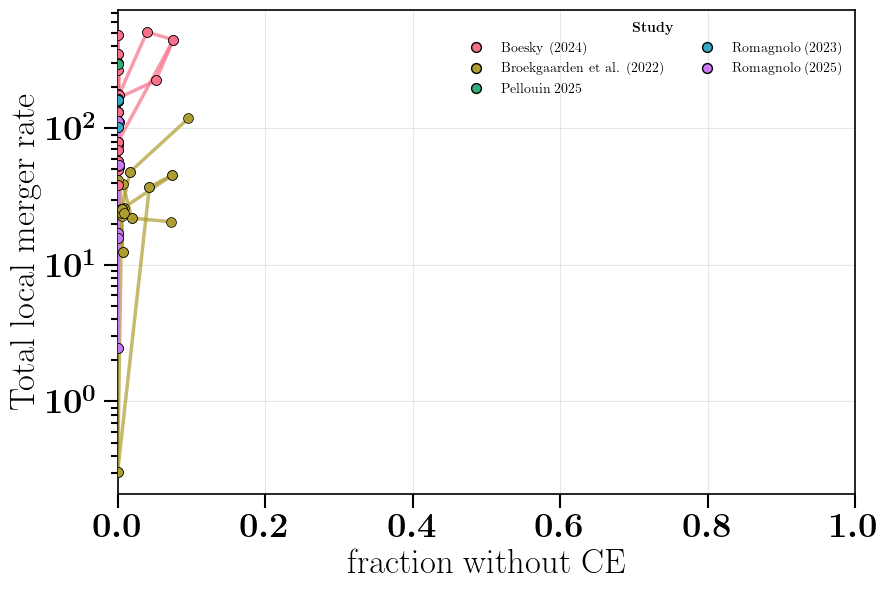

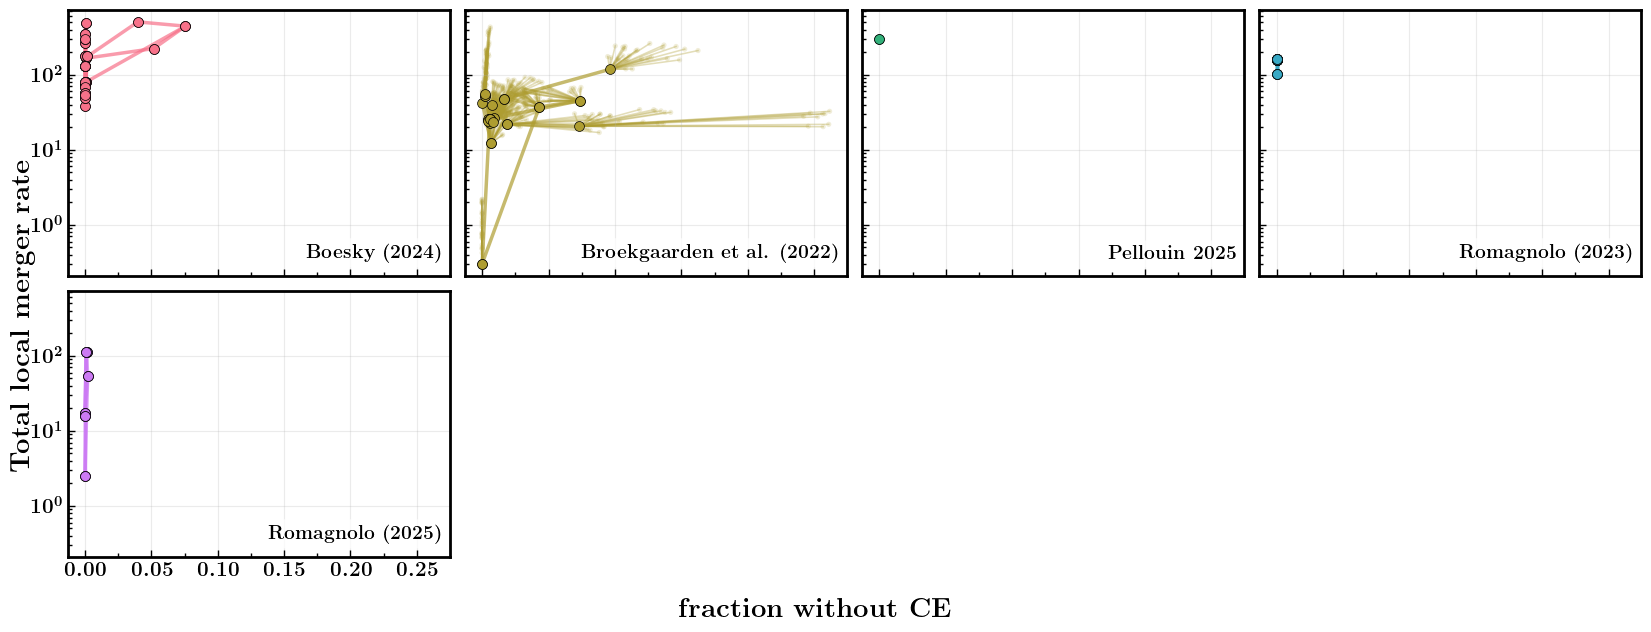

In [15]:
for dco in ["BH-BH", "BH-NS", "NS-NS"]:
    make_withoutCE_plots(dco)

In [16]:
# # # # ---- Example call ----

# # # DCOlabel="BH-BH"

# # # # fig_all, ax_all, fig_grid, axes_grid = plot_withoutCE_all_and_by_study(
# # # #     path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/",
# # # #     DCOlabel=DCOlabel,
# # # #     broek_sfrd_path="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/extra_fc_rates/Broekgaarden_BHBH_all_SFRD_variations_combined.csv",
# # # # #     broek_sfrd_path="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/extra_fc_rates/", 
# # # #     cmap_name="husl", # "rainbow", # color map
# # # #     save_big_pdf=f"{DCOlabel}_fraction_withoutCE_all.pdf",
# # # #     save_grid_pdf=f"{DCOlabel}_fraction_withoutCE_grid.pdf",
# # # #     ncols_grid=4,
# # # #     figsize_all=(9, 6),
# # # #     figsize_grid_per_panel=(4.2, 3.2),
# # # # )
# # # # plt.show()


# # # fig_all, ax_all, fig_grid, axes_grid = plot_withoutCE_all_and_by_study(
# # #     path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/",
# # #     DCOlabel="BH-BH",
# # #     broek_sfrd_path="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/extra_fc_rates/",
# # #     cmap_name="husl",
# # # )

# # # print('if extra sfrd not showing up, check labels/legends')


# # fig_all, ax_all, fig_grid, axes_grid = plot_withoutCE_all_and_by_study(
# #     path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/",
# #     DCOlabel="BH-NS",
# #     broek_sfrd_path="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/extra_fc_rates/",
# #     cmap_name="husl",
# # )

# fig_all, ax_all, fig_grid, axes_grid = plot_withoutCE_all_and_by_study(
#     path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/",
#     DCOlabel="NS-NS",
#     broek_sfrd_path="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/extra_fc_rates/",
#     cmap_name="husl",
# )

### Interactive plotting 

In [17]:
# import os
# import math
# import numpy as np
# import pandas as pd

# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

# import seaborn as sns


# def plot_withoutCE_by_study_plotly(
#     path_to_file: str,
#     DCOlabel: str = "BH-BH",
#     relation_file: Optional[str] = None,
#     rates_file: Optional[str] = None,
#     specs_file: str = "simulation_specs.csv",
#     ncols_grid: int = 4,
#     panel_w: float = 360,   # pixels per panel (width)
#     panel_h: float = 290,   # pixels per panel (height)
#     marker_size: int = 9,
#     line_width: float = 2.5,
#     line_alpha: float = 0.75,
#     palette_name: str = "husl",  # seaborn palette
# ):
#     """
#     Interactive Plotly version of the *grid by study* plot.

#     Requirements:
#       - {DCOlabel}_fcRelations.csv contains columns:
#           legend, from_modelname, to_modelname, travel_label, from_option, to_option
#       - {DCOlabel}_rates_review.csv contains:
#           model, fraction without common envelope, <fc_total_header>
#       - simulation_specs.csv contains:
#           model, label_1, label_2, label_3, label_4   (some may be empty)

#     Returns: plotly.graph_objects.Figure
#     """

#     # ---------- load relations ----------
#     if relation_file is None:
#         relation_file = f"{DCOlabel}_fcRelations.csv"
#     df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

#     # ---------- load rates ----------
#     if rates_file is None:
#         rates_file = f"{DCOlabel}_rates_review.csv"
#     df_rates = pd.read_csv(os.path.join(path_to_file, rates_file)).fillna(0.0)
#     if "model" not in df_rates.columns:
#         raise ValueError("Rates file must include a 'model' column.")
#     df_rates = df_rates.set_index("model")

#     # ---------- infer your y-column header via obtain_fc_dict (if you have it) ----------
#     # If you don't want to depend on obtain_fc_dict(), just hardcode the total-rate column name here.
#     fc_dict = obtain_fc_dict()
#     fc_total_header = fc_dict["total"]["name"]      # column name for total intrinsic rate
#     yname = fc_dict["total"]["axlabel"]

#     channels = fc_dict["CE_simple"]["channels"]
#     channel_dict = next(ch for ch in channels if ch["name"] == "fraction without common envelope")
#     xname = channel_dict["axlabel"]

#     if fc_total_header not in df_rates.columns:
#         raise ValueError(
#             f"Could not find total-rate column '{fc_total_header}' in rates file. "
#             f"Available columns: {list(df_rates.columns)}"
#         )
#     if "fraction without common envelope" not in df_rates.columns:
#         raise ValueError(
#             "Rates file must include column 'fraction without common envelope'."
#         )

        
#     # ---------- load simulation specs for point hover labels ----------
#     specs_path = os.path.join(path_to_file, specs_file)
#     if not os.path.exists(specs_path):
#         raise FileNotFoundError(f"Could not find simulation specs file: {specs_path}")

#     df_specs = pd.read_csv(specs_path)
#     if "model" not in df_specs.columns:
#         raise ValueError("simulation_specs.csv must include a 'model' column.")
#     df_specs = df_specs.set_index("model")

#     label_cols = [c for c in ["label_1", "label_2", "label_3", "label_4"] if c in df_specs.columns]

        
        
#     # --- Global axis limits (shared across all panels) ---
#     xvals = df_rates["fraction without common envelope"].astype(float).values
#     yvals = df_rates[fc_total_header].astype(float).values

#     # Remove non-positive values for log scale safety
#     yvals = yvals[yvals > 0]

#     xmin, xmax = np.nanmin(xvals), np.nanmax(xvals)
#     ymin, ymax = np.nanmin(yvals), np.nanmax(yvals)

#     # Add small padding so points are not on edges
#     xpad = 0.02 * (xmax - xmin) if xmax > xmin else 0.05
#     xmin -= xpad
#     xmax += xpad

#     # log padding in multiplicative space
#     ymin /= 1.2
#     ymax *= 1.2
        
    
    
#     def point_hover_text(model: str) -> str:
#         """Build hover text for a point using label_1..label_4 (only non-empty)."""
#         lines = [f"<b>{model}</b>"]
#         if model in df_specs.index and label_cols:
#             vals = []
#             for c in label_cols:
#                 v = df_specs.loc[model, c]
#                 if pd.notna(v):
#                     s = str(v).strip()
#                     if s and s.lower() != "nan":
#                         vals.append(s)
#             if vals:
#                 lines.append("<br>".join(vals))
#         return "<br>".join(lines)

#     def line_hover_text(row: pd.Series) -> str:
#         tl = str(row.get("travel_label", "")).strip()
#         fo = str(row.get("from_option", "")).strip()
#         to = str(row.get("to_option", "")).strip()
#         # Format exactly as requested:
#         # change: %travel_label: from %from_option to %to_option
#         return f"change: {tl}: from {fo} to {to}"

#     # ---------- studies + colors ----------
#     legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
#     n_studies = len(legends_sorted)

#     ncols = int(ncols_grid)
#     nrows = int(math.ceil(n_studies / ncols))

#     palette = sns.color_palette(palette_name, n_studies)
#     # plotly wants css-like color strings
#     def to_rgb_str(rgb_tuple):
#         r, g, b = [int(round(255 * x)) for x in rgb_tuple]
#         return f"rgb({r},{g},{b})"

#     color_map = {leg: to_rgb_str(palette[i]) for i, leg in enumerate(legends_sorted)}

#     # ---------- make subplot figure ----------
#     fig = make_subplots(
#         rows=nrows,
#         cols=ncols,
#         subplot_titles=legends_sorted,  # shows study name above each panel
#         shared_xaxes=True,
#         shared_yaxes=True,
#         horizontal_spacing=0.02,
#         vertical_spacing=0.05,
#     )

#     # ---------- add traces per study ----------
#     # We add:
#     #  - scatter points (one trace per study, all points)
#     #  - line segments (one trace per relation row, to keep hover per segment)
#     #
#     # If you have *many* rows, per-segment traces can be heavy.
#     # But it gives you exactly the per-line hover you want.
#     #
#     for i, leg in enumerate(legends_sorted):
#         row_i = i // ncols + 1
#         col_i = i % ncols + 1
        
#         # make log y-axis
#         fig.update_yaxes(type="log", row=row_i, col=col_i)

#         df_sub = df_rel[df_rel["legend"] == leg].copy()

#         # Collect unique models used in this study (for point trace)
#         models = pd.unique(df_sub[["from_modelname", "to_modelname"]].values.ravel("K"))
#         models = [m for m in models if isinstance(m, str) and m in df_rates.index]

#         xs, ys, hovers = [], [], []
#         for m in models:
#             xs.append(float(df_rates.loc[m, "fraction without common envelope"]))
#             ys.append(float(df_rates.loc[m, fc_total_header]))
#             hovers.append(point_hover_text(m))

#         # Points (one trace per panel)
#         fig.add_trace(
#             go.Scatter(
#                 x=xs,
#                 y=ys,
#                 mode="markers",
#                 marker=dict(
#                     size=marker_size,
#                     color=color_map[leg],
#                     line=dict(width=0.8, color="black"),
#                     opacity=1.0,
#                 ),
#                 hovertemplate="%{text}<extra></extra>",
#                 text=hovers,
#                 showlegend=False,
#             ),
#             row=row_i,
#             col=col_i,
#         )

#         # Lines: one trace per relation row for per-line hover text
#         for _, r in df_sub.iterrows():
#             m_from = r.get("from_modelname", None)
#             m_to = r.get("to_modelname", None)

#             if not (isinstance(m_from, str) and isinstance(m_to, str)):
#                 continue
#             if m_from not in df_rates.index or m_to not in df_rates.index:
#                 continue

#             x1 = float(df_rates.loc[m_from, "fraction without common envelope"])
#             y1 = float(df_rates.loc[m_from, fc_total_header])
#             x2 = float(df_rates.loc[m_to, "fraction without common envelope"])
#             y2 = float(df_rates.loc[m_to, fc_total_header])
            
#             # add hidden point in middle of line to make line hoovering work 
#             hover_txt = line_hover_text(r)

#             # Midpoint for log-y axis (geometric mean keeps visual straightness)
#             mx = 0.5 * (x1 + x2)
#             my = 10 ** (0.5 * (np.log10(y1) + np.log10(y2)))

#             # 1 Draw the actual straight line
#             fig.add_trace(
#                 go.Scatter(
#                     x=[x1, x2],
#                     y=[y1, y2],
#                     mode="lines",
#                     line=dict(width=line_width, color=color_map[leg]),
#                     opacity=line_alpha,
#                     hoverinfo="skip",   # prevents hover conflicts
#                     showlegend=False,
#                 ),
#                 row=row_i,
#                 col=col_i,
#             )

#             # 2 Invisible hover marker at midpoint
#             fig.add_trace(
#                 go.Scatter(
#                     x=[mx],
#                     y=[my],
#                     mode="markers",
#                     marker=dict(size=14, opacity=0.0),
#                     text=[hover_txt],
#                     hovertemplate="%{text}<extra></extra>",
#                     hoverinfo="text",
#                     showlegend=False,
#                 ),
#                 row=row_i,
#                 col=col_i,
#             )
# #             hover_txt = line_hover_text(r)

# #             # midpoint makes hover work along entire line
# #             mx = 0.5 * (x1 + x2)
# #             my = 0.5 * (y1 + y2)

# #             fig.add_trace(
# #                 go.Scatter(
# #                     x=[x1, mx, x2],
# #                     y=[y1, my, y2],
# #                     mode="lines",
# #                     line=dict(width=line_width, color=color_map[leg]),
# #                     opacity=line_alpha,
# #                     text=[hover_txt, hover_txt, hover_txt],
# #                     hovertemplate="%{text}<extra></extra>",
# #                     hoverinfo="text",
# #                     showlegend=False,
# #                 ),
# #                 row=row_i,
# #                 col=col_i,
# #             )

#         # Axes: make y log, x linear
#         fig.update_xaxes(
#             type="linear",
#             range=[xmin, xmax],
#             row=row_i,
#             col=col_i
#         )

#         fig.update_yaxes(
#             type="log",
#             range=[np.log10(ymin), np.log10(ymax)],  # IMPORTANT: log axes use log10 values
#             row=row_i,
#             col=col_i
#         )

#     # Turn off unused panels
#     for j in range(n_studies, nrows * ncols):
#         r = j // ncols + 1
#         c = j % ncols + 1
#         fig.update_xaxes(visible=False, row=r, col=c)
#         fig.update_yaxes(visible=False, row=r, col=c)

#     # Global labels + layout
#     fig.update_layout(
#         width=int(panel_w * ncols),
#         height=int(panel_h * nrows) + 60,
#         margin=dict(l=60, r=20, t=60, b=60),
#         hovermode="closest",
#         hoverdistance=40,
#     )
    

    
#     # “Global” axis titles (Plotly puts these on the overall figure)
#     fig.update_xaxes(title_text=f"<b>{xname}</b>", row=nrows, col=max(1, min(ncols, n_studies)))
#     fig.update_yaxes(title_text=f"<b>{yname}</b>", row=max(1, min(nrows, 1)), col=1)

#     # Make subplot title font a bit bigger/bold
#     fig.update_annotations(font=dict(size=14))

#     return fig


# # ---- Example call ----
# DCOlabel = "BH-BH"

# fig = plot_withoutCE_by_study_plotly(
#     path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/",
#     DCOlabel=DCOlabel,
#     ncols_grid=4,
#     palette_name="husl",
#     specs_file="simulation_specs.csv",
# )

# fig.show()

## Interactive per study plot

In [18]:
# --- Required imports (add these at the top of your notebook/script) ---
import os
import math
import re
import numpy as np
import pandas as pd

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import seaborn as sns

from typing import Optional


def plot_withoutCE_by_study_plotly(
    path_to_file: str,
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols_grid: int = 4,
    panel_w: float = 360,   # pixels per panel (width)
    panel_h: float = 290,   # pixels per panel (height)
    marker_size: int = 9,
    line_width: float = 2.5,
    line_alpha: float = 0.75,
    palette_name: str = "husl",  # seaborn palette
):
    """
    Plotly (non-FigureWidget) version of the *grid by study* plot with:
      - log10 y-axis
      - shared x/y limits across panels
      - hover text on points
      - hover text on lines via invisible midpoint markers (no visual kinks)
      - dropdown toggle by "parameter families" inferred from travel_label
      - HTML export via fig.write_html(...)

    Returns:
      - plotly.graph_objects.Figure
    """

    # ---------- helper: parameter family inferred from travel_label ----------
    def parameter_family_from_travel_label(travel_label: str) -> str:
        s = str(travel_label).strip()
        if (not s) or (s.lower() == "nan"):
            return "unknown"

        # remove LaTeX $...$ delimiters
        s = s.replace("$", "").strip()

        # remove arrow tokens
        s = s.replace(r"\uparrow", "").replace(r"\downarrow", "")
        s = s.replace("↑", "").replace("↓", "")

        # normalize spaces
        s = re.sub(r"\s+", " ", s).strip()
        return s if s else "unknown"

    # ---------- load relations ----------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # ---------- load rates ----------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"
    df_rates = pd.read_csv(os.path.join(path_to_file, rates_file)).fillna(0.0)
    if "model" not in df_rates.columns:
        raise ValueError("Rates file must include a 'model' column.")
    df_rates = df_rates.set_index("model")
    
    
    # ---------- load extra van Son (2023) S(Z,z) variations ----------
    extra_sfrd_file = os.path.join(path_to_file, "extra_fc_rates", "vanSon2023_sfrd.csv")
    if os.path.exists(extra_sfrd_file):
        df_rates_vanson_sfrd = pd.read_csv(extra_sfrd_file).fillna(0.0).set_index("model")
    else:
        df_rates_vanson_sfrd = None

    vanSon_legend = "van Son (2023) "
    vanSon_fiducial_model = "van Son (2023) "

    # ---------- infer y-column header via obtain_fc_dict ----------
    fc_dict = obtain_fc_dict()
    fc_total_header = fc_dict["total"]["name"]      # column name for total intrinsic rate
    yname = fc_dict["total"]["axlabel"]

    channels = fc_dict["CE_simple"]["channels"]
    channel_dict = next(ch for ch in channels if ch["name"] == "fraction without common envelope")
    xname = channel_dict["axlabel"]

    if fc_total_header not in df_rates.columns:
        raise ValueError(
            f"Could not find total-rate column '{fc_total_header}' in rates file. "
            f"Available columns: {list(df_rates.columns)}"
        )
    if "fraction without common envelope" not in df_rates.columns:
        raise ValueError("Rates file must include column 'fraction without common envelope'.")

    # ---------- load simulation specs for point hover labels ----------
    specs_path = os.path.join(path_to_file, specs_file)
    if not os.path.exists(specs_path):
        raise FileNotFoundError(f"Could not find simulation specs file: {specs_path}")

    df_specs = pd.read_csv(specs_path)
    if "model" not in df_specs.columns:
        raise ValueError("simulation_specs.csv must include a 'model' column.")
    df_specs = df_specs.set_index("model")

    label_cols = [c for c in ["label_1", "label_2", "label_3", "label_4"] if c in df_specs.columns]

    # ---------- global axis limits (shared across all panels) ----------
    xvals = df_rates["fraction without common envelope"].astype(float).values
    yvals = df_rates[fc_total_header].astype(float).values

    # Remove non-positive values for log scale safety
    yvals_pos = yvals[yvals > 0]
    if len(yvals_pos) == 0:
        raise ValueError("All y-values are non-positive; cannot use log axis.")

    xmin, xmax = np.nanmin(xvals), np.nanmax(xvals)
    ymin, ymax = np.nanmin(yvals_pos), np.nanmax(yvals_pos)

    # Add small padding so points are not on edges
    xpad = 0.02 * (xmax - xmin) if xmax > xmin else 0.05
    xmin -= xpad
    xmax += xpad

    # log padding in multiplicative space
    ymin /= 1.2
    ymax *= 1.2

    def point_hover_text(model: str) -> str:
        """Build hover text for a point using label_1..label_4 (only non-empty)."""
        lines = [f"<b>{model}</b>"]
        if model in df_specs.index and label_cols:
            vals = []
            for c in label_cols:
                v = df_specs.loc[model, c]
                if pd.notna(v):
                    s = str(v).strip()
                    if s and s.lower() != "nan":
                        vals.append(s)
            if vals:
                lines.append("<br>".join(vals))
        return "<br>".join(lines)

    def line_hover_text(row: pd.Series) -> str:
        tl = str(row.get("travel_label", "")).strip()
        fo = str(row.get("from_option", "")).strip()
        to = str(row.get("to_option", "")).strip()
        return f"change: {tl}: from {fo} to {to}"
    
    
    def add_vanSon2023_sfrd_overlay(fig, leg, row_i, col_i, color_map):
        """
        Add extra van Son (2023) S(Z,z) variation points/lines to the van Son panel only.
        """
        if df_rates_vanson_sfrd is None:
            return
        if str(leg).strip() != str(vanSon_legend).strip():
            return
        if vanSon_fiducial_model not in df_rates.index:
            return

        x_fid = float(df_rates.loc[vanSon_fiducial_model, "fraction without common envelope"])
        y_fid = float(df_rates.loc[vanSon_fiducial_model, fc_total_header])

        if y_fid <= 0:
            return

        this_color = color_map[leg]

        for model in df_rates_vanson_sfrd.index:
            # skip duplicate fiducial row in extra file, if present
            if "fiducial" in str(model).strip().lower():
                continue

            x = float(df_rates_vanson_sfrd.loc[model, "fraction without common envelope"])
            y = float(df_rates_vanson_sfrd.loc[model, fc_total_header])

            if y <= 0:
                continue

            hover_txt = (
                f"<b>{leg.strip()}</b><br>"
                f"S(Z,z) variation<br>"
                f"{model}<br>"
                f"connected to fiducial"
            )

            # midpoint for hover on log-y axis
            mx = 0.5 * (x_fid + x)
            my = 10 ** (0.5 * (np.log10(y_fid) + np.log10(y)))

            # background line
            fig.add_trace(
                go.Scatter(
                    x=[x_fid, x],
                    y=[y_fid, y],
                    mode="lines",
                    line=dict(width=line_width * 0.9, color=this_color),
                    opacity=0.35,
                    hoverinfo="skip",
                    showlegend=False,
                    meta=dict(kind="line", family="S(Z,z) variations", study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # visible point
            fig.add_trace(
                go.Scatter(
                    x=[x],
                    y=[y],
                    mode="markers",
                    marker=dict(
                        size=max(6, marker_size - 1),
                        color=this_color,
                        line=dict(width=0.0, color=this_color),
                        opacity=0.75,
                    ),
                    hovertemplate=f"{hover_txt}<extra></extra>",
                    showlegend=False,
                    meta=dict(kind="point", study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # invisible hover marker for the connecting line
            fig.add_trace(
                go.Scatter(
                    x=[mx],
                    y=[my],
                    mode="markers",
                    marker=dict(size=16, opacity=0.0),
                    text=[hover_txt],
                    hovertemplate="%{text}<extra></extra>",
                    hoverinfo="text",
                    showlegend=False,
                    meta=dict(kind="hover", family="S(Z,z) variations", study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

    # ---------- studies + colors ----------
    legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
    n_studies = len(legends_sorted)

    ncols = int(ncols_grid)
    nrows = int(math.ceil(n_studies / ncols))

    palette = sns.color_palette(palette_name, n_studies)

    def to_rgb_str(rgb_tuple):
        r, g, b = [int(round(255 * x)) for x in rgb_tuple]
        return f"rgb({r},{g},{b})"

    color_map = {leg: to_rgb_str(palette[i]) for i, leg in enumerate(legends_sorted)}

    # ---------- make subplot figure ----------
    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=legends_sorted,
        shared_xaxes=True,
        shared_yaxes=True,
        horizontal_spacing=0.02,
        vertical_spacing=0.05,
    )

    # ---------- add traces per study ----------
    for i, leg in enumerate(legends_sorted):
        row_i = i // ncols + 1
        col_i = i % ncols + 1

        df_sub = df_rel[df_rel["legend"] == leg].copy()

        # Collect unique models used in this study (for point trace)
        models = pd.unique(df_sub[["from_modelname", "to_modelname"]].values.ravel("K"))
        models = [m for m in models if isinstance(m, str) and m in df_rates.index]

        xs, ys, hovers = [], [], []
        for m in models:
            xs.append(float(df_rates.loc[m, "fraction without common envelope"]))
            ys.append(float(df_rates.loc[m, fc_total_header]))
            hovers.append(point_hover_text(m))

        # Points (one trace per panel)
        fig.add_trace(
            go.Scatter(
                x=xs,
                y=ys,
                mode="markers",
                marker=dict(
                    size=marker_size,
                    color=color_map[leg],
                    line=dict(width=0.8, color="black"),
                    opacity=1.0,
                ),
                hovertemplate="%{text}<extra></extra>",
                text=hovers,
                showlegend=False,
                meta=dict(kind="point", study=str(leg)),
            ),
            row=row_i,
            col=col_i,
        )

        # Lines + invisible hover markers (hover text without FigureWidget callbacks)
        for _, rr in df_sub.iterrows():
            m_from = rr.get("from_modelname", None)
            m_to = rr.get("to_modelname", None)

            if not (isinstance(m_from, str) and isinstance(m_to, str)):
                continue
            if m_from not in df_rates.index or m_to not in df_rates.index:
                continue

            x1 = float(df_rates.loc[m_from, "fraction without common envelope"])
            y1 = float(df_rates.loc[m_from, fc_total_header])
            x2 = float(df_rates.loc[m_to, "fraction without common envelope"])
            y2 = float(df_rates.loc[m_to, fc_total_header])

            # skip non-positive y (log safety)
            if y1 <= 0 or y2 <= 0:
                continue

            hover_txt = line_hover_text(rr)
            family = parameter_family_from_travel_label(rr.get("travel_label", ""))

            # Midpoint for log-y axis: geometric mean keeps straightness
            mx = 0.5 * (x1 + x2)
            my = 10 ** (0.5 * (np.log10(y1) + np.log10(y2)))

            # 1) Draw straight line (no hover)
            fig.add_trace(
                go.Scatter(
                    x=[x1, x2],
                    y=[y1, y2],
                    mode="lines",
                    line=dict(width=line_width, color=color_map[leg]),
                    opacity=line_alpha,
                    hoverinfo="skip",
                    showlegend=False,
                    meta=dict(kind="line", family=family, study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )

            # 2) Invisible hover marker at midpoint (drives the hover text)
            fig.add_trace(
                go.Scatter(
                    x=[mx],
                    y=[my],
                    mode="markers",
                    marker=dict(size=16, opacity=0.0),
                    text=[hover_txt],
                    hovertemplate="%{text}<extra></extra>",
                    hoverinfo="text",
                    showlegend=False,
                    meta=dict(kind="hover", family=family, study=str(leg)),
                ),
                row=row_i,
                col=col_i,
            )
            
        # Add van Son (2023) extra S(Z,z) variations in the van Son panel
        add_vanSon2023_sfrd_overlay(fig, leg, row_i, col_i, color_map)

        # Axes per panel
        fig.update_xaxes(type="linear", range=[xmin, xmax], row=row_i, col=col_i)
        fig.update_yaxes(type="log", range=[np.log10(ymin), np.log10(ymax)], row=row_i, col=col_i)

    # Turn off unused panels
    for j in range(n_studies, nrows * ncols):
        r = j // ncols + 1
        c = j % ncols + 1
        fig.update_xaxes(visible=False, row=r, col=c)
        fig.update_yaxes(visible=False, row=r, col=c)

    # Layout
    fig.update_layout(
        width=int(panel_w * ncols),
        height=int(panel_h * nrows) + 80,
        margin=dict(l=70, r=160, t=70, b=70),
        hovermode="closest",
        hoverdistance=40,
    )

    # Global axis titles
    fig.update_xaxes(title_text=f"<b>{xname}</b>", row=nrows, col=max(1, min(ncols, n_studies)))
    fig.update_yaxes(title_text=f"<b>{yname}</b>", row=1, col=1)

    # Subplot title styling
    fig.update_annotations(font=dict(size=14))

    # ---------- Dropdown: Toggle parameter families ----------
    families = set()
    for tr in fig.data:
        meta = getattr(tr, "meta", None) or {}
        if meta.get("kind") in ("line", "hover"):
            families.add(meta.get("family", "unknown"))
    families = sorted(families)

    def visibility_for_family(fam: Optional[str]):
        """fam=None shows all; else show only traces for that family. Points always visible."""
        vis = []
        for tr in fig.data:
            meta = getattr(tr, "meta", None) or {}
            kind = meta.get("kind", None)
            if kind == "point" or kind is None:
                vis.append(True)
            elif kind in ("line", "hover"):
                vis.append(True if fam is None else (meta.get("family") == fam))
            else:
                vis.append(True)
        return vis

    buttons = [dict(label="All families", method="update", args=[{"visible": visibility_for_family(None)}])]
    for fam in families:
        buttons.append(dict(label=str(fam), method="update", args=[{"visible": visibility_for_family(fam)}]))

    fig.update_layout(
        updatemenus=[
            dict(
                type="dropdown",
                x=1.02,
                y=1.02,
                xanchor="left",
                yanchor="top",
                buttons=buttons,
            )
        ]
    )

    return fig


# ---- Example usage ----
DCOlabel = "BH-BH"

fig = plot_withoutCE_by_study_plotly(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/",
    DCOlabel="BH-BH",
    ncols_grid=4,
    palette_name="husl",
    specs_file="simulation_specs.csv",
)

out = "BH-BH_by_study_interactive.html"
fig.write_html(out, include_plotlyjs=True, full_html=True)
print("Wrote:", out)

# In a notebook, this will open a new browser tab (no nbformat needed)
import webbrowser, os
webbrowser.open("file://" + os.path.abspath(out))

Wrote: BH-BH_by_study_interactive.html


True

### Parameter variations analysis 


In [19]:
import os
import math
import re
from typing import Optional, Sequence, Dict, Any, List, Set

import numpy as np
import pandas as pd

import plotly.graph_objects as go
from plotly.subplots import make_subplots

import seaborn as sns


def plot_withoutCE_fraction_vs_parameters_plotly(
    path_to_file: str,
    parameters: Sequence[str],
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols: int = 3,
    panel_w: int = 520,
    panel_h: int = 320,
    marker_size: int = 8,
    line_width: float = 3.0,
    line_alpha: float = 0.85,
    palette_name: str = "husl",
    show_study_legend: bool = True,  # <- legend requested
    category_orders: Optional[Dict[str, List[str]]] = None,
    alpha_logx: bool = True,          # <- alpha x-axis log scale
    # optional: add/override aliases for family matching
    family_aliases: Optional[Dict[str, List[str]]] = None,
):
    """
    Multi-panel figure: each panel is one parameter family (e.g. beta, alpha, remnant mass prescription).
    y-axis: fraction without common envelope
    x-axis: parameter value (numeric or categorical)

    Improvements vs prior version:
      - alpha x-axis can be log-scale
      - more robust matching for families (substring + token match + aliases)
      - study legend shown once, without duplicates
      - no title
    """

    # ---------- helpers ----------
    def parameter_family_from_travel_label(travel_label: str) -> str:
        s = str(travel_label).strip()
        if (not s) or (s.lower() == "nan"):
            return "unknown"
        s = s.replace("$", "").strip()
        s = s.replace(r"\uparrow", "").replace(r"\downarrow", "")
        s = s.replace("↑", "").replace("↓", "")
        s = re.sub(r"\s+", " ", s).strip()
        return s if s else "unknown"

    def simplify_text(s: str) -> str:
        """Lowercase, strip LaTeX-ish chars, collapse whitespace, remove punctuation-ish."""
        t = str(s).lower()
        t = t.replace("$", "")
        # keep backslashes for latex greek, then normalize below
        t = re.sub(r"\s+", " ", t).strip()
        # remove most punctuation
        t = re.sub(r"[^\w\s\\]", " ", t)
        t = re.sub(r"\s+", " ", t).strip()
        return t

    def normalize_family(s: str) -> str:
        """Normalize to stable keys like alpha, beta, remnant mass prescription."""
        t = simplify_text(s)

        # Map common greek representations to words
        greek_map = {
            r"\alpha": "alpha",
            "α": "alpha",
            "alpha": "alpha",
            r"\beta": "beta",
            "β": "beta",
            "beta": "beta",
            r"\gamma": "gamma",
            "γ": "gamma",
            "gamma": "gamma",
        }
        for k, v in greek_map.items():
            if k in t:
                return v

        # Specific common families (normalize variants)
        if "remnant" in t and ("prescription" in t or "mass" in t):
            return "remnant mass prescription"
        if ("supernova" in t or "sn" in t) and "engine" in t:
            return "supernova engine"
        if "common envelope" in t or "ce" in t:
            return "common envelope"

        return t  # fallback: simplified raw

    def normalize_option(o: Any) -> str:
        if o is None or (isinstance(o, float) and np.isnan(o)):
            return ""
        return str(o).strip().replace("$", "").strip()

    def try_float(x: str) -> Optional[float]:
        try:
            return float(x)
        except Exception:
            return None

    def point_hover_text(model: str, df_specs: pd.DataFrame, label_cols: List[str]) -> str:
        lines = [f"<b>{model}</b>"]
        if (model in df_specs.index) and label_cols:
            vals = []
            for c in label_cols:
                v = df_specs.loc[model, c]
                if pd.notna(v):
                    vv = str(v).strip()
                    if vv and vv.lower() != "nan":
                        vals.append(vv)
            if vals:
                lines.append("<br>".join(vals))
        return "<br>".join(lines)

    def segment_hover_text(row: pd.Series) -> str:
        fam = parameter_family_from_travel_label(row.get("travel_label", ""))
        fo = normalize_option(row.get("from_option", ""))
        to = normalize_option(row.get("to_option", ""))
        m1 = row.get("from_modelname", "")
        m2 = row.get("to_modelname", "")
        leg = row.get("legend", "")
        return (
            f"<b>{leg}</b><br>"
            f"family: {fam}<br>"
            f"{m1} ({fo}) → {m2} ({to})"
        )

    # ---------- default aliases (extendable) ----------
    base_aliases = {
        "alpha": ["alpha", r"\alpha", "α", "ce alpha", "common envelope efficiency", "alpha_ce", "alpha ce"],
        "beta": ["beta", r"\beta", "β", "mass transfer efficiency", "mt efficiency", "accretion efficiency"],
        "supernova engine": ["supernova engine", "sn engine", "engine", "delayed", "rapid"],
        "remnant mass prescription": [
            "remnant mass prescription", "remnant prescription", "remnant mass model",
            "compact remnant prescription", "fryer", "delayed", "rapid"
        ],
    }
    if family_aliases:
        # merge user overrides/additions
        for k, v in family_aliases.items():
            nk = normalize_family(k)
            base_aliases.setdefault(nk, [])
            base_aliases[nk].extend(v)

    # ---------- load relations ----------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    required_rel_cols = {"legend", "from_modelname", "to_modelname", "travel_label", "from_option", "to_option"}
    missing = required_rel_cols - set(df_rel.columns)
    if missing:
        raise ValueError(f"Relations file missing columns: {sorted(missing)}")

    # ---------- load rates ----------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"
    df_rates = pd.read_csv(os.path.join(path_to_file, rates_file))
    if "model" not in df_rates.columns:
        raise ValueError("Rates file must include a 'model' column.")
    if "fraction without common envelope" not in df_rates.columns:
        raise ValueError("Rates file must include column 'fraction without common envelope'.")
    df_rates = df_rates.set_index("model")

    # ---------- load specs (optional) ----------
    specs_path = os.path.join(path_to_file, specs_file)
    if os.path.exists(specs_path):
        df_specs = pd.read_csv(specs_path)
        if "model" in df_specs.columns:
            df_specs = df_specs.set_index("model")
        else:
            df_specs = pd.DataFrame().set_index(pd.Index([], name="model"))
    else:
        df_specs = pd.DataFrame().set_index(pd.Index([], name="model"))
    label_cols = [c for c in ["label_1", "label_2", "label_3", "label_4"] if c in df_specs.columns]

    # ---------- annotate families in relations ----------
    df_rel = df_rel.copy()
    df_rel["family_raw"] = df_rel["travel_label"].apply(parameter_family_from_travel_label)
    df_rel["family_simpl"] = df_rel["family_raw"].apply(simplify_text)
    df_rel["family_norm"] = df_rel["family_raw"].apply(normalize_family)

    # ---------- robust family filter ----------
    def select_rows_for_parameter(df: pd.DataFrame, param_user: str) -> pd.DataFrame:
        """
        Match strategy:
          1) exact normalized key match: family_norm == param_norm
          2) substring match of simplified strings (param in family_raw or vice versa)
          3) alias token match: any alias substring appears in family_simpl
        """
        p_simpl = simplify_text(param_user)
        p_norm = normalize_family(param_user)

        m1 = df["family_norm"] == p_norm

        # substring fallback
        m2 = df["family_simpl"].str.contains(re.escape(p_simpl), na=False) if p_simpl else False

        # alias fallback
        aliases = [simplify_text(a) for a in base_aliases.get(p_norm, []) if a]
        if aliases:
            pat = "|".join(re.escape(a) for a in aliases if a)
            m3 = df["family_simpl"].str.contains(pat, na=False)
        else:
            m3 = False

        return df[m1 | m2 | m3].copy()

    # ---------- panel setup ----------
    n_panels = len(parameters)
    ncols = max(1, int(ncols))
    nrows = int(math.ceil(n_panels / ncols))

    fig = make_subplots(
        rows=nrows,
        cols=ncols,
        subplot_titles=[str(p) for p in parameters],
        horizontal_spacing=0.06,
        vertical_spacing=0.12,
        shared_yaxes=True,
    )

    # ---------- color map by study ----------
    legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
    palette = sns.color_palette(palette_name, max(1, len(legends_sorted)))

    def to_rgb_str(rgb_tuple):
        r, g, b = [int(round(255 * x)) for x in rgb_tuple]
        return f"rgb({r},{g},{b})"

    color_map = {leg: to_rgb_str(palette[i % len(palette)]) for i, leg in enumerate(legends_sorted)}

    if category_orders is None:
        category_orders = {}

    # legend: ensure each study appears only once in legend
    legend_added: Set[str] = set()

    # ---------- build each panel ----------
    for k, p_user in enumerate(parameters):
        r = (k // ncols) + 1
        c = (k % ncols) + 1

        dfp = select_rows_for_parameter(df_rel, str(p_user))

        if dfp.empty:
            fig.add_annotation(
                x=0.5, y=0.5, xref=f"x{k+1} domain", yref=f"y{k+1} domain",
                text="No relations found for this parameter family",
                showarrow=False, font=dict(size=12),
            )
            fig.update_yaxes(range=[0, 1], row=r, col=c)
            continue

        # numeric vs categorical x
        opt_from = [normalize_option(x) for x in dfp["from_option"].tolist()]
        opt_to = [normalize_option(x) for x in dfp["to_option"].tolist()]
        opts = [o for o in (opt_from + opt_to) if o != ""]
        floats = [try_float(o) for o in opts]
        is_numeric = (len(opts) > 0) and all(v is not None for v in floats)

        # category order (if needed)
        order = None
        if str(p_user) in category_orders:
            order = [str(x) for x in category_orders[str(p_user)]]
        else:
            # sensible default for delayed/rapid if present
            low_opts = [o.lower() for o in opts]
            if (not is_numeric) and ("delayed" in low_opts or "rapid" in low_opts):
                order = ["delayed", "rapid"]

        if order is None and (not is_numeric):
            seen = []
            for o in opts:
                if o not in seen:
                    seen.append(o)
            order = seen

        # traces per study
        for leg in sorted(dfp["legend"].dropna().unique().tolist()):
            dfl = dfp[dfp["legend"] == leg]

            for _, rr in dfl.iterrows():
                m1 = rr["from_modelname"]
                m2 = rr["to_modelname"]
                if (m1 not in df_rates.index) or (m2 not in df_rates.index):
                    continue

                y1 = float(df_rates.loc[m1, "fraction without common envelope"])
                y2 = float(df_rates.loc[m2, "fraction without common envelope"])

                xo1 = normalize_option(rr["from_option"])
                xo2 = normalize_option(rr["to_option"])
                if xo1 == "" or xo2 == "":
                    continue

                if is_numeric:
                    x1 = float(xo1)
                    x2 = float(xo2)
                else:
                    x1 = xo1
                    x2 = xo2

                hover = segment_hover_text(rr) + "<br><br>" + point_hover_text(m1, df_specs, label_cols)

                # show legend entry only once globally
                showleg = show_study_legend and (leg not in legend_added)
                if showleg:
                    legend_added.add(leg)

                fig.add_trace(
                    go.Scatter(
                        x=[x1, x2],
                        y=[y1, y2],
                        mode="lines+markers",
                        line=dict(width=line_width, color=color_map.get(leg, "gray")),
                        marker=dict(
                            size=marker_size,
                            color=color_map.get(leg, "gray"),
                            line=dict(width=0.7, color="black"),
                        ),
                        opacity=line_alpha,
                        name=str(leg),
                        showlegend=showleg,
                        hovertemplate=hover + "<extra></extra>",
                    ),
                    row=r, col=c
                )

        # y-axis fixed
        fig.update_yaxes(
            range=[0, 1],
            title_text="<b>without-CE fraction</b>" if (r == 1 and c == 1) else None,
            row=r, col=c
        )

        # x-axis formatting: alpha log scale if requested and numeric
        p_norm = normalize_family(str(p_user))
        if is_numeric:
            if alpha_logx and (p_norm == "alpha"):
                fig.update_xaxes(
                    type="log",
                    title_text=f"<b>{p_user}</b>" if r == nrows else None,
                    row=r, col=c
                )
            else:
                fig.update_xaxes(
                    type="linear",
                    title_text=f"<b>{p_user}</b>" if r == nrows else None,
                    row=r, col=c
                )
        else:
            fig.update_xaxes(
                type="category",
                categoryorder="array",
                categoryarray=order,
                title_text=f"<b>{p_user}</b>" if r == nrows else None,
                row=r, col=c
            )

    # hide unused panels
    for j in range(n_panels, nrows * ncols):
        rr = j // ncols + 1
        cc = j % ncols + 1
        fig.update_xaxes(visible=False, row=rr, col=cc)
        fig.update_yaxes(visible=False, row=rr, col=cc)

    # layout: explicitly no title
    fig.update_layout(
        title=None,
        width=int(panel_w * min(ncols, n_panels)),
        height=int(panel_h * nrows) + 80,
        margin=dict(l=80, r=40, t=70, b=70),
        hovermode="closest",
        legend=dict(
            title="<b>Study</b>",
            orientation="v",
            yanchor="top",
            y=1.0,
            xanchor="left",
            x=1.02,  # put legend just outside to the right
        ),
    )
    fig.update_annotations(font=dict(size=14))

    return fig


# ---------------------------
# Example usage
# ---------------------------
path = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/"
DCOlabel = "BH-BH"

fig = plot_withoutCE_fraction_vs_parameters_plotly(
    path_to_file=path,
    parameters=[r"$\beta$", r"$\alpha$", "remnant mass prescription"],
    DCOlabel=DCOlabel,
    ncols=3,
    palette_name="husl",
    show_study_legend=True,
    category_orders={"remnant mass prescription": ["delayed", "rapid"]},
    alpha_logx=True,
)

# save the figure (better to maybe make a seperate static image )
fig.write_html(
    f"{DCOlabel}_withoutCE_fraction_vs_parameters.html",
    include_plotlyjs=True,
    full_html=True,
)
# fig.show()
# fig.write_html(f"{DCOlabel}_withoutCE_fraction_vs_parameters.html", include_plotlyjs=True, full_html=True)

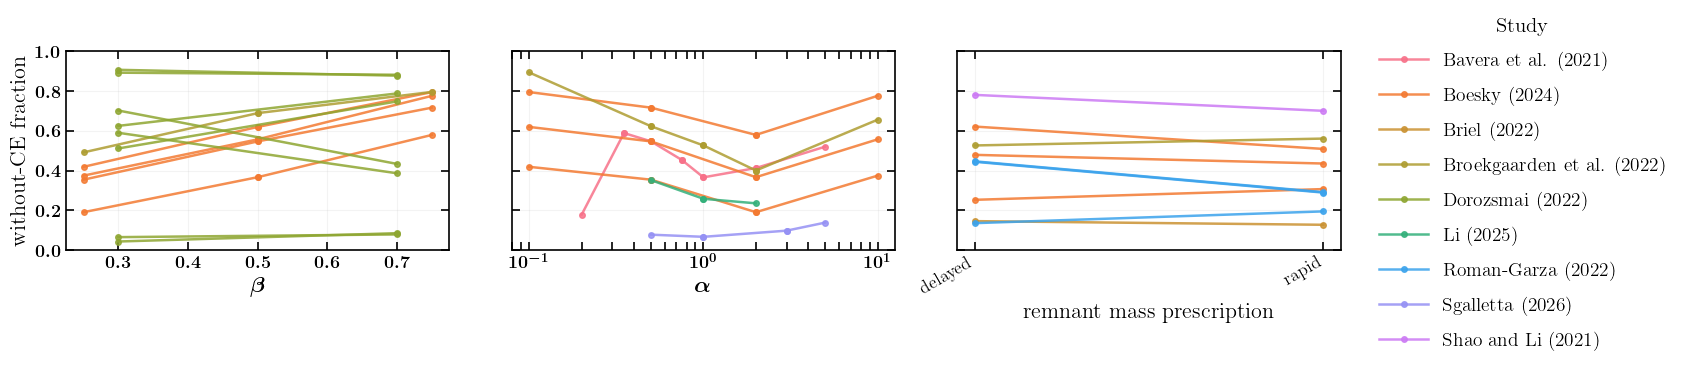

In [20]:
import os
import math
import re
from typing import Optional, Sequence, Dict, Any, List, Set, Tuple

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 14,
    "legend.title_fontsize": 15,
})


def plot_withoutCE_fraction_vs_parameters_static(
    path_to_file: str,
    parameters: Sequence[str],
    DCOlabel: str = "BH-BH",
    relation_file: Optional[str] = None,
    rates_file: Optional[str] = None,
    specs_file: str = "simulation_specs.csv",
    ncols: int = 3,
    panel_w_in: float = 5.2,   # inches per panel width
    panel_h_in: float = 3.2,   # inches per panel height
    marker_size: float = 4.0,  # matplotlib markersize (points)
    line_width: float = 1.8,
    line_alpha: float = 0.85,
    palette_name: str = "husl",
    show_study_legend: bool = True,
    category_orders: Optional[Dict[str, List[str]]] = None,
    alpha_logx: bool = True,
    family_aliases: Optional[Dict[str, List[str]]] = None,
    ylim: Tuple[float, float] = (0.0, 1.0),
):
    """
    Static Matplotlib version (no Plotly/Kaleido/nbformat/ipywidgets).

    Each panel corresponds to one parameter family in `parameters`.
    y-axis: fraction without common envelope (0..1)
    x-axis: parameter value (numeric or categorical)
    """

    # ---------------- helpers ----------------
    def parameter_family_from_travel_label(travel_label: str) -> str:
        s = str(travel_label).strip()
        if (not s) or (s.lower() == "nan"):
            return "unknown"
        s = s.replace("$", "").strip()
        s = s.replace(r"\uparrow", "").replace(r"\downarrow", "")
        s = s.replace("↑", "").replace("↓", "")
        s = re.sub(r"\s+", " ", s).strip()
        return s if s else "unknown"

    def simplify_text(s: str) -> str:
        t = str(s).lower()
        t = t.replace("$", "")
        t = re.sub(r"\s+", " ", t).strip()
        t = re.sub(r"[^\w\s\\]", " ", t)
        t = re.sub(r"\s+", " ", t).strip()
        return t

    def normalize_family(s: str) -> str:
        t = simplify_text(s)

        greek_map = {
            r"\alpha": "alpha",
            "α": "alpha",
            "alpha": "alpha",
            r"\beta": "beta",
            "β": "beta",
            "beta": "beta",
            r"\gamma": "gamma",
            "γ": "gamma",
            "gamma": "gamma",
        }
        for k, v in greek_map.items():
            if k in t:
                return v

        if "remnant" in t and ("prescription" in t or "mass" in t):
            return "remnant mass prescription"
        if ("supernova" in t or "sn" in t) and "engine" in t:
            return "supernova engine"
        if "common envelope" in t or t.strip() == "ce" or " ce " in f" {t} ":
            return "common envelope"

        return t

    def normalize_option(o: Any) -> str:
        if o is None or (isinstance(o, float) and np.isnan(o)):
            return ""
        return str(o).strip().replace("$", "").strip()

    def try_float(x: str) -> Optional[float]:
        try:
            return float(x)
        except Exception:
            return None

    # ---------------- aliases ----------------
    base_aliases = {
        "alpha": ["alpha", r"\alpha", "α", "ce alpha", "common envelope efficiency", "alpha_ce", "alpha ce"],
        "beta": ["beta", r"\beta", "β", "mass transfer efficiency", "mt efficiency", "accretion efficiency"],
        "supernova engine": ["supernova engine", "sn engine", "engine", "delayed", "rapid"],
        "remnant mass prescription": [
            "remnant mass prescription", "remnant prescription", "remnant mass model",
            "compact remnant prescription", "fryer", "delayed", "rapid"
        ],
    }
    if family_aliases:
        for k, v in family_aliases.items():
            nk = normalize_family(k)
            base_aliases.setdefault(nk, [])
            base_aliases[nk].extend(v)

    # ---------------- load relations ----------------
    if relation_file is None:
        relation_file = f"{DCOlabel}_fcRelations.csv"
    rel_path = os.path.join(path_to_file, relation_file)
    df_rel = pd.read_csv(rel_path)

    required_rel_cols = {"legend", "from_modelname", "to_modelname", "travel_label", "from_option", "to_option"}
    missing = required_rel_cols - set(df_rel.columns)
    if missing:
        raise ValueError(f"Relations file missing columns: {sorted(missing)}")

    # ---------------- load rates ----------------
    if rates_file is None:
        rates_file = f"{DCOlabel}_rates_review.csv"
    rates_path = os.path.join(path_to_file, rates_file)
    df_rates = pd.read_csv(rates_path)

    if "model" not in df_rates.columns:
        raise ValueError("Rates file must include a 'model' column.")
    if "fraction without common envelope" not in df_rates.columns:
        raise ValueError("Rates file must include column 'fraction without common envelope'.")
    df_rates = df_rates.set_index("model")

    # ---------------- (optional) load specs ----------------
    specs_path = os.path.join(path_to_file, specs_file)
    if os.path.exists(specs_path):
        df_specs = pd.read_csv(specs_path)
        if "model" in df_specs.columns:
            df_specs = df_specs.set_index("model")
        else:
            df_specs = pd.DataFrame().set_index(pd.Index([], name="model"))
    else:
        df_specs = pd.DataFrame().set_index(pd.Index([], name="model"))

    # ---------------- annotate families ----------------
    df_rel = df_rel.copy()
    df_rel["family_raw"] = df_rel["travel_label"].apply(parameter_family_from_travel_label)
    df_rel["family_simpl"] = df_rel["family_raw"].apply(simplify_text)
    df_rel["family_norm"] = df_rel["family_raw"].apply(normalize_family)

    def select_rows_for_parameter(df: pd.DataFrame, param_user: str) -> pd.DataFrame:
        p_simpl = simplify_text(param_user)
        p_norm = normalize_family(param_user)

        m1 = df["family_norm"] == p_norm
        m2 = df["family_simpl"].str.contains(re.escape(p_simpl), na=False) if p_simpl else False

        aliases = [simplify_text(a) for a in base_aliases.get(p_norm, []) if a]
        if aliases:
            pat = "|".join(re.escape(a) for a in aliases if a)
            m3 = df["family_simpl"].str.contains(pat, na=False)
        else:
            m3 = False

        return df[m1 | m2 | m3].copy()

    # ---------------- figure/grid ----------------
    if category_orders is None:
        category_orders = {}

    n_panels = len(parameters)
    ncols = max(1, int(ncols))
    nrows = int(math.ceil(n_panels / ncols))

    figsize = (panel_w_in * min(ncols, max(1, n_panels)), panel_h_in * nrows)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, squeeze=False, sharey=True)

    # colors by study (legend)
    legends_sorted = sorted(df_rel["legend"].dropna().unique().tolist())
    palette = sns.color_palette(palette_name, max(1, len(legends_sorted)))
    color_map = {leg: palette[i % len(palette)] for i, leg in enumerate(legends_sorted)}

    # legend handles: add one per study
    legend_handles = {}
    legend_labels = {}

    # ---------------- plot panels ----------------
    for k, p_user in enumerate(parameters):
        r = k // ncols
        c = k % ncols
        ax = axes[r][c]

        dfp = select_rows_for_parameter(df_rel, str(p_user))

        if dfp.empty:
            ax.text(0.5, 0.5, "No relations found for this parameter family",
                    ha="center", va="center", transform=ax.transAxes, fontsize=10)
            ax.set_ylim(*ylim)
            ax.set_title(str(p_user))
            continue

        # Decide numeric vs categorical x by parsing ALL options in this panel
        opt_from = [normalize_option(x) for x in dfp["from_option"].tolist()]
        opt_to = [normalize_option(x) for x in dfp["to_option"].tolist()]
        opts = [o for o in (opt_from + opt_to) if o != ""]
        floats = [try_float(o) for o in opts]
        is_numeric = (len(opts) > 0) and all(v is not None for v in floats)

        # category order for categorical axes
        order = None
        if str(p_user) in category_orders:
            order = [str(x) for x in category_orders[str(p_user)]]
        else:
            low_opts = [o.lower() for o in opts]
            if (not is_numeric) and ("delayed" in low_opts or "rapid" in low_opts):
                order = ["delayed", "rapid"]

        if order is None and (not is_numeric):
            seen = []
            for o in opts:
                if o not in seen:
                    seen.append(o)
            order = seen

        # map categories -> positions
        cat_to_x = {}
        if not is_numeric:
            for i_cat, cat in enumerate(order):
                cat_to_x[cat] = i_cat

        # plot segments grouped by study
        for leg in sorted(dfp["legend"].dropna().unique().tolist()):
            dfl = dfp[dfp["legend"] == leg]
            col_rgb = color_map.get(leg, (0.5, 0.5, 0.5))

            for _, rr in dfl.iterrows():
                m1 = rr["from_modelname"]
                m2 = rr["to_modelname"]
                if (m1 not in df_rates.index) or (m2 not in df_rates.index):
                    continue

                y1 = float(df_rates.loc[m1, "fraction without common envelope"])
                y2 = float(df_rates.loc[m2, "fraction without common envelope"])

                xo1 = normalize_option(rr["from_option"])
                xo2 = normalize_option(rr["to_option"])
                if xo1 == "" or xo2 == "":
                    continue

                if is_numeric:
                    x1 = float(xo1)
                    x2 = float(xo2)

                    # log-x safety for alpha
                    p_norm = normalize_family(str(p_user))
                    if alpha_logx and (p_norm == "alpha") and (x1 <= 0 or x2 <= 0):
                        continue
                else:
                    # categorical positions
                    if xo1 not in cat_to_x or xo2 not in cat_to_x:
                        continue
                    x1 = cat_to_x[xo1]
                    x2 = cat_to_x[xo2]

                # actual static draw
                ax.plot(
                    [x1, x2], [y1, y2],
                    marker="o",
                    markersize=marker_size,
                    linewidth=line_width,
                    alpha=line_alpha,
                    color=col_rgb,
                )

                # create one legend handle per study
                if show_study_legend and (leg not in legend_handles):
                    h, = ax.plot([], [], marker="o", linestyle="-", color=col_rgb,
                                 markersize=marker_size, linewidth=line_width, alpha=line_alpha)
                    legend_handles[leg] = h
                    legend_labels[leg] = str(leg)

        # axes formatting
        
        ax.tick_params(
            direction="in",
            which="both",
            top=True,
            right=True,
            length=6,
            width=1.2
        )
        
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
        
        ax.set_ylim(*ylim)

        if is_numeric:
            p_norm = normalize_family(str(p_user))
            if alpha_logx and (p_norm == "alpha"):
                ax.set_xscale("log")
            ax.set_xlabel(str(p_user))
        else:
            ax.set_xticks(list(cat_to_x.values()))
            ax.set_xticklabels(list(cat_to_x.keys()), rotation=30, ha="right")
            ax.set_xlabel(str(p_user))

        if c == 0:
            ax.set_ylabel("without-CE fraction")

        ax.grid(True, alpha=0.15, linewidth=0.8)

    # hide unused panels
    for j in range(n_panels, nrows * ncols):
        rr = j // ncols
        cc = j % ncols
        axes[rr][cc].set_visible(False)

    # global legend on the right
    if show_study_legend and legend_handles:
        # keep stable ordering
        ordered_legs = [leg for leg in legends_sorted if leg in legend_handles]
        handles = [legend_handles[leg] for leg in ordered_legs]
        labels = [legend_labels[leg] for leg in ordered_legs]
        fig.legend(
            handles, labels,
            title="Study",
            loc="center left",
            bbox_to_anchor=(0.88, 0.5),   # <-- move closer
            frameon=False,
            borderaxespad=0.5,
            labelspacing=0.8,
            handlelength=2.5
        )

        fig.tight_layout(rect=(0, 0, 0.88, 1))
    
    return fig


path = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/"
DCOlabel = "BH-BH"

fig = plot_withoutCE_fraction_vs_parameters_static(
    path_to_file=path,
    parameters=[r"$\beta$", r"$\alpha$", "remnant mass prescription"],
    DCOlabel=DCOlabel,
    ncols=3,
    palette_name="husl",
    category_orders={"remnant mass prescription": ["delayed", "rapid"]},
    alpha_logx=True,
)

fig.savefig(f"{DCOlabel}_withoutCE_fraction_vs_parameters.pdf", bbox_inches="tight")
fig.savefig(f"{DCOlabel}_withoutCE_fraction_vs_parameters.png", dpi=300, bbox_inches="tight")
plt.show()

### other relations 

In [21]:
def plot_fc_relations_panel_compare(
    path_to_file,
    relation_file="BH-BH_fcRelations.csv",
    cmap="hls",
    marker_rel="o",
    size_rel=50,
    figsize=(18,6)
):
    """
    Make a 3-panel figure:
      - left: fraction without CE (BBH vs BHNS), with top/right axes = fraction with CE
      - middle: fraction without CE (NSNS vs BBH), with top/right axes = fraction with CE
      - right: legend

    Uses the same fcRelations file (always BBH), but requires models to exist
    in all three rates files: BH-BH, BH-NS, NS-NS.
    """

    import seaborn as sns

    # Load fcRelations (always BBH version)
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # Load rates for the three DCO types
    dfs_rates = {}
    for dco in ["BH-BH", "BH-NS", "NS-NS"]:
        rate_file = f"{dco}_rates_review.csv"
        dfs_rates[dco] = pd.read_csv(os.path.join(path_to_file, rate_file)).fillna(0.0).set_index("model")

    frac_col = "fraction without common envelope"

    # --- Only keep models present in all three rates files
    common_models = set(dfs_rates["BH-BH"].index) \
                    & set(dfs_rates["BH-NS"].index) \
                    & set(dfs_rates["NS-NS"].index)
    if len(common_models) == 0:
        raise ValueError("No overlapping models found in BH-BH, BH-NS, and NS-NS rates files!")

    # Legend colors
    legends = df_rel["legend"].unique()
    linecolors = sns.color_palette(cmap, len(legends))
    color_map = dict(zip(legends, linecolors))

    # Setup figure
    fig, axes = plt.subplots(1, 3, figsize=figsize, gridspec_kw={"width_ratios": [1, 1, 0.5]})
    ax_BBH_BHNS, ax_NSNS_BBH, ax_leg = axes

    def plot_cross(ax, dco_x, dco_y):
        handles, labels = [], []
        df_rates_x = dfs_rates[dco_x]
        df_rates_y = dfs_rates[dco_y]

        for legend in df_rel["legend"].unique():
            color = color_map[legend]

            # loop through models in the intersection
            for model in common_models:
                if model not in df_rates_x.index or model not in df_rates_y.index:
                    continue
                xval = df_rates_x.loc[model, frac_col]
                yval = df_rates_y.loc[model, frac_col]
                ax.scatter(
                    xval, yval,
                    s=size_rel, c=[color], marker=marker_rel,
                    edgecolor="k", zorder=10, linewidths=0.5
                )

            # legend handle
            h = plt.Line2D([], [], color=color, marker=marker_rel, linestyle="",
                           markersize=2*np.sqrt(size_rel)/2, label=legend, markeredgecolor="k")
            handles.append(h)
            labels.append(legend)

        # axis labels
        ax.set_xlabel(f"{dco_x} fraction without CE", fontsize=14)
        ax.set_ylabel(f"{dco_y} fraction without CE", fontsize=14)

        # secondary axes: 1 - f_noCE = f_CE
        secx = ax.secondary_xaxis("top", functions=(lambda x: 1-x, lambda x: 1-x))
        secy = ax.secondary_yaxis("right", functions=(lambda y: 1-y, lambda y: 1-y))
        secx.set_xlabel(f"{dco_x} fraction with CE", fontsize=14)
        secy.set_ylabel(f"{dco_y} fraction with CE", fontsize=14)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        return handles, labels

    # Left: BBH vs BHNS
    handles, labels = plot_cross(ax_BBH_BHNS, "BH-BH", "BH-NS")

    # Middle: NSNS vs BBH
    plot_cross(ax_NSNS_BBH, "NS-NS", "BH-BH")
    ax_NSNS_BBH.set_ylabel("")
    ax_NSNS_BBH.tick_params(axis="y", labelleft=False)

    # Right: legend
    ax_leg.axis("off")
    ax_leg.legend(handles, labels, loc="center left", frameon=False,
                  title="Model legend", fontsize=14)

    plt.tight_layout()
    return fig, axes


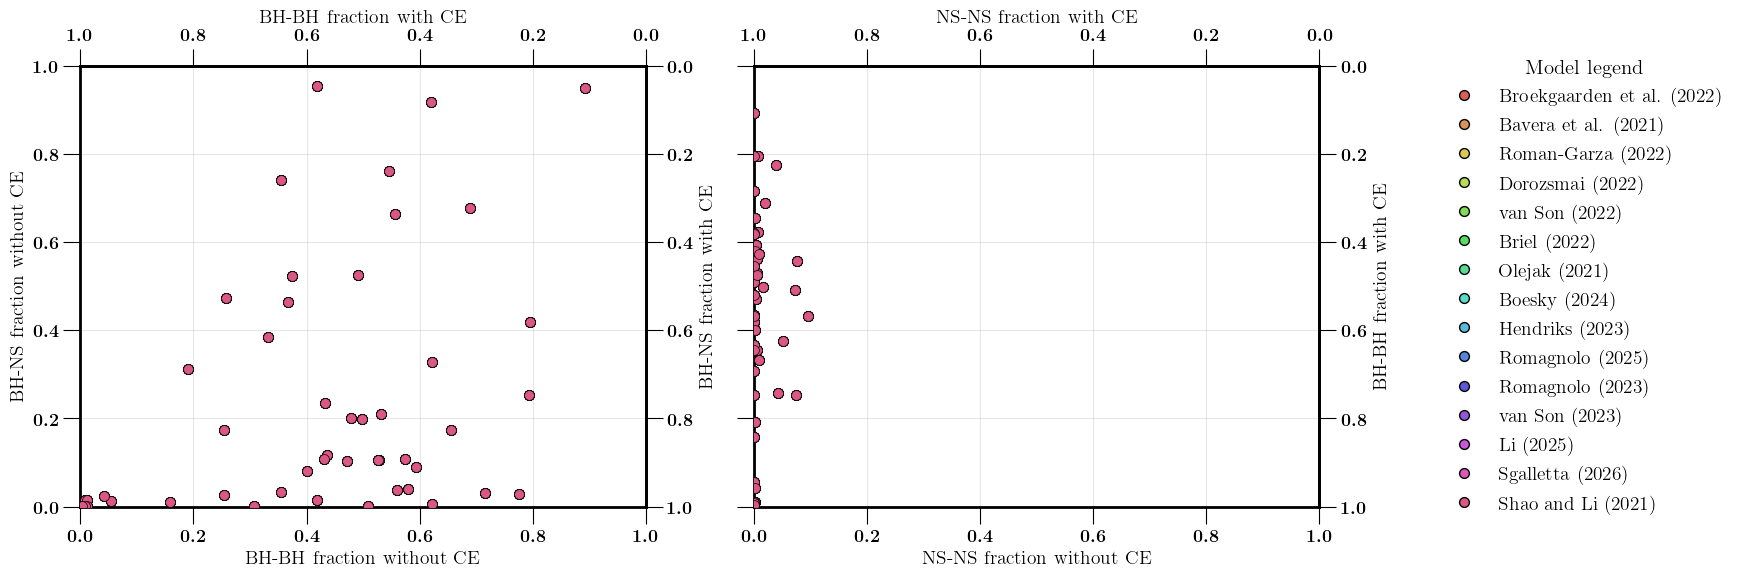

In [22]:

fig, axes = plot_fc_relations_panel_compare(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/"
)
plt.show()




In [23]:
# ! ls /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/

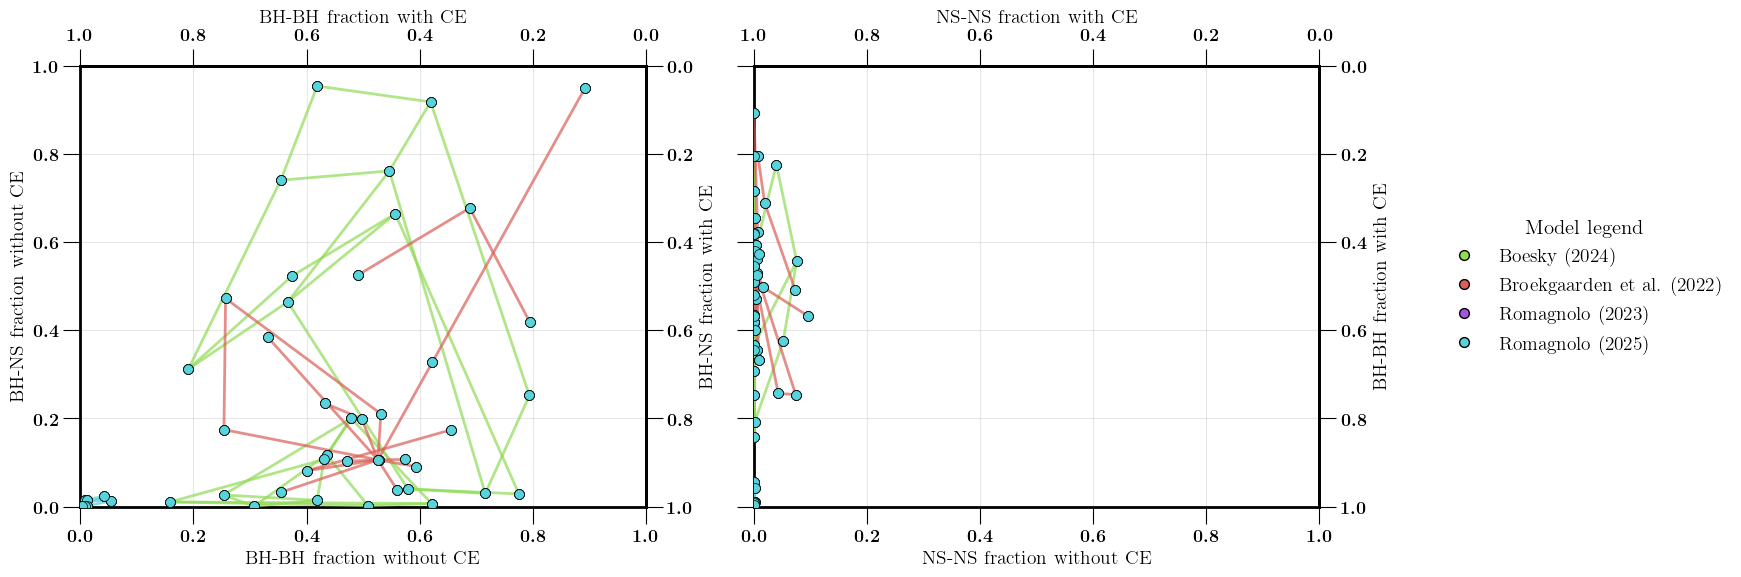

In [24]:
def plot_fc_relations_panel_compare(
    path_to_file,
    relation_file="BH-BH_fcRelations.csv",
    cmap="hls",
    marker_rel="o",
    size_rel=50,
    line_alpha=0.7,
    line_style="-",
    line_width=2,
    figsize=(18,6)
):
    """
    Make a 3-panel figure:
      - left: fraction without CE (BBH vs BHNS), with top/right axes = fraction with CE
      - middle: fraction without CE (NSNS vs BBH), with top/right axes = fraction with CE
      - right: legend

    Uses the same fcRelations file (always BBH), but requires models to exist
    in all three rates files: BH-BH, BH-NS, NS-NS.
    """

    import seaborn as sns

    # Load fcRelations (always BBH version)
    df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

    # Load rates for the three DCO types
    dfs_rates = {}
    for dco in ["BH-BH", "BH-NS", "NS-NS"]:
        rate_file = f"{dco}_rates_review.csv"
        dfs_rates[dco] = pd.read_csv(os.path.join(path_to_file, rate_file)).fillna(0.0).set_index("model")

    frac_col = "fraction without common envelope"

    # --- Only keep models present in all three rates files
    common_models = set(dfs_rates["BH-BH"].index) \
                    & set(dfs_rates["BH-NS"].index) \
                    & set(dfs_rates["NS-NS"].index)
    if len(common_models) == 0:
        raise ValueError("No overlapping models found in BH-BH, BH-NS, and NS-NS rates files!")

    # Restrict fcRelations to only those models
    df_rel = df_rel[
        df_rel["from_modelname"].isin(common_models)
        & df_rel["to_modelname"].isin(common_models)
    ]

    # Legend colors (author groups)
    legends = df_rel["legend"].unique()
    linecolors = sns.color_palette(cmap, len(legends))
    color_map = dict(zip(legends, linecolors))

    # Setup figure
    fig, axes = plt.subplots(1, 3, figsize=figsize, gridspec_kw={"width_ratios": [1, 1, 0.5]})
    ax_BBH_BHNS, ax_NSNS_BBH, ax_leg = axes

    def plot_cross(ax, dco_x, dco_y):
        handles, labels = [], []
        df_rates_x = dfs_rates[dco_x]
        df_rates_y = dfs_rates[dco_y]

        for legend, df_group in df_rel.groupby("legend"):
            color = color_map[legend]
            coords = {}

            # scatter points
            for model in common_models:
                if model in df_rates_x.index and model in df_rates_y.index:
                    xval = df_rates_x.loc[model, frac_col]
                    yval = df_rates_y.loc[model, frac_col]
                    coords[model] = (xval, yval)
                    ax.scatter(
                        xval, yval,
                        s=size_rel, c=[color], marker=marker_rel,
                        edgecolor="k", zorder=10, linewidths=0.5
                    )

            # connecting lines for transitions in this legend group
            for _, row in df_group.iterrows():
                m1, m2 = row["from_modelname"], row["to_modelname"]
                if m1 in coords and m2 in coords:
                    x_vals, y_vals = zip(coords[m1], coords[m2])
                    ax.plot(
                        x_vals, y_vals,
                        color=color, linestyle=line_style,
                        linewidth=line_width, alpha=line_alpha, zorder=5
                    )

            # legend handle (only once per legend group)
            h = plt.Line2D([], [], color=color, marker=marker_rel, linestyle="",
                           markersize=2*np.sqrt(size_rel)/2, label=legend, markeredgecolor="k")
            handles.append(h)
            labels.append(legend)

        # axis labels
        ax.set_xlabel(f"{dco_x} fraction without CE", fontsize=14)
        ax.set_ylabel(f"{dco_y} fraction without CE", fontsize=14)

        # secondary axes: 1 - f_noCE = f_CE
        secx = ax.secondary_xaxis("top", functions=(lambda x: 1-x, lambda x: 1-x))
        secy = ax.secondary_yaxis("right", functions=(lambda y: 1-y, lambda y: 1-y))
        secx.set_xlabel(f"{dco_x} fraction with CE", fontsize=14)
        secy.set_ylabel(f"{dco_y} fraction with CE", fontsize=14)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        return handles, labels

    # Left: BBH vs BHNS
    handles, labels = plot_cross(ax_BBH_BHNS, "BH-BH", "BH-NS")

    # Middle: NSNS vs BBH
    plot_cross(ax_NSNS_BBH, "NS-NS", "BH-BH")
    ax_NSNS_BBH.set_ylabel("")
    ax_NSNS_BBH.tick_params(axis="y", labelleft=False)

    # Right: legend
    ax_leg.axis("off")
    ax_leg.legend(handles, labels, loc="center left", frameon=False,
                  title="Model legend", fontsize=14)

    plt.tight_layout()
    return fig, axes



fig, axes = plot_fc_relations_panel_compare(
    path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/"
)
plt.show()




### Create a zip file folder that contains the PNG images to create the large legend for the powerpoint overview of formationchannels


In [25]:
import os
import re
from collections import defaultdict

import matplotlib as mpl
mpl.use("Agg")  # headless / no GUI

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def sanitize_filename(text: str, max_len: int = 140) -> str:
    text = text.strip()
    text = re.sub(r"\s+", "_", text)
    text = text.replace("\\", "")  # avoid awkward filenames
    text = text.replace("{", "").replace("}", "")
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text)
    text = text.strip("._-")
    return (text or "label")[:max_len]


def save_patch_png(
    color: str,
    hatch, #hatch: str | None,
    outpath: str,
    *,
    width_px: int = 420,
    height_px: int = 120,
    dpi: int = 200,
    edgecolor: str = "black",
    linewidth: float = 0.8,
    hatch_color: str = "darkslategray",
    hatch_linewidth: float = 0.6,
    transparent_bg: bool = True,
    pad_fraction: float = 0.12,
):
    """
    Render a single Matplotlib Patch (with hatch) to a PNG, tightly cropped.
    """
    # Hatch tuning (matches your style intent)
    mpl.rcParams["hatch.linewidth"] = hatch_linewidth
    mpl.rcParams["hatch.color"] = hatch_color

    # Compute a figure size that roughly matches your requested pixels
    fig_w = width_px / dpi
    fig_h = height_px / dpi

    fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    pad = pad_fraction
    rect = mpatches.Rectangle(
        (pad, pad),
        1 - 2 * pad,
        1 - 2 * pad,
        facecolor=color,
        edgecolor=edgecolor,
        linewidth=linewidth,
        hatch=(hatch if hatch else ""),
    )
    ax.add_patch(rect)

    fig.savefig(
        outpath,
        format="png",
        dpi=dpi,
        transparent=transparent_bg,
        bbox_inches="tight",
        pad_inches=0.0,
    )
    plt.close(fig)


def export_channel_patches_as_pngs(
    fc_dict: dict,
    out_dir: str = "legend_color_bars_mpl",
    *,
    width_px: int = 420,
    height_px: int = 120,
    dpi: int = 200,
    transparent_bg: bool = True,
):
    """
    Writes one PNG per unique (label, color, hatch). If a label maps to multiple styles,
    filenames get suffixes _01, _02, etc.
    """
    os.makedirs(out_dir, exist_ok=True)

    # label -> set of (color, hatch)
    label_to_styles = defaultdict(set)

    for group in fc_dict.values():
        if isinstance(group, dict) and "channels" in group:
            for ch in group["channels"]:
                label = ch.get("label")
                color = ch.get("color")
                hatch = ch.get("hatch")
                if label and color:
                    label_to_styles[label].add((color, hatch))
        elif isinstance(group, dict):
            # e.g. total; you can include/exclude as you wish
            label = group.get("label")
            color = group.get("color")
            hatch = group.get("hatch")
            if label and color:
                label_to_styles[label].add((color, hatch))

    n_written = 0
    for label, styles in sorted(label_to_styles.items(), key=lambda x: x[0].lower()):
        base = sanitize_filename(label)
        styles = sorted(styles)

        if len(styles) == 1:
            color, hatch = styles[0]
            outpath = os.path.join(out_dir, f"{base}.png")
            save_patch_png(
                color, hatch, outpath,
                width_px=width_px, height_px=height_px, dpi=dpi,
                transparent_bg=transparent_bg,
            )
            n_written += 1
        else:
            for i, (color, hatch) in enumerate(styles, start=1):
                outpath = os.path.join(out_dir, f"{base}_{i:02d}.png")
                save_patch_png(
                    color, hatch, outpath,
                    width_px=width_px, height_px=height_px, dpi=dpi,
                    transparent_bg=transparent_bg,
                )
                n_written += 1

    print(f"Wrote {n_written} PNG(s) to: {os.path.abspath(out_dir)}")


# -----------------------
# Usage
# -----------------------
fc_dict = obtain_fc_dict()
export_channel_patches_as_pngs(fc_dict, out_dir="legend_color_bars_mpl", transparent_bg=True)


Wrote 23 PNG(s) to: /Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/legend_color_bars_mpl


### Summary plot 


In [62]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def plot_withoutCE_three_DCOs(
    path_to_file,
    sort_header="fraction without common envelope",
    save_path="formation_channels_withoutCE_summary.pdf",
    add_jitter=True,
    jitter_scale=0.05,
    point_size=26,
    alpha=0.8,
):
    """
    Plot all simulations for:
      - BBH (BH-BH) in black
      - BHNS in blue
      - BNS (NS-NS) in gold

    on three horizontal lines as a function of the
    'fraction without common envelope'.

    Expected files in path_to_file:
      - BH-BH_rates_review.csv
      - BH-NS_rates_review.csv
      - NS-NS_rates_review.csv
    """

    # ----------------------------
    # helper: load one DCO file
    # ----------------------------
    def _load_one(path_to_file, DCOlabel):
        file_name = DCOlabel + "_rates_review.csv"
        csv_path = os.path.join(path_to_file, file_name)

        df = pd.read_csv(csv_path)

        if sort_header not in df.columns:
            raise ValueError(
                f"Column '{sort_header}' not found in {csv_path}.\n"
                f"Available columns are:\n{list(df.columns)}"
            )

        df = df.copy()
        df["DCOlabel"] = DCOlabel
        df[sort_header] = pd.to_numeric(df[sort_header], errors="coerce")
        df = df.dropna(subset=[sort_header])

        # keep only physical fractions
        df = df[(df[sort_header] >= 0) & (df[sort_header] <= 1)]

        return df

    # ----------------------------
    # load all three populations
    # ----------------------------
    df_bbh  = _load_one(path_to_file, "BH-BH")
    df_bhns = _load_one(path_to_file, "BH-NS")
    df_bns  = _load_one(path_to_file, "NS-NS")

    df_all = pd.concat([df_bbh, df_bhns, df_bns], ignore_index=True)

    # ----------------------------
    # plotting setup
    # ----------------------------
    y_map = {
        "BH-BH": 2.0,
        "BH-NS": 1.0,
        "NS-NS": 0.0,
    }

    color_map = {
        "BH-BH": "black",
        "BH-NS": "tab:blue",
        "NS-NS": "gold",
    }

    label_map = {
        "BH-BH": "BBH",
        "BH-NS": "BHNS",
        "NS-NS": "BNS",
    }

    rng = np.random.default_rng(42)

    fig, ax = plt.subplots(figsize=(10, 3.2))

    # horizontal guide lines
    for dco in ["NS-NS", "BH-NS", "BH-BH"]:
        ax.hlines(
            y=y_map[dco],
            xmin=0,
            xmax=1,
            linewidth=1.0,
            alpha=0.35,
            color="gray",
            zorder=0,
        )

    # scatter each class
    for dco in ["BH-BH", "BH-NS", "NS-NS"]:
        sub = df_all[df_all["DCOlabel"] == dco].copy()
        x = sub[sort_header].to_numpy()
        y = np.full(len(sub), y_map[dco], dtype=float)

        if add_jitter:
            y += rng.uniform(-jitter_scale, jitter_scale, size=len(sub))

        ax.scatter(
            x,
            y,
            s=40,                      # increase size so edge is visible
            color=color_map[dco],
            alpha=alpha,
            edgecolors="black",        # <-- black edge
            linewidths=0.6,            # <-- edge thickness
            zorder=3,
            label=label_map[dco],
        )

        
        
    for dco, y in y_map.items():
        ax.axhspan(y - 0.25, y + 0.25, color="gray", alpha=0.05, zorder=0)
    # ----------------------------
    # cosmetics
    # ----------------------------
    counts = df_all["DCOlabel"].value_counts()

    for dco in ["NS-NS", "BH-NS", "BH-BH"]:
        ax.text(
            1.02,                              # just outside the axis
            y_map[dco],
            f"{counts.get(dco, 0)} data points",
            va="center",
            fontsize=12,
        )
        
    ax.grid(axis="x", which="major", linestyle="--", alpha=0.4)
    ax.grid(axis="x", which="minor", linestyle=":", alpha=0.25)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.4, 2.4)
    if sort_header=="fraction with common envelope":
        ax.set_xlabel(r"$\textbf{Fraction forming with common envelope}$", fontsize=20)
    else: 
        ax.set_xlabel(r"$\textbf{Fraction forming without common envelope}$", fontsize=20)
#     ax.set_xlabel("Fraction forming without common envelope", fontsize=18)
    ax.set_yticks([0.0, 1.0, 2.0])
    ax.set_yticklabels(["BNS", "BHNS", "BBH"])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # set ticks every 0.1 WITH labels
    xticks = np.arange(0, 1.01, 0.1)
    ax.set_xticks(xticks)
    ax.tick_params(axis='x', which='minor', length=4, width=1)
    
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(1.5)
    
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=16,   # tick label fontsize
        length=6,       # tick length
        width=1.5       # tick thickness
    )
    

    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    print(f"Saved to: {save_path}")

    return fig, ax, df_all



path_to_file = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/"

fig, ax, df_all = plot_withoutCE_three_DCOs(
    path_to_file=path_to_file,
    sort_header="fraction without common envelope",
    save_path="formation_channels_withoutCE_three_lines.pdf",
)

plt.show()

Saved to: formation_channels_withoutCE_three_lines.pdf


/var/folders/h9/clnzhf8d5p9cx1bsz28r5h6w0000gn/T/ipykernel_25447/2628929131.py:191: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



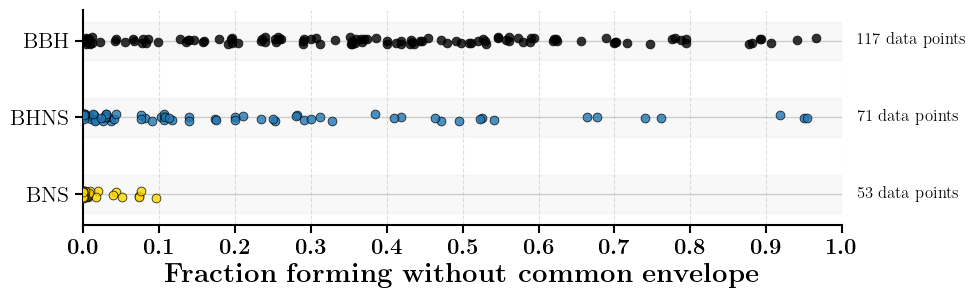

In [63]:
display(fig)

Saved to: formation_channels_witCE_three_lines.pdf


/var/folders/h9/clnzhf8d5p9cx1bsz28r5h6w0000gn/T/ipykernel_25447/2630900734.py:10: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



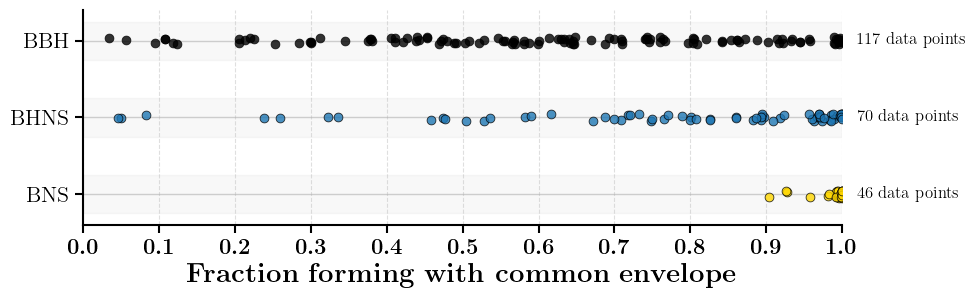

In [64]:


path_to_file = "/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/"

fig, ax, df_all = plot_withoutCE_three_DCOs(
    path_to_file=path_to_file,
    sort_header="fraction with common envelope",
    save_path="formation_channels_witCE_three_lines.pdf",
)


plt.show()

display(fig)

## OLD CODE 

In [28]:


# import matplotlib.pyplot as plt
# import pandas as pd
# import os
# import numpy as np
# import math
# from matplotlib.ticker import AutoMinorLocator
# %matplotlib inline

# def plot_withoutCE_all_and_by_study(
#     path_to_file,
#     DCOlabel="BH-BH",
#     relation_file=None,
#     marker="o",
#     size=50,
#     line_alpha=0.7,
#     line_style="-",
#     line_width=2.5,
#     figsize_all=(8, 6),
#     ncols_grid=4,
#     figsize_grid_per_panel=(4.0, 3.2),  # (width, height) per subplot
#     cmap_name="tab20",
#     sharex=True,
#     sharey=True,
#     save_big_pdf=None,
#     save_grid_pdf=None,
#     dpi=300,
# ):
#     """
#     Make:
#       (1) one big plot: fraction without CE vs total intrinsic rate for all studies
#       (2) a subplot grid: same relation, one panel per study (legend)

#     Returns
#     -------
#     fig_all, ax_all, fig_grid, axes_grid
#     """

#     # --- Load relation file (pairs of models) ---
#     if relation_file is None:
#         relation_file = f"{DCOlabel}_fcRelations.csv"
#     df_rel = pd.read_csv(os.path.join(path_to_file, relation_file))

#     # --- Load rates file (fractions + total rate per model) ---
#     rates_file = f"{DCOlabel}_rates_review.csv"
#     df_rates = pd.read_csv(os.path.join(path_to_file, rates_file))
#     df_rates = df_rates.fillna(0.0).set_index("model")

#     # --- OPTIONAL: load van Son 2023 secondary SFRD variations ---
#     extra_sfrd_file = os.path.join(path_to_file, "extra_fc_rates", "vanSon2023_sfrd.csv")
#     if os.path.exists(extra_sfrd_file):
#         df_rates_vanson_sfrd = pd.read_csv(extra_sfrd_file).fillna(0.0).set_index("model")
#     else:
#         df_rates_vanson_sfrd = None

#     # --- Formation-channel metadata ---
#     fc_dict = obtain_fc_dict()
#     fc_total_header = fc_dict["total"]["name"]      # column name for total intrinsic rate
#     yname = fc_dict["total"]["axlabel"]             # y-axis label (rate)

#     # x axis label for "fraction without common envelope"
#     channels = fc_dict["CE_simple"]["channels"]
#     channel_dict = next(ch for ch in channels if ch["name"] == "fraction without common envelope")
#     xname = channel_dict["axlabel"]

#     # --- Studies (legend groups) ---
#     legends = list(df_rel["legend"].dropna().unique())
#     legends_sorted = sorted(legends)

#     # --- Color map ---
#     if cmap_name.lower() == "husl":
#         palette = sns.color_palette("husl", len(legends_sorted))
#     else:
#         cmap = plt.get_cmap(cmap_name)
#         palette = [cmap(i / max(1, len(legends_sorted)-1)) for i in range(len(legends_sorted))]

#     color_map = {leg: palette[i] for i, leg in enumerate(legends_sorted)}

#     # --- explicitly set van Son 2023 study + fiducial model ---
#     vanSon_legend = "van Son (2023) "
#     vanSon_fiducial_model = "van Son (2023) "

#     print("Using vanSon_legend =", repr(vanSon_legend))
#     print("Using vanSon_fiducial_model =", repr(vanSon_fiducial_model))

#     # ------------- helper: plot a set of relations onto an axis -------------
#     def plot_relations_on_ax(ax, df_rel_subset, legend_for_color=None):
#         """
#         Plot points for models and connect from->to for each row in df_rel_subset.
#         If legend_for_color is None, color per row's legend.
#         """
#         for _, row in df_rel_subset.iterrows():
#             leg = row["legend"]
#             color = color_map[legend_for_color] if legend_for_color is not None else color_map.get(leg, "k")

#             m_from = row["from_modelname"]
#             m_to = row["to_modelname"]

#             coords = {}
#             for model in [m_from, m_to]:
#                 if model not in df_rates.index:
#                     continue

#                 x = df_rates.loc[model, "fraction without common envelope"]
#                 y = df_rates.loc[model, fc_total_header]
#                 coords[model] = (x, y)

#                 ax.scatter(
#                     x, y,
#                     s=size,
#                     c=[color],
#                     marker=marker,
#                     edgecolor="k",
#                     linewidths=0.5,
#                     zorder=10
#                 )

#             if m_from in coords and m_to in coords:
#                 (x1, y1) = coords[m_from]
#                 (x2, y2) = coords[m_to]
#                 ax.plot(
#                     [x1, x2], [y1, y2],
#                     color=color,
#                     linestyle=line_style,
#                     linewidth=line_width,
#                     alpha=line_alpha,
#                     zorder=5
#                 )

#     # ------------- helper: plot van Son 2023 secondary SFRD variations -------------
#     def plot_vanSon2023_secondary_sfrd(ax, legend_for_color):
#         """
#         Add the secondary S(Z,z)/SFRD variations for van Son 2023:
#         - same color as van Son 2023
#         - behind the main relations
#         - each extra point connected to the fiducial main-model point
#         """
#         if df_rates_vanson_sfrd is None:
#             return
#         if legend_for_color is None:
#             return
#         if vanSon_fiducial_model is None:
#             return
#         if vanSon_fiducial_model not in df_rates.index:
#             return
#         if legend_for_color != vanSon_legend:
#             return

#         color = color_map[legend_for_color]

#         # fiducial point from the MAIN rates file
#         x_fid = df_rates.loc[vanSon_fiducial_model, "fraction without common envelope"]
#         y_fid = df_rates.loc[vanSon_fiducial_model, fc_total_header]

#         # plot all extra points except any duplicate fiducial row in the extra csv
#         for model in df_rates_vanson_sfrd.index:
#             if "Fiducial" in str(model):
#                 continue

#             x = df_rates_vanson_sfrd.loc[model, "fraction without common envelope"]
#             y = df_rates_vanson_sfrd.loc[model, fc_total_header]

#             # background line to fiducial
#             ax.plot(
#                 [x_fid, x], [y_fid, y],
#                 color=color,
#                 linestyle="-",
#                 linewidth=line_width * 0.9,
#                 alpha=0.9,   # higher alpha / opacity, as requested
#                 zorder=1
#             )

#             # background point
#             ax.scatter(
#                 x, y,
#                 s=size * 0.9,
#                 c=[color],
#                 marker=marker,
#                 edgecolor="none",
#                 linewidths=0.0,
#                 alpha=0.9,
#                 zorder=2
#             )

#     # ===================== (1) BIG PLOT: all studies =====================
#     fig_all, ax_all = plt.subplots(1, 1, figsize=figsize_all)

#     plot_relations_on_ax(ax_all, df_rel)

#     # add van Son 2023 secondary SFRD variations in the background
#     if vanSon_legend is not None:
#         plot_vanSon2023_secondary_sfrd(ax_all, vanSon_legend)

#     # axes styling
#     layoutAxes(ax_all, nameX=xname, nameY=yname)
#     ax_all.set_xscale("linear")
#     ax_all.set_yscale("log")
#     ax_all.grid(True, alpha=0.3)

#     # legend (one handle per study)
#     handles = []
#     for leg in legends_sorted:
#         handles.append(
#             plt.Line2D([], [], color=color_map[leg], marker=marker, linestyle="",
#                        markersize=2*np.sqrt(size)/2, markeredgecolor="k", label=leg)
#         )
#     ax_all.legend(handles=handles, loc="best", frameon=False, title=r"$\textbf{Study}$", ncol=2)

#     fig_all.tight_layout()

#     # ===================== (2) GRID: one panel per study =====================
#     n_studies = len(legends_sorted)
#     ncols = int(ncols_grid)
#     nrows = int(math.ceil(n_studies / ncols))

#     fig_grid_w = figsize_grid_per_panel[0] * ncols
#     fig_grid_h = figsize_grid_per_panel[1] * nrows
#     fig_grid, axes = plt.subplots(
#         nrows, ncols,
#         figsize=(fig_grid_w, fig_grid_h),
#         sharex=sharex,
#         sharey=sharey
#     )

#     # Flatten axes robustly
#     axes_flat = np.array(axes).reshape(-1)

#     # --- style knobs (tweak to taste) ---
#     tick_labelsize = 15
#     tick_length_major = 5
#     tick_length_minor = 3
#     tick_width = 1.
#     panel_labelsize = 10

#     for i, leg in enumerate(legends_sorted):
#         ax = axes_flat[i]
#         df_sub = df_rel[df_rel["legend"] == leg]

#         # plot this study
#         plot_relations_on_ax(ax, df_sub, legend_for_color=leg)

#         # add van Son 2023 secondary SFRD variations only in the van Son panel
#         if str(leg).strip() == str(vanSon_legend).strip():
#             plot_vanSon2023_secondary_sfrd(ax, vanSon_legend)

#         # scales/grid
#         ax.set_xscale("linear")
#         ax.set_yscale("log")
#         ax.grid(True, alpha=0.25)

#         # --- put "model/study name" inside bottom-right of panel ---
#         ax.text(
#             0.98, 0.05, r'$\textbf{%s}$'%str(leg),
#             transform=ax.transAxes,
#             ha="right",
#             va="bottom",
#             fontsize=14,
#             fontweight="bold",
#             bbox=dict(
#                 boxstyle="round,pad=0.25",
#                 facecolor="white",
#                 alpha=0.75,
#                 edgecolor="none"
#             ),
#             zorder=20
#         )

#         # --- ticks: bigger labels, shorter ticks, minor ticks on x ---
#         ax.tick_params(
#             axis="both", which="major",
#             labelsize=tick_labelsize,
#             length=tick_length_major,
#             width=tick_width,
#             direction="in"
#         )
#         ax.tick_params(
#             axis="both", which="minor",
#             labelsize=tick_labelsize,
#             length=tick_length_minor,
#             width=tick_width,
#             direction="in"
#         )

#         # minor ticks on x-axis
#         ax.xaxis.set_minor_locator(AutoMinorLocator(2))
#         ax.tick_params(axis="x", which="minor", bottom=True)

#     # Turn off unused axes
#     for j in range(n_studies, len(axes_flat)):
#         axes_flat[j].axis("off")

#     label_fontsize = 20
#     ylabel_pad = 15

#     if sharex:
#         fig_grid.supxlabel(
#             r'$\textbf{%s}$'%xname,
#             fontsize=label_fontsize,
#             y=0.02
#         )

#     if sharey:
#         fig_grid.supylabel(
#             r'$\textbf{%s}$'%yname,
#             fontsize=label_fontsize,
#             x=0.02
#         )

#     # --- remove spacing between subpanels ---
#     fig_grid.subplots_adjust(left=0.06, right=0.995, bottom=0.06, top=0.995,
#                              wspace=0.0, hspace=0.0)

#     fig_grid.tight_layout()

#     # ===================== SAVE FIGURES =====================
#     if save_big_pdf is not None:
#         fig_all.savefig(
#             save_big_pdf,
#             format="pdf",
#             bbox_inches="tight",
#             dpi=dpi,
#             transparent=True
#         )
#         print(f"Saved big plot to: {save_big_pdf}")

#     if save_grid_pdf is not None:
#         fig_grid.savefig(
#             save_grid_pdf,
#             format="pdf",
#             bbox_inches="tight",
#             dpi=dpi,
#             transparent=True
#         )
#         print(f"Saved grid plot to: {save_grid_pdf}")

#     return fig_all, ax_all, fig_grid, axes


# # ---- Example call ----

# DCOlabel="BH-BH"

# fig_all, ax_all, fig_grid, axes_grid = plot_withoutCE_all_and_by_study(
#     path_to_file="/Users/floorbroekgaarden/Projects/GitHub/Rates_of_Formation_Channels/plottingCode/Fig_comparison/Data_formation_channels_intrinsic/",
#     DCOlabel=DCOlabel,
#     cmap_name="husl", # "rainbow", # color map
#     save_big_pdf=f"{DCOlabel}_fraction_withoutCE_all.pdf",
#     save_grid_pdf=f"{DCOlabel}_fraction_withoutCE_grid.pdf",
#     ncols_grid=4,
#     figsize_all=(9, 6),
#     figsize_grid_per_panel=(4.2, 3.2),
# )
# plt.show()



